# 13. Clustering and anomaly detection

Every notebook so far has had a target. Someone labelled the tumours malignant or benign,
someone recorded the house price, someone tagged the review as positive. This notebook is
about what to do when nobody labelled anything — when you have a matrix $\mathbf{X}$ and
the question is simply *what is in here?*

Two questions dominate unsupervised learning on tabular data. **Clustering** asks whether
the rows fall into groups: are there three kinds of customer, five kinds of galaxy, two
kinds of tumour? **Anomaly detection** asks the complementary question: which rows do *not*
belong — which transactions, sensor readings or hours of electricity demand are unlike
everything else? The two are intimately related, because both are statements about where
the data are dense and where they are not.

They are also the two places in this course where it is easiest to fool yourself. A
supervised model can be checked against a held-out label; a clustering usually cannot.
The algorithms will always return an answer — $k$-means asked for five clusters will
hand you five clusters, even on uniform noise — and the discipline of this notebook is
learning when to believe that answer.

**Prerequisites:** notebooks 1 (NumPy), 2 (mathematics essentials — eigenvectors,
covariance, multivariate Gaussians), 4 (preprocessing and scaling) and 5 (evaluation
methodology). Notebook 14 (dimensionality reduction) is a useful companion: PCA before
clustering is discussed there and used here. Notebook 8 (curse of dimensionality) explains
why distances misbehave in high dimensions, which is the single biggest threat to
everything below.

## Learning objectives

After working through this notebook you will be able to

- explain why clustering is an *ill-posed* problem, and how the choice of distance, scaling and $k$ builds the answer into the question;
- derive the $k$-means objective, implement Lloyd's algorithm and $k$-means++ from scratch in NumPy, and reproduce scikit-learn's result exactly;
- compare agglomerative linkage criteria (single, complete, average, Ward), read a dendrogram and cut it sensibly;
- apply DBSCAN and HDBSCAN, choose `eps` from a $k$-distance plot, and recognise the density assumption they make;
- derive the Gaussian mixture model, implement the EM algorithm for a 2-D mixture, and choose the number of components and the covariance type with BIC;
- evaluate a clustering with internal (silhouette, Davies–Bouldin, Calinski–Harabasz) and external (ARI, NMI, homogeneity/completeness) indices, and explain when each lies;
- detect anomalies with Isolation Forest, LOF, One-Class SVM and robust covariance estimation, and evaluate detectors with average precision;
- diagnose which algorithm family a dataset calls for, and say honestly when the answer is "there are no clusters here".

## Setup

In [1]:
import numpy as np                 # arrays and fast numerical maths
import pandas as pd                # DataFrames, used here for the result tables
import matplotlib.pyplot as plt    # the plotting library behind every figure
import seaborn as sns              # statistical plots on top of matplotlib (used for the heatmaps)
# patches are shapes you can draw on a plot: Ellipse for the GMM covariance contours, Circle for the DBSCAN radius
from matplotlib.patches import Ellipse, Circle

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_energy_demand() loads the simulated hourly electricity series used in section 10.3
from course_utils import set_style, PALETTE, load_energy_demand

RANDOM_STATE = 42                          # one fixed seed so every run produces the same results
rng = np.random.default_rng(RANDOM_STATE)  # a seeded random-number generator for the synthetic data
set_style()                                # apply the course-wide matplotlib settings once

NOISE_COLOR = "0.65"   # grey, reserved for points an algorithm labels as noise (-1)


def cluster_scatter(ax, X, labels, title=None, s=18, centers=None, alpha=0.85):
    """Scatter 2-D points coloured by cluster label; label -1 (noise) is drawn in grey.

    ax        the matplotlib axes to draw on
    X         array of shape (n, 2): the points
    labels    array of shape (n,): one cluster label per point (-1 = noise)
    title     optional panel title
    s, alpha  marker size and opacity
    centers   optional (k, 2) array of cluster centres, drawn as large black crosses
    Returns ax.
    """
    labels = np.asarray(labels)                          # accept a plain list too
    for j, lab in enumerate(sorted(set(labels))):        # each distinct label once, in order; j picks the colour
        m = labels == lab                                # boolean mask: the points with this label
        if lab == -1:
            # ax.scatter(x, y, ...) draws one marker per point; noise gets small grey crosses
            ax.scatter(X[m, 0], X[m, 1], s=s * 0.7, color=NOISE_COLOR, marker="x", linewidth=0.8,
                       label="noise", alpha=alpha)
        else:
            # j % len(PALETTE) wraps around to the first colour when there are more clusters than colours
            ax.scatter(X[m, 0], X[m, 1], s=s, color=PALETTE[j % len(PALETTE)], alpha=alpha,
                       edgecolor="white", linewidth=0.3)
    if centers is not None:
        # zorder=5 draws the centres on top of the points
        ax.scatter(centers[:, 0], centers[:, 1], s=200, marker="X", color="black",
                   edgecolor="white", linewidth=1.5, zorder=5)
    ax.set_xticks([])          # the coordinate values do not matter here, so hide the ticks
    ax.set_yticks([])
    ax.grid(False)
    if title:
        ax.set_title(title, fontsize=10.5)
    return ax

## 1. What clustering is — and what it is not

A clustering algorithm partitions $n$ observations $\mathbf{x}_1, \dots, \mathbf{x}_n \in
\mathbb{R}^d$ into groups such that points in the same group are "similar" and points in
different groups are not. The quotation marks are the whole problem: *similar in what
sense, and at what scale?* There is no target to arbitrate, so there is no unique right
answer — only answers that are more or less useful for the purpose you had in mind.

Kleinberg (2002) made this precise: no clustering function can simultaneously satisfy three
innocuous-looking axioms (scale invariance, richness, and consistency). Something must
give. In practice what gives is that *you* supply the missing information — through the
features you compute, the distance you choose, the scaling you apply, and the number of
clusters you request.

### 1.1 Three answers, all defensible

Here is a dataset with structure at two scales: six tight blobs arranged in three
well-separated pairs. Ask for two clusters, three clusters or six clusters and you get
three different, perfectly sensible partitions.

X_nested: 840 points, 2 features, 6 generating blobs in 3 pairs


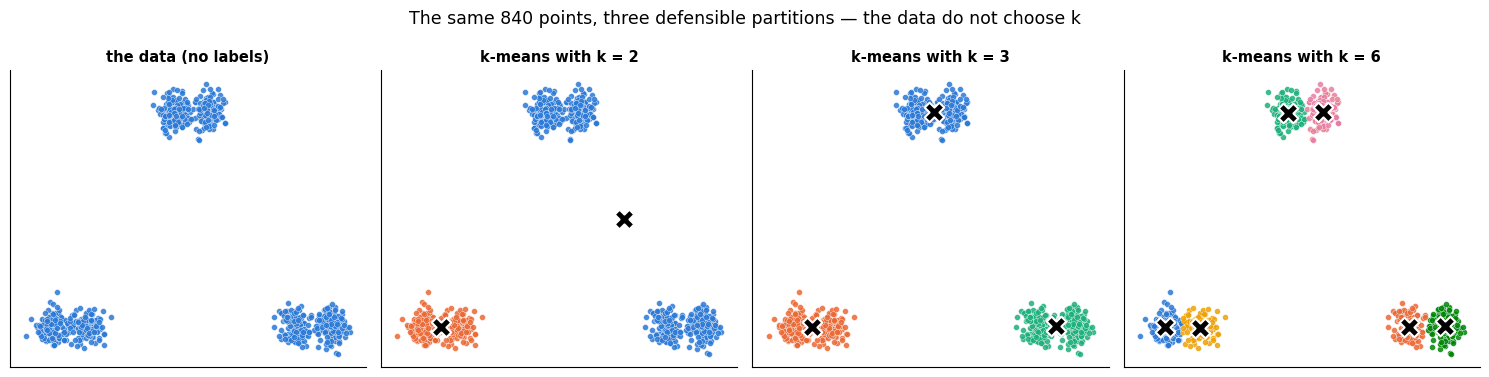

In [2]:
from sklearn.datasets import make_blobs   # generates Gaussian "blobs" of points, with the blob index as a label
from sklearn.cluster import KMeans

# six blob centres in 2-D, arranged as three well-separated pairs
centres = np.array([[0, 0], [2.5, 0], [18, 0], [20.5, 0], [9, 14], [11.5, 14]])
# a list for n_samples gives the size of each blob ([140] * 6 repeats 140 six times); cluster_std is each blob's
# standard deviation. Returns X of shape (840, 2) and y of shape (840,): the blob each point came from
X_nested, y_nested = make_blobs(n_samples=[140] * 6, centers=centres, cluster_std=0.6,
                                random_state=RANDOM_STATE)
print(f"X_nested: {X_nested.shape[0]} points, {X_nested.shape[1]} features, "
      f"{len(np.unique(y_nested))} generating blobs in 3 pairs")      # np.unique: the distinct values

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))       # one row of four panels
# all-zero labels: every point gets the same colour, i.e. "no labels"
cluster_scatter(axes[0], X_nested, np.zeros(len(X_nested), dtype=int),
                title="the data (no labels)")
for ax, k in zip(axes[1:], [2, 3, 6]):                  # panels 2-4 pair up with k = 2, 3, 6
    # n_init=10 runs k-means from 10 different starts and keeps the lowest SSE; random_state makes the starts
    # reproducible. .fit() returns the fitted model itself, so it can be chained onto the constructor
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_nested)
    # labels_: the cluster index of every point | cluster_centers_: the (k, 2) centroids
    cluster_scatter(ax, X_nested, km.labels_, title=f"k-means with k = {k}",
                    centers=km.cluster_centers_)
fig.suptitle("The same 840 points, three defensible partitions — the data do not choose k",
             fontsize=12.5)
plt.tight_layout()
plt.show()

Which is right? If the pairs are "product families" and the blobs within them are
"variants", then $k=3$ and $k=6$ answer two different business questions and both are
correct. This dataset will follow us through the notebook: in section 6 it shows that
internal validity indices genuinely disagree with each other, and in section 9 it shows the
elbow and the silhouette pointing at different $k$.

> **Key idea.** Clustering does not *discover* the number of groups; it *imposes* one.
> The algorithm, the distance, the scaling and $k$ together define what "a cluster" means.
> Your job is to make those choices explicitly and defend them, not to hope the data will
> make them for you.

### 1.2 Distance, similarity and the tyranny of units

Nearly every algorithm in this notebook is built on the Euclidean distance

$$
\|\mathbf{x}_i - \mathbf{x}_j\|_2 = \sqrt{\sum_{m=1}^{d} (x_{im} - x_{jm})^2},
$$

which weights every feature by the square of its *measurement unit*. A feature recorded in
grams contributes a million times more to the distance than the same quantity in kilograms.
Standardising each column to zero mean and unit variance (notebook 4) is therefore not a
cosmetic step — it decides the answer.

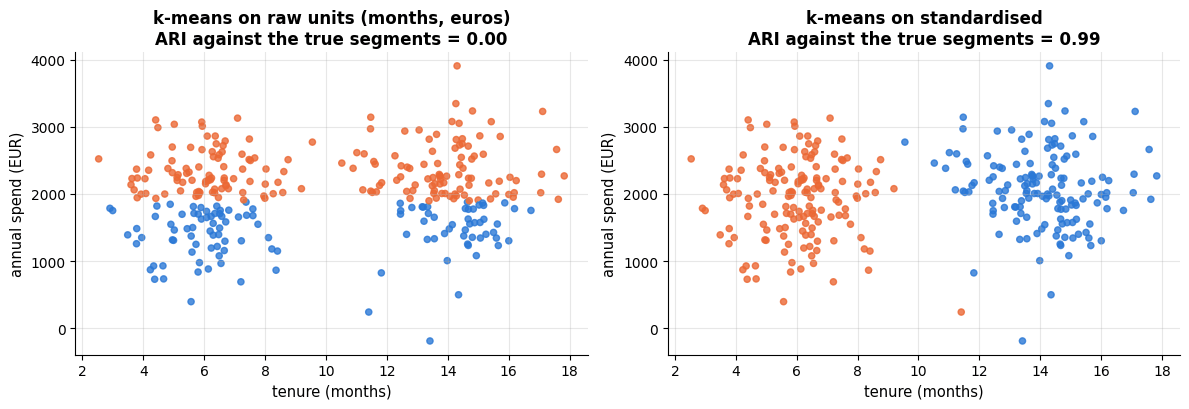

In [3]:
from sklearn.preprocessing import StandardScaler   # rescales each column to mean 0 and standard deviation 1
from sklearn.metrics import adjusted_rand_score    # agreement between two partitions (section 6.2)

# Two customer segments that differ in *tenure* (months) but not in spend (euros).
n = 300
group = rng.integers(0, 2, n)                    # the true segment of each customer: 0 or 1 (the 2 is excluded)
# np.where(cond, a, b) takes a where cond is True and b elsewhere: tenure around 6 months in group 0, 14 in group 1
tenure_months = np.where(group == 0, rng.normal(6, 1.5, n), rng.normal(14, 1.5, n))
annual_spend = rng.normal(2000, 600, n)          # pure noise: carries no group information
X_units = np.column_stack([tenure_months, annual_spend])     # the two features as columns: shape (300, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
# the same k-means twice: on the raw columns, and after StandardScaler (fit_transform = learn each column's
# mean and standard deviation, then rescale)
for ax, (name, Xv) in zip(axes, [("raw units (months, euros)", X_units),
                                 ("standardised", StandardScaler().fit_transform(X_units))]):
    # fit_predict(X) fits the model and returns labels_ in one call
    lab = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(Xv)
    # ARI compares the clusters with the true groups: 1 = identical up to renaming the clusters, about 0 = chance
    ari = adjusted_rand_score(group, lab)
    # always plot the raw values so both panels share axes; c= gives one colour per point (its cluster's colour)
    ax.scatter(X_units[:, 0], X_units[:, 1], c=[PALETTE[i] for i in lab], s=20, alpha=0.8)
    ax.set_xlabel("tenure (months)")
    ax.set_ylabel("annual spend (EUR)")
    ax.set_title(f"k-means on {name}\nARI against the true segments = {ari:.2f}")
plt.tight_layout()
plt.show()

On the raw scale, spend (standard deviation 600) dwarfs tenure (standard deviation 4), so
$k$-means splits the customers by a feature that contains no information at all. After
standardisation it recovers the true segmentation. The lesson generalises: **always put a
`StandardScaler` in front of a distance-based clusterer** unless you have a positive reason
not to (e.g. all features are already on a common scale, like pixel intensities).

> **Warning.** Standardising is not always right either. It gives every feature equal say,
> including pure noise features — if 40 of your 50 columns are noise, they will drown the
> 10 informative ones. Feature selection, or PCA before clustering (notebook 14, section 2),
> is the usual remedy; section 10.1 shows both on the wine data.

## 2. $k$-means and Lloyd's algorithm

### 2.1 The objective

$k$-means represents each cluster by a single point, its **centroid**
$\boldsymbol{\mu}_j \in \mathbb{R}^d$, and assigns every observation to the nearest one.
Writing $c_i \in \{1, \dots, k\}$ for the cluster of point $i$, the objective is the
**within-cluster sum of squares** (inertia, SSE):

$$
\mathcal{L}(\mathbf{c}, \boldsymbol{\mu}) \;=\; \sum_{i=1}^{n} \big\|\mathbf{x}_i - \boldsymbol{\mu}_{c_i}\big\|_2^2
\;=\; \sum_{j=1}^{k} \sum_{i : c_i = j} \big\|\mathbf{x}_i - \boldsymbol{\mu}_j\big\|_2^2 .
$$

Minimising it jointly over the assignments $\mathbf{c}$ and the centroids
$\boldsymbol{\mu}$ is NP-hard even for $k=2$, so we settle for a local minimum obtained by
alternating minimisation. Two facts make the alternation easy:

1. **With the centroids fixed**, $\mathcal{L}$ is minimised by assigning each point to its
   nearest centroid: $c_i = \arg\min_j \|\mathbf{x}_i - \boldsymbol{\mu}_j\|_2^2$.
2. **With the assignments fixed**, $\mathcal{L}$ is minimised by setting each centroid to
   the mean of its cluster. Differentiate
   $\sum_{i : c_i = j} \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$ with respect to
   $\boldsymbol{\mu}_j$ and set the gradient to zero:
   $-2\sum_{i : c_i = j}(\mathbf{x}_i - \boldsymbol{\mu}_j) = \mathbf{0}
   \Rightarrow \boldsymbol{\mu}_j = \frac{1}{n_j}\sum_{i : c_i = j}\mathbf{x}_i$.

Alternating the two steps is **Lloyd's algorithm**. Each step can only decrease
$\mathcal{L}$, and there are finitely many assignments, so it converges in a finite number
of iterations — to a local minimum, not necessarily the global one.

> **History.** The procedure was described by Lloyd (1982) in a 1957 Bell Labs memo on
> pulse-code modulation, and independently by MacQueen (1967), who coined the name
> "k-means". It is simultaneously one of the oldest and one of the most used algorithms in
> data analysis (Jain, 2010).

### 2.2 Lloyd's algorithm from scratch

Twenty lines of NumPy. The `history` list records the state after every step so that we can
draw the classic animation as small multiples.

In [4]:
def kmeans_pp_init(X, k, rng):
    """k-means++ seeding (Arthur & Vassilvitskii, 2007): pick centres far from those already chosen.

    X is the (n, d) data, k the number of centres and rng a NumPy random Generator.
    Returns a (k, d) array of starting centres, each of them one of the data points.
    """
    n = len(X)
    centers = np.empty((k, X.shape[1]))                  # (k, d), allocated without values; every row is filled below
    # rng.integers(n) is a random index in 0..n-1
    centers[0] = X[rng.integers(n)]                      # first centre: uniformly at random
    d2 = ((X - centers[0]) ** 2).sum(axis=1)             # squared distance to the nearest centre
    for j in range(1, k):
        # rng.choice(n, p=...) draws one index from 0..n-1 with the given probabilities (they must sum to 1);
        # points that are already centres have d2 = 0, so they can never be picked twice
        centers[j] = X[rng.choice(n, p=d2 / d2.sum())]   # sample proportionally to D(x)^2
        # for every point keep the smaller of its old distance and its distance to the new centre
        d2 = np.minimum(d2, ((X - centers[j]) ** 2).sum(axis=1))
    return centers


def assign(X, centers):
    """Nearest-centroid assignment; returns the labels and the resulting SSE.

    X is (n, d) and centers is (k, d). Returns labels of shape (n,), the index of each point's
    nearest centre, and the SSE: the sum of squared distances from the points to their centres.
    """
    # broadcasting (n, 1, d) - (1, k, d) -> (n, k, d): every point minus every centre; summing over d gives
    # the squared distances
    d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)   # (n, k)
    # argmin(axis=1): the closest centre in each row (point) | min(axis=1).sum(): the SSE
    return d2.argmin(axis=1), d2.min(axis=1).sum()


def lloyd(X, k, rng, init=None, max_iter=100, tol=1e-10):
    """Lloyd's algorithm. Returns centres, labels, inertia and the full iteration history.

    X         (n, d) data;  k  the number of clusters
    rng       NumPy Generator, used only for the k-means++ seeding when init is None
    init      optional (k, d) starting centres, used instead of the k-means++ seeding
    max_iter  maximum number of update/assign rounds
    tol       stop once no centre coordinate moves by more than this
    Returns centers (k, d), labels (n,), inertia (the final SSE) and history: a list with one
    (centers, labels, SSE) tuple per iteration, history[0] being the starting state.
    """
    # k-means++ unless starting centres were passed; np.asarray(..., dtype=float).copy() makes a float copy,
    # so the caller's array is never modified
    centers = kmeans_pp_init(X, k, rng) if init is None else np.asarray(init, dtype=float).copy()
    labels, inertia = assign(X, centers)
    history = [(centers.copy(), labels.copy(), inertia)]   # .copy() stores a snapshot, not a reference
    for _ in range(max_iter):
        # M-step: each centre moves to the mean of the points currently assigned to it
        # (X[labels == j] are the rows in cluster j; a cluster that lost all its points keeps its old centre,
        # because the mean of zero rows would be NaN)
        new_centers = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                                for j in range(k)])
        shift = np.abs(new_centers - centers).max()      # the largest coordinate change of any centre
        centers = new_centers
        # E-step: reassign every point to its nearest centre
        labels, inertia = assign(X, centers)
        history.append((centers.copy(), labels.copy(), inertia))
        if shift < tol:                                  # the centres have stopped moving: converged
            break
    return centers, labels, inertia, history

Now the picture that explains the algorithm better than any sentence: a deliberately bad
random start, and the centroids marching to their final positions. The crosses are the
centroids; the colours are the current assignment.

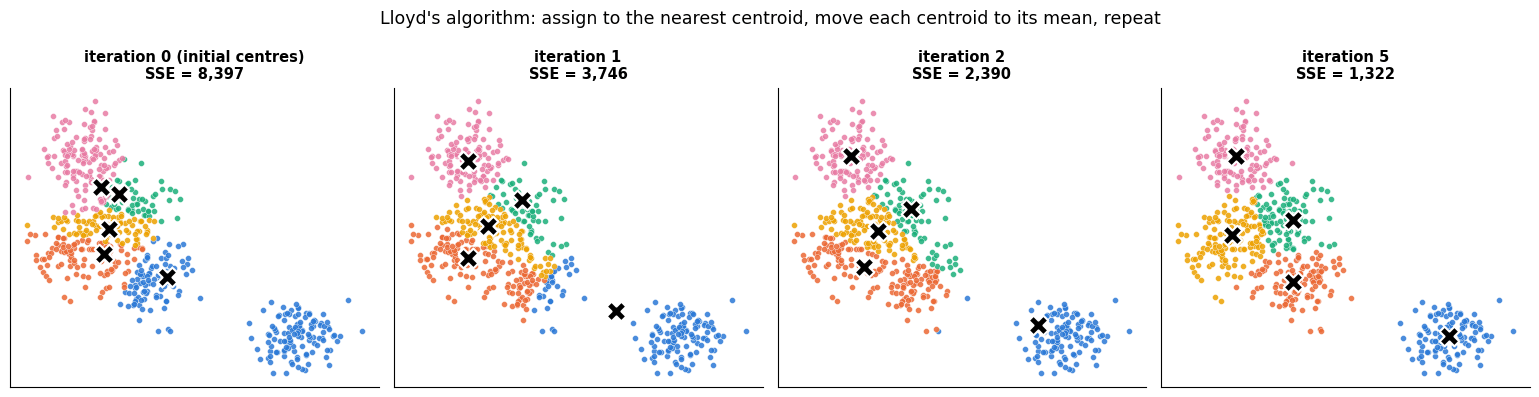

SSE per iteration: ['8,397', '3,746', '2,390', '1,787', '1,446', '1,322', '1,272', '1,250', '1,245', '1,245', '1,245']
converged after 10 iterations at SSE = 1,244.7


In [5]:
# 600 points in 5 randomly placed blobs; the true labels are not needed, so they go into _
X_demo, _ = make_blobs(n_samples=600, centers=5, cluster_std=1.1, random_state=0)

start_rng = np.random.default_rng(0)
# replace=False: 5 different indices
bad_start = X_demo[start_rng.choice(len(X_demo), 5, replace=False)]   # 5 random data points
# init= skips the k-means++ seeding; keep only the final SSE and the history
_, _, inertia_demo, history = lloyd(X_demo, 5, start_rng, init=bad_start)

shown = [0, 1, 2, 5]                                     # the iterations to draw
fig, axes = plt.subplots(1, len(shown), figsize=(15.5, 4.0))
for ax, t in zip(axes, shown):
    centers_t, labels_t, sse_t = history[t]              # the snapshot stored after iteration t
    # {sse_t:,.0f}: thousands separator, no decimals; the inline if/else adds a note to the first panel only
    cluster_scatter(ax, X_demo, labels_t, centers=centers_t,
                    title=f"iteration {t}{' (initial centres)' if t == 0 else ''}\nSSE = {sse_t:,.0f}")
fig.suptitle("Lloyd's algorithm: assign to the nearest centroid, move each centroid to its mean, repeat",
             fontsize=12.5)
plt.tight_layout()
plt.show()

print("SSE per iteration:", [f"{h[2]:,.0f}" for h in history])   # h[2] is the SSE of each snapshot
# history also holds the starting state, hence the - 1
print(f"converged after {len(history) - 1} iterations at SSE = {inertia_demo:,.1f}")

Two things to notice. The SSE falls monotonically — it must, because both steps minimise
the same objective. And most of the work happens in the first few iterations: by iteration
5 the partition is essentially final and the remaining steps only polish the centroids.

Does our implementation agree with the library? scikit-learn's `KMeans` runs the same
algorithm with a smarter (Elkan/triangle-inequality) inner loop, so the *result* should be
identical when both find the same optimum.

In [6]:
km = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE).fit(X_demo)   # inertia_ = SSE of the best run

# Mimic sklearn's n_init=10: run the whole procedure ten times and keep the best SSE.
# the generator expression yields one lloyd() result per seed (k-means++ seeding each time);
# min(..., key=lambda res: res[2]) keeps the result tuple whose element 2, the SSE, is smallest
best_scratch = min((lloyd(X_demo, 5, np.random.default_rng(s)) for s in range(10)),
                   key=lambda res: res[2])
_, labels_scratch, inertia_scratch, _ = best_scratch     # _ discards the centres and the history

print(f"from scratch (10 k-means++ restarts): SSE = {inertia_scratch:.4f}")
print(f"scikit-learn (n_init=10)            : SSE = {km.inertia_:.4f}")
print(f"agreement of the partitions (ARI)   = {adjusted_rand_score(labels_scratch, km.labels_):.4f}")

from scratch (10 k-means++ restarts): SSE = 1244.6881
scikit-learn (n_init=10)            : SSE = 1244.6881
agreement of the partitions (ARI)   = 1.0000


An ARI of 1.0 means the two partitions are identical up to a relabelling of the clusters —
cluster identities are arbitrary, which is why we compare partitions, never label vectors.
(Run our version once instead of ten times and it sometimes lands in a slightly worse local
optimum, which is exactly the point of the next section.)

### 2.3 $k$-means++ and the local-minimum problem

Lloyd's algorithm converges to a local minimum whose quality depends entirely on where it
started. On the data below there is a seductive local optimum that merges two true clusters
and splits a third in half, at an SSE nearly two and a half times the global one — and a
large minority of random starts fall into it.

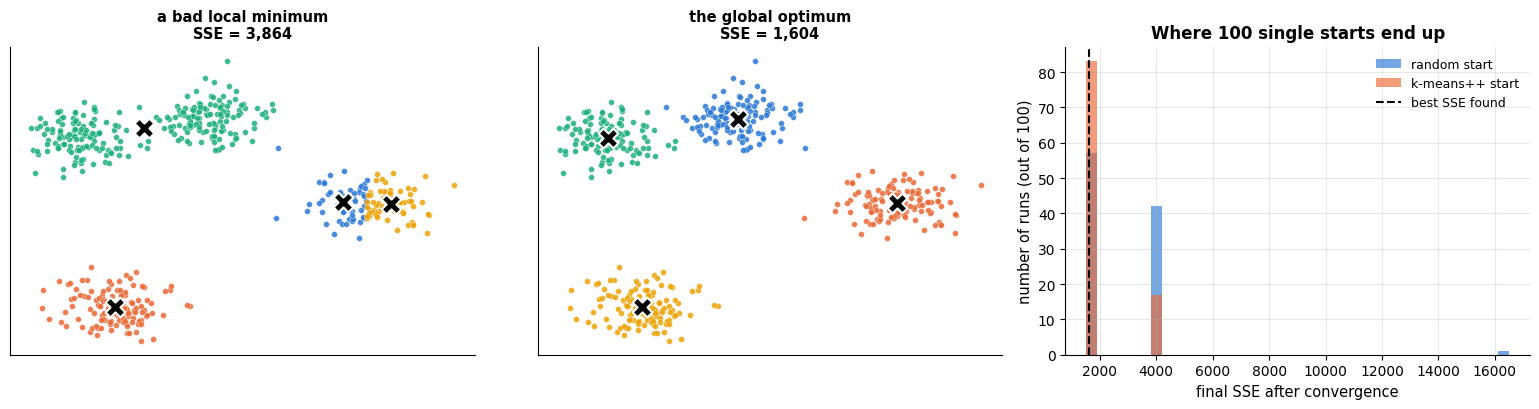

random    : mean SSE  2698.9 | worst 16176.8 | reached the best SSE in 57% of runs
k-means++ : mean SSE  1988.9 | worst  3906.7 | reached the best SSE in 83% of runs


In [7]:
X_local, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.3, random_state=RANDOM_STATE)


def random_init(X, k, rng):
    """Plain random seeding: return k distinct data points, chosen uniformly, as the starting centres."""
    return X[rng.choice(len(X), k, replace=False)]


runs = {}                                                # seeding name -> final SSE of 100 single runs
# functions are values too: init_fn is random_init or kmeans_pp_init
for name, init_fn in [("random", random_init), ("k-means++", kmeans_pp_init)]:
    finals = []
    for seed in range(100):
        r = np.random.default_rng(seed)                  # a fresh generator per run, so every run is reproducible
        _, _, sse, _ = lloyd(X_local, 4, r, init=init_fn(X_local, 4, r))   # seed with init_fn, then run Lloyd
        finals.append(sse)
    runs[name] = np.array(finals)

best = min(runs["random"].min(), runs["k-means++"].min())   # the lowest SSE any of the 200 runs reached
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

# one random start with seed 0, which ends in a bad local minimum
_, lab_bad, sse_bad, _ = lloyd(X_local, 4, np.random.default_rng(0),
                               init=random_init(X_local, 4, np.random.default_rng(0)))
c_bad = np.array([X_local[lab_bad == j].mean(axis=0) for j in range(4)])   # the centres: each cluster's mean
cluster_scatter(axes[0], X_local, lab_bad, centers=c_bad,
                title=f"a bad local minimum\nSSE = {sse_bad:,.0f}")

# the same with seed 4, which reaches the best SSE
_, lab_good, sse_good, _ = lloyd(X_local, 4, np.random.default_rng(4),
                                 init=random_init(X_local, 4, np.random.default_rng(4)))
c_good = np.array([X_local[lab_good == j].mean(axis=0) for j in range(4)])
cluster_scatter(axes[1], X_local, lab_good, centers=c_good,
                title=f"the global optimum\nSSE = {sse_good:,.0f}")

# 40 bin edges from just below the best SSE to just above the worst, shared by both histograms
bins = np.linspace(best * 0.95, max(runs['random'].max(), runs['k-means++'].max()) * 1.02, 40)
for i, (name, vals) in enumerate(runs.items()):
    # hist counts how many runs fall into each bin; alpha keeps the overlap visible
    axes[2].hist(vals, bins=bins, alpha=0.65, color=PALETTE[i], label=f"{name} start")
axes[2].axvline(best, color="black", ls="--", lw=1.5, label="best SSE found")   # a vertical line at x = best
axes[2].set_xlabel("final SSE after convergence")
axes[2].set_ylabel("number of runs (out of 100)")
axes[2].set_title("Where 100 single starts end up")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

for name, vals in runs.items():
    # {name:10s} pads to 10 characters, {:7.1f} is width 7 with 1 decimal; np.mean(vals <= 1.001 * best) is the
    # fraction of runs within 0.1 % of the best SSE, and :.0% prints it as a percentage
    print(f"{name:10s}: mean SSE {vals.mean():7.1f} | worst {vals.max():7.1f} "
          f"| reached the best SSE in {np.mean(vals <= 1.001 * best):.0%} of runs")

Only about 57 % of random starts reach the best SSE found, and the worst lands ten times
above it; $k$-means++ raises that to roughly 83 % and caps the damage of the remaining
failures at a factor of about 2.4. The bimodal histogram is the signature of a
non-convex objective: runs do not scatter around the optimum, they fall into one of a few
distinct basins.

**$k$-means++** (Arthur & Vassilvitskii, 2007) fixes most of this at negligible cost.
Instead of seeding uniformly, it picks the first centre at random and then samples each
subsequent centre with probability proportional to $D(\mathbf{x})^2$, the squared distance
to the nearest centre already chosen. Points far from every existing centre are
overwhelmingly likely to be picked, so the seeds spread out. The paper proves the resulting
SSE is within $O(\log k)$ of the optimum *in expectation, before Lloyd even runs*.

The practical protocol is: use $k$-means++ **and** restart. scikit-learn's default
`n_init=10` runs the whole procedure ten times and keeps the best SSE, which is why
`KMeans` is so much more reliable than a single hand-rolled run.

### 2.4 scikit-learn, `MiniBatchKMeans`, and vector quantisation

In [8]:
from sklearn.cluster import MiniBatchKMeans   # k-means that updates the centroids from small random batches
import time                                   # time.perf_counter() is a high-resolution clock for timing

# 200 000 points (the underscores in 200_000 are only digit separators) in 15 blobs
X_big, _ = make_blobs(n_samples=200_000, n_features=2, centers=15, cluster_std=1.0,
                      random_state=RANDOM_STATE)
# the first positional argument is n_clusters. KMeans: a single run (n_init=1).
# MiniBatchKMeans: batches of 2048 points; n_init=3 tries 3 initialisations and runs only from the best one
for name, model in [("KMeans", KMeans(15, n_init=1, random_state=RANDOM_STATE)),
                    ("MiniBatchKMeans", MiniBatchKMeans(15, n_init=3, batch_size=2048,
                                                        random_state=RANDOM_STATE))]:
    t0 = time.perf_counter()
    m = model.fit(X_big)
    # elapsed seconds = clock now minus clock before; inertia_ is the final SSE on all the data
    print(f"{name:16s} n=200,000: {time.perf_counter() - t0:5.2f} s, SSE = {m.inertia_:,.0f}")

KMeans           n=200,000:  0.21 s, SSE = 359,335
MiniBatchKMeans  n=200,000:  0.06 s, SSE = 366,554


`MiniBatchKMeans` (Sculley, 2010) updates the centroids from small random batches instead
of scanning the whole dataset in each iteration, so its cost per step is $O(b k d)$ rather
than $O(n k d)$. The price is deterministic and visible in the numbers: it converges to an
SSE about 2 % above the full algorithm's. The benefit is *not* reliably visible at this
size — modern scikit-learn's `KMeans` is heavily optimised and multi-threaded, so on 200 000
two-dimensional points it is already fast, and the measured times above fluctuate with
machine load rather than showing a clear winner. Reach for the mini-batch version when the
data do not fit in RAM, when they arrive as a stream, or when $n$ is in the millions — not
reflexively.

Finally, note what the $k$-means objective *is*: it is the distortion of a **vector
quantiser** with $k$ code words. Replacing every point by its centroid is lossy compression,
and the SSE is the reconstruction error. That is not an analogy — it is the problem Lloyd
was actually solving in 1957, and section 10.2 uses it to compress the colours of a
photograph.

## 3. Hierarchical clustering

$k$-means needs $k$ in advance and produces a flat partition. **Agglomerative hierarchical
clustering** produces the whole family of partitions at once: start with every point in its
own cluster and repeatedly merge the two closest clusters until one remains. The record of
merges is a binary tree — the **dendrogram** — and cutting it at any height yields a
partition.

### 3.1 Linkage criteria

"Closest" needs a definition for *sets* of points. Given clusters $A$ and $B$ and a point
distance $d$, the classical **linkage criteria** are

| Linkage | $D(A, B)$ | Tends to produce |
|---|---|---|
| **Single** (nearest neighbour) | $\min_{a \in A, b \in B} d(a, b)$ | long, snaking clusters; follows any shape; chains through noise |
| **Complete** (furthest neighbour) | $\max_{a \in A, b \in B} d(a, b)$ | compact, roughly equal-diameter clusters; sensitive to outliers |
| **Average** (UPGMA) | $\frac{1}{|A||B|}\sum_{a \in A}\sum_{b \in B} d(a, b)$ | a compromise between the two |
| **Ward** | increase in total within-cluster SSE caused by the merge | compact, similar-sized, spherical clusters |

Ward (1963) is the odd one out: it does not extend a point distance at all but greedily
minimises the same objective as $k$-means. The merge cost has the closed form

$$
\Delta(A, B) \;=\; \frac{|A|\,|B|}{|A| + |B|} \,\big\|\bar{\mathbf{x}}_A - \bar{\mathbf{x}}_B\big\|_2^2 ,
$$

which is why Ward requires Euclidean distances. All four criteria can be computed
recursively through the **Lance–Williams** update formula (Lance & Williams, 1967), which
is what makes the $O(n^2)$ implementations in `scipy.cluster.hierarchy` possible. Murtagh &
Legendre (2014) is worth reading if you ever need to know exactly which "Ward" a piece of
software implements — there are two conventions, and SciPy's `ward` expects raw
observations, not squared distances.

### 3.2 Dendrograms and the four linkages

Two interleaved half-moons: a shape no centroid method can handle, but single linkage can.

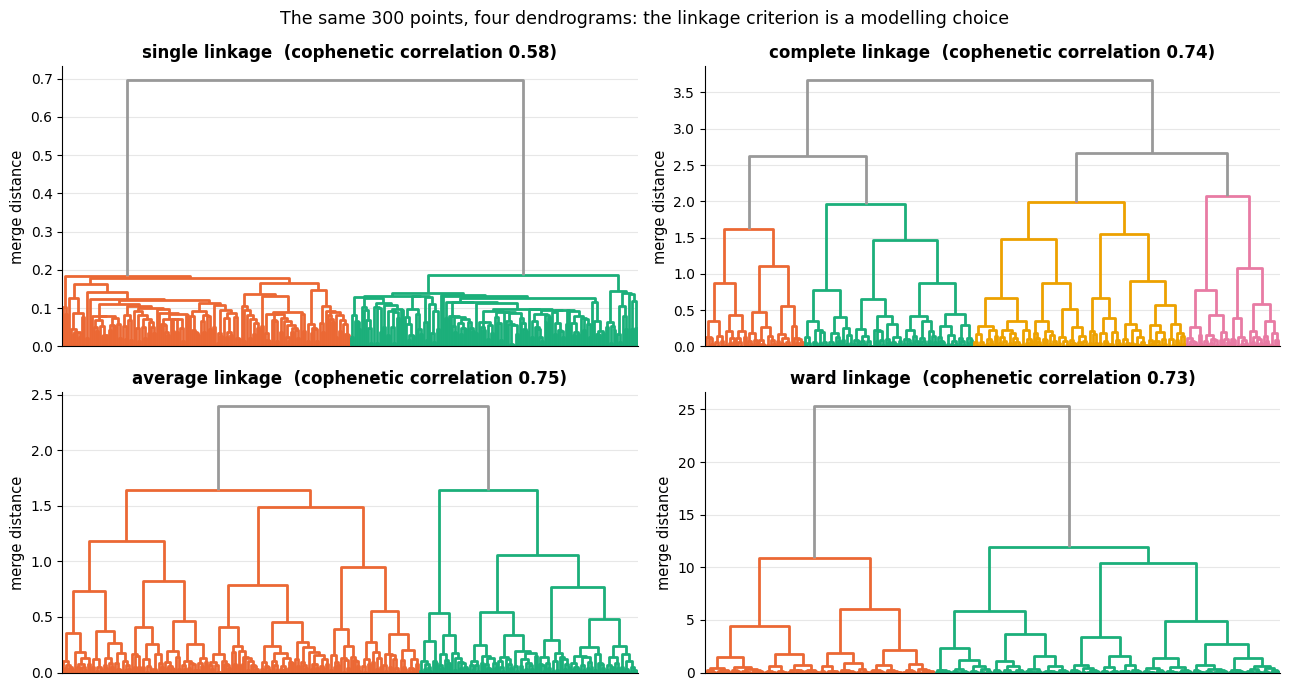

In [9]:
from sklearn.datasets import make_moons    # two interleaving half-circles
# linkage builds the merge tree, dendrogram draws it, fcluster cuts it into flat clusters,
# cophenet measures how faithfully the tree preserves the original distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist   # all pairwise distances, as a condensed 1-D array of length n(n-1)/2

# noise = standard deviation of the Gaussian noise added to the points; y_moons says which moon each point is on
X_moons, y_moons = make_moons(n_samples=300, noise=0.04, random_state=RANDOM_STATE)
X_moons = StandardScaler().fit_transform(X_moons)
methods = ["single", "complete", "average", "ward"]
# one linkage matrix per method. Each has shape (n - 1, 4): one row per merge,
# [cluster a, cluster b, merge distance, size of the new cluster]
Z = {m: linkage(X_moons, method=m) for m in methods}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, m in zip(axes.ravel(), methods):                 # ravel() flattens the 2 x 2 grid of axes into 4
    # Z[m][-1, 2] is the height of the last (highest) merge: links below 70 % of it get one colour per
    # subtree, the rest are grey ("0.6"); no_labels hides the 300 leaf labels
    dendrogram(Z[m], ax=ax, no_labels=True, color_threshold=Z[m][-1, 2] * 0.7,
               above_threshold_color="0.6")
    coph = cophenet(Z[m], pdist(X_moons))[0]             # cophenet returns (correlation, distances); keep [0]
    ax.set_title(f"{m} linkage  (cophenetic correlation {coph:.2f})")
    ax.set_ylabel("merge distance")
fig.suptitle("The same 300 points, four dendrograms: the linkage criterion is a modelling choice",
             fontsize=12.5)
plt.tight_layout()
plt.show()

The **cophenetic correlation** printed in each title is the correlation between the original
pairwise distances and the heights at which pairs are first merged — a measure of how
faithfully the tree represents the distance matrix. Average linkage usually scores highest
(here 0.75, just ahead of complete and Ward) and single linkage lowest, which is a reminder
that "faithful to the distance matrix" and "useful clustering" are different goals: on these
data single linkage is the only criterion that gets the clustering *right*.

The single-linkage dendrogram is the visually distinctive one: a long staircase of merges
at nearly the same small height, which is the signature of clusters being grown one point at
a time. Cutting each tree at two clusters shows what that buys:

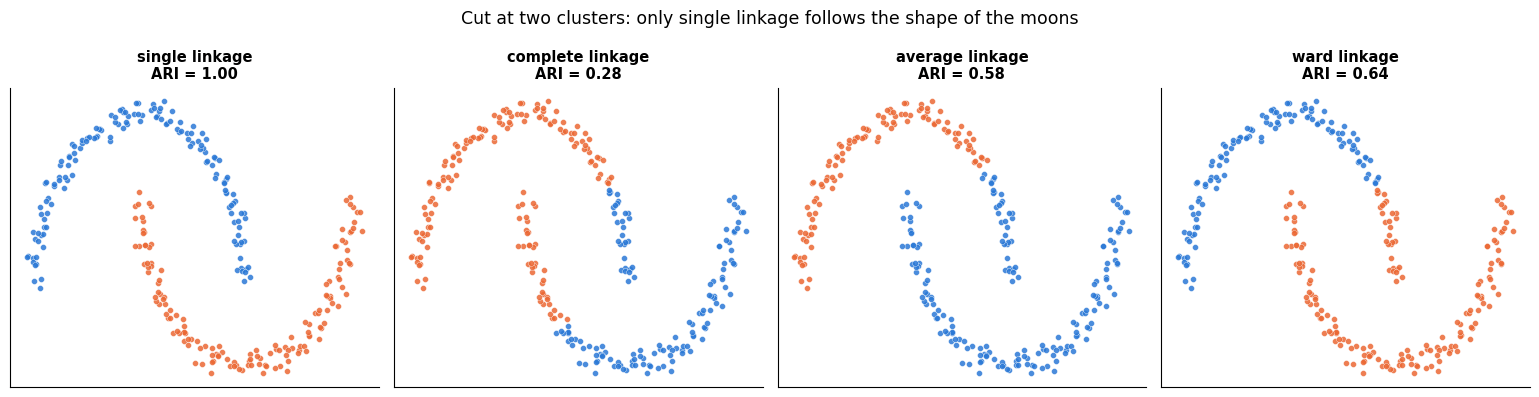

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.0))
for ax, m in zip(axes, methods):
    # criterion="maxclust": cut the tree where it gives (at most) t = 2 clusters; the labels start at 1
    labels_m = fcluster(Z[m], t=2, criterion="maxclust")
    cluster_scatter(ax, X_moons, labels_m,
                    title=f"{m} linkage\nARI = {adjusted_rand_score(y_moons, labels_m):.2f}")
fig.suptitle("Cut at two clusters: only single linkage follows the shape of the moons", fontsize=12.5)
plt.tight_layout()
plt.show()

Single linkage recovers the moons perfectly (ARI 1.00) because it only ever asks whether
two clusters have *one* pair of nearby points — the definition of a connected component at
scale $\varepsilon$. Complete, average and Ward measure compactness, and a moon is not
compact, so they slice each moon in half.

### 3.3 Chaining: when single linkage collapses

Single linkage's strength is also its catastrophic weakness. Nine points forming a thin
bridge between two obvious clusters are enough to destroy it — the phenomenon known as
**chaining**.

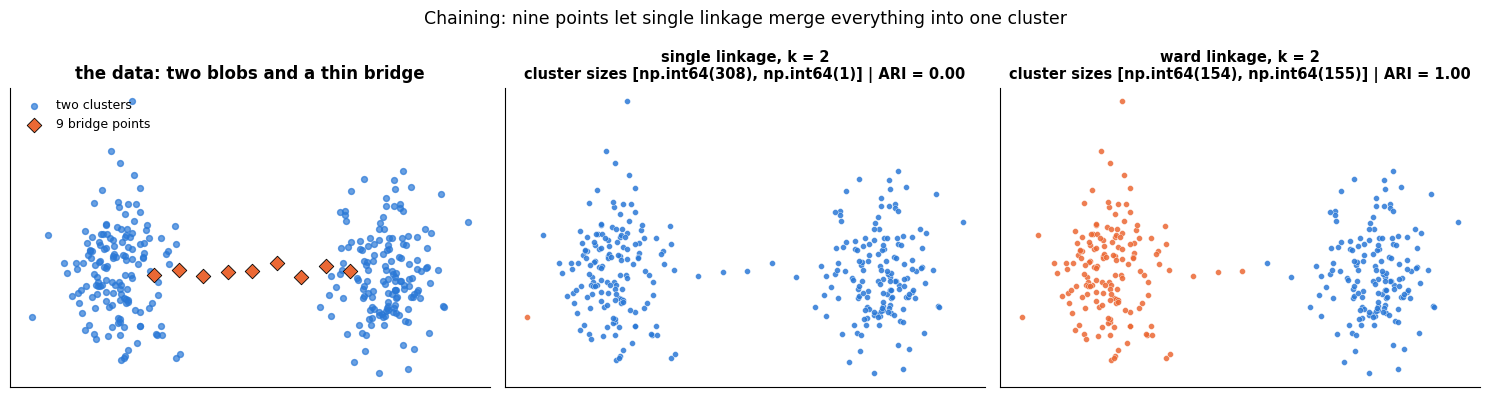

In [11]:
X_two, y_two = make_blobs(n_samples=[150, 150], centers=[[-3, 0], [3, 0]], cluster_std=0.6,
                          random_state=RANDOM_STATE)
# 9 evenly spaced x-values between the blobs, with a tiny vertical jitter: shape (9, 2)
bridge = np.column_stack([np.linspace(-2.2, 2.2, 9), rng.normal(0, 0.05, 9)])
X_bridge = np.vstack([X_two, bridge])           # np.vstack stacks rows: (300, 2) + (9, 2) -> (309, 2)
y_bridge = np.r_[y_two, np.full(9, -1)]         # np.r_ concatenates: the blob labels, then -1 for the 9 bridge points

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
axes[0].scatter(X_two[:, 0], X_two[:, 1], s=18, color=PALETTE[0], alpha=0.7, label="two clusters")
axes[0].scatter(bridge[:, 0], bridge[:, 1], s=55, color=PALETTE[1], marker="D",
                edgecolor="black", linewidth=0.6, label="9 bridge points")
axes[0].set_title("the data: two blobs and a thin bridge")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].set_xticks([]); axes[0].set_yticks([]); axes[0].grid(False)   # ";" puts several statements on one line
for ax, m in zip(axes[1:], ["single", "ward"]):
    lab = fcluster(linkage(X_bridge, method=m), t=2, criterion="maxclust")   # build the tree and cut it at 2
    ari = adjusted_rand_score(y_two, lab[:300])     # score only the first 300 rows: the bridge has no true group
    sizes = np.bincount(lab)[1:]                    # count each label; fcluster starts at 1, so drop the count of 0
    cluster_scatter(ax, X_bridge, lab, title=f"{m} linkage, k = 2\ncluster sizes {list(sizes)} | ARI = {ari:.2f}")
fig.suptitle("Chaining: nine points let single linkage merge everything into one cluster", fontsize=12.5)
plt.tight_layout()
plt.show()

Single linkage walks across the bridge one merge at a time and ends with one cluster of 308
points and one singleton; Ward ignores the bridge entirely. Use single linkage only when you
genuinely want connected components and your data are clean — otherwise **Ward is the
sensible default**, and it is scikit-learn's.

### 3.4 Cutting the tree, and connectivity constraints

`fcluster(Z, t, criterion="maxclust")` cuts for a target number of clusters;
`criterion="distance"` cuts at a merge height. The heights themselves are informative: a
large gap between consecutive merge heights means the next merge joins two groups that are
much further apart than anything joined so far, which is the dendrogram's version of an
elbow. Section 9.2 turns this into a figure.

scikit-learn's `AgglomerativeClustering` accepts a `connectivity` matrix — typically a
$k$-nearest-neighbour graph — that forbids merges between clusters that are not neighbours
in the graph. This makes the algorithm much faster on large $n$ and is how you encode
"clusters must be spatially contiguous" for image segmentation or geographic data. It also
changes the results, so use it deliberately.

## 4. Density-based clustering: DBSCAN and HDBSCAN

$k$-means and Ward partition *everything*: every point gets a label, however far it is from
any group. **DBSCAN** (Ester, Kriegel, Sander & Xu, 1996) takes a different view — a cluster
is a **connected region of high density**, and points in low-density regions are noise.
It is one of the most cited algorithms in data mining and won the KDD test-of-time award.

### 4.1 Core, border and noise points

Two parameters: a radius `eps` ($\varepsilon$) and a count `min_samples` ($m$). Define the
$\varepsilon$-neighbourhood $N_\varepsilon(\mathbf{x}) = \{\mathbf{x}' : \|\mathbf{x} -
\mathbf{x}'\| \le \varepsilon\}$. Then

- $\mathbf{x}$ is a **core point** if $|N_\varepsilon(\mathbf{x})| \ge m$ (counting itself);
- $\mathbf{x}$ is a **border point** if it is not core but lies in the neighbourhood of a core point;
- otherwise $\mathbf{x}$ is **noise**, and receives the label $-1$.

Clusters are the connected components of the core points (two core points are linked when
one is within $\varepsilon$ of the other), with border points attached to a cluster that
reaches them. The number of clusters is an *output*, not an input.

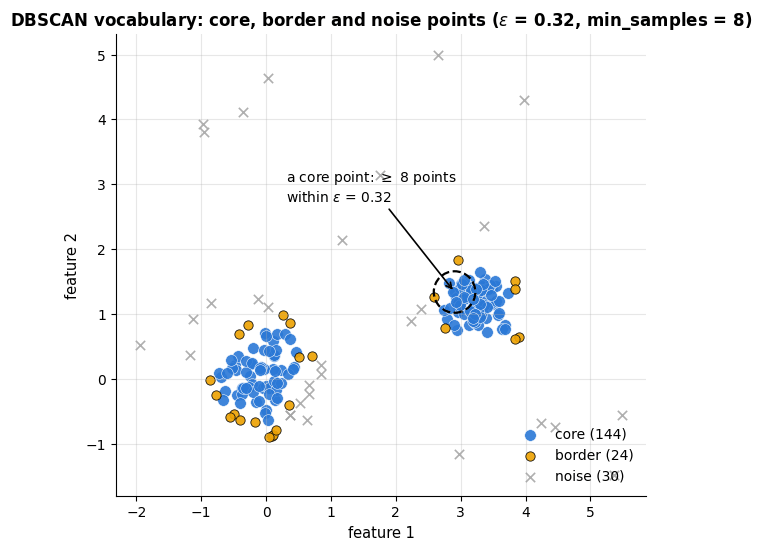

In [12]:
from sklearn.cluster import DBSCAN

# 180 points split between two blobs; a list for cluster_std gives each blob its own spread
X_dens, _ = make_blobs(n_samples=180, centers=[[0, 0], [3.2, 1.2]], cluster_std=[0.45, 0.30],
                       random_state=RANDOM_STATE)
X_dens = np.vstack([X_dens, rng.uniform(-2, 5.5, size=(18, 2))])   # sprinkle some noise: 18 uniform points

eps, min_samples = 0.32, 8
# eps = the neighbourhood radius; min_samples = how many points (counting the point itself) must lie within it
# for the point to be a core point
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_dens)
# core_sample_indices_ lists the positions of the core points; turn them into a boolean mask
is_core = np.zeros(len(X_dens), dtype=bool)
is_core[db.core_sample_indices_] = True
# nested np.where: "noise" where the label is -1, otherwise "core" or "border" -> one string per point
kind = np.where(db.labels_ == -1, "noise", np.where(is_core, "core", "border"))

fig, ax = plt.subplots(figsize=(8.5, 6))
# marker style per kind of point; dict(a=1) is the same as {"a": 1}
styles = {"core": dict(marker="o", s=70, color=PALETTE[0], edgecolor="white", linewidth=0.4),
          "border": dict(marker="o", s=45, color=PALETTE[3], edgecolor="black", linewidth=0.6),
          "noise": dict(marker="x", s=45, color=NOISE_COLOR, linewidth=1.2)}
for name, st in styles.items():
    m = kind == name
    # **st unpacks the style dict into keyword arguments; m.sum() counts the True entries
    ax.scatter(X_dens[m, 0], X_dens[m, 1], label=f"{name} ({m.sum()})", alpha=0.9, **st)
example = np.flatnonzero(is_core)[0]       # np.flatnonzero: the indices of the True entries; take the first
# Circle(centre, radius) is a shape; add_patch draws it on the axes
ax.add_patch(Circle(X_dens[example], eps, fill=False, ls="--", lw=1.6, color="black"))
# annotate(text, xy=point, xytext=text position, arrowprops=...) writes text with an arrow to the point;
# text between $...$ is rendered as maths: \geq is >=, \varepsilon is epsilon (the backslash is doubled in the string)
ax.annotate(f"a core point: $\\geq$ {min_samples} points\nwithin $\\varepsilon$ = {eps}",
            xy=X_dens[example], xytext=(X_dens[example, 0] - 2.6, X_dens[example, 1] + 1.4),
            arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=10)
ax.set_aspect("equal")     # so that the eps-neighbourhood is drawn as a circle, not an ellipse
ax.set_title(f"DBSCAN vocabulary: core, border and noise points "
             f"($\\varepsilon$ = {eps}, min_samples = {min_samples})")
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
ax.legend(loc="lower right")
plt.show()

### 4.2 Choosing `eps` with the $k$-distance plot

`min_samples` is the easy parameter: it sets how conservative the density threshold is, and
the standard advice (Ester et al., 1996; Schubert et al., 2017) is $m \ge d + 1$, with
$m = 2d$ a good default and larger values for noisy data.

`eps` is the delicate one, and there is a standard graphical device for it. Sort all points
by the distance to their $m$-th nearest neighbour and plot the sorted curve. Points inside a
cluster have small $m$-distances; noise points have large ones. The **knee** of the curve is
where the two regimes meet, and its height is a good first `eps`.

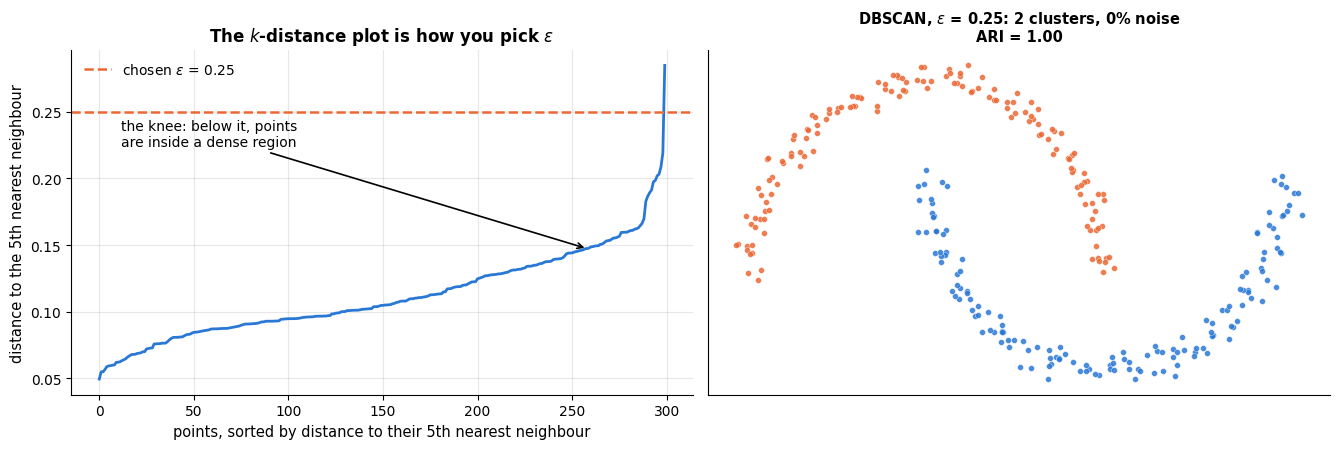

In [13]:
from sklearn.neighbors import NearestNeighbors   # finds the k nearest training points of any query point

min_samples_moons = 5
# kneighbors(X) returns (distances, indices), each of shape (n, 5), nearest first. Querying the training points
# themselves makes every point its own first neighbour (distance 0) — matching DBSCAN, whose min_samples
# also counts the point itself
dists, _ = NearestNeighbors(n_neighbors=min_samples_moons).fit(X_moons).kneighbors(X_moons)
k_dist = np.sort(dists[:, -1])            # every point's distance to its 5th neighbour (last column), sorted
eps_choice = 0.25                         # read off the knee of the curve below

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
axes[0].plot(np.arange(len(k_dist)), k_dist, color=PALETTE[0], lw=2)   # x = rank of the point, y = its distance
axes[0].axhline(eps_choice, color=PALETTE[1], ls="--", lw=1.8,
                label=f"chosen $\\varepsilon$ = {eps_choice}")
# xy (the arrow tip) is in data units: the 86th percentile of the curve;
# textcoords="axes fraction" places the text at (0.08, 0.72) in 0..1 panel coordinates
axes[0].annotate("the knee: below it, points\nare inside a dense region",
                 xy=(0.86 * len(k_dist), np.percentile(k_dist, 86)),
                 xytext=(0.08, 0.72), textcoords="axes fraction", fontsize=10,
                 arrowprops=dict(arrowstyle="->", lw=1.2))
axes[0].set_xlabel("points, sorted by distance to their 5th nearest neighbour")
axes[0].set_ylabel(f"distance to the {min_samples_moons}th nearest neighbour")
axes[0].set_title("The $k$-distance plot is how you pick $\\varepsilon$")
axes[0].legend()

lab_db = DBSCAN(eps=eps_choice, min_samples=min_samples_moons).fit_predict(X_moons)   # noise points get label -1
# set(lab_db) - {-1}: the distinct labels without the noise label, so len() counts the clusters;
# np.mean(lab_db == -1) is the noise fraction, printed as a percentage by :.0%
cluster_scatter(axes[1], X_moons, lab_db,
                title=f"DBSCAN, $\\varepsilon$ = {eps_choice}: {len(set(lab_db) - {-1})} clusters, "
                      f"{np.mean(lab_db == -1):.0%} noise\nARI = {adjusted_rand_score(y_moons, lab_db):.2f}")
plt.tight_layout()
plt.show()

### 4.3 Varying density: where DBSCAN breaks, and HDBSCAN

DBSCAN's assumption is a *single* global density threshold. When one cluster is tight and
another diffuse, no single `eps` works: small `eps` shatters the diffuse cluster into
fragments and calls most of it noise; large `eps` swallows the tight cluster into its
surroundings.

**HDBSCAN** (Campello, Moulavi & Sander, 2013; McInnes, Healy & Astels, 2017) removes the
parameter. It builds a hierarchy of DBSCAN clusterings over *all* values of `eps`
simultaneously — via a minimum spanning tree on the "mutual reachability" distance — and
then selects the clusters that persist over the widest range of density thresholds. You
specify `min_cluster_size` (how big a group has to be to count), which is a far more
intuitive quantity than a radius. Since scikit-learn 1.3 it ships as
`sklearn.cluster.HDBSCAN`.

sklearn.cluster.HDBSCAN available: True


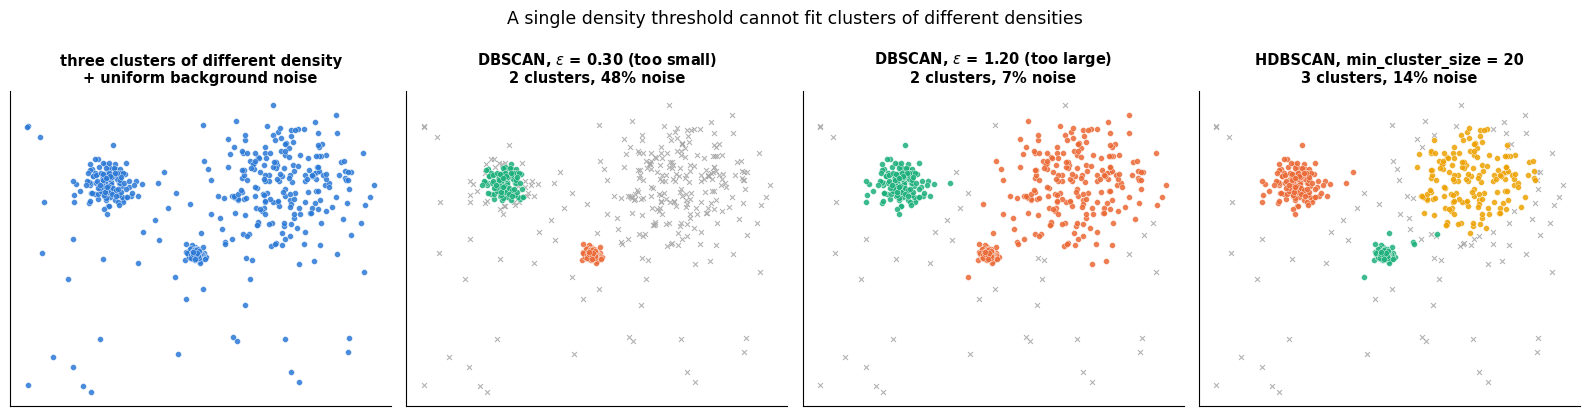

In [14]:
import sklearn.cluster

HAS_HDBSCAN = hasattr(sklearn.cluster, "HDBSCAN")   # added in scikit-learn 1.3; hasattr checks the module has it
print(f"sklearn.cluster.HDBSCAN available: {HAS_HDBSCAN}")

dens_rng = np.random.default_rng(1)
# normal(mean, std, (rows, cols)): a round 2-D Gaussian blob with its own spread; uniform(low, high, shape): noise
X_var = np.vstack([dens_rng.normal([0, 0], 0.18, (200, 2)),      # tight
                   dens_rng.normal([4, 4], 1.60, (200, 2)),      # diffuse
                   dens_rng.normal([-4, 4], 0.60, (150, 2)),     # medium
                   dens_rng.uniform(-8, 8, (60, 2))])            # background noise

# (panel title, labels) pairs, one per result panel
panels = [("DBSCAN, $\\varepsilon$ = 0.30 (too small)", DBSCAN(eps=0.30, min_samples=8).fit_predict(X_var)),
          ("DBSCAN, $\\varepsilon$ = 1.20 (too large)", DBSCAN(eps=1.20, min_samples=8).fit_predict(X_var))]
if HAS_HDBSCAN:
    from sklearn.cluster import HDBSCAN
    # min_cluster_size: the smallest group that counts as a cluster; copy=True guarantees that fitting never
    # modifies X_var in place (and silences a warning that this default will change)
    panels.append(("HDBSCAN, min_cluster_size = 20",
                   HDBSCAN(min_cluster_size=20, copy=True).fit_predict(X_var)))
else:
    print("HDBSCAN is not available in this scikit-learn version — showing DBSCAN only "
          "(pip install hdbscan provides the original implementation).")

# one panel for the raw data plus one per result; the figure gets wider with every panel
fig, axes = plt.subplots(1, len(panels) + 1, figsize=(4.0 * (len(panels) + 1), 4.2))
cluster_scatter(axes[0], X_var, np.zeros(len(X_var), dtype=int),
                title="three clusters of different density\n+ uniform background noise")
for ax, (name, lab) in zip(axes[1:], panels):
    n_cl = len(set(lab) - {-1})
    cluster_scatter(ax, X_var, lab, title=f"{name}\n{n_cl} clusters, {np.mean(lab == -1):.0%} noise")
fig.suptitle("A single density threshold cannot fit clusters of different densities", fontsize=12.5)
plt.tight_layout()
plt.show()

At $\varepsilon = 0.30$ the radius suits the tight cluster but not the diffuse one: DBSCAN
finds the dense core and throws away roughly half the data as noise. At
$\varepsilon = 1.20$ the diffuse cluster is finally dense enough — but by then the radius
has swallowed the gap between two of the groups and merged them. There *is* an intermediate
value (around $0.9$) that works on this dataset, but it has to be found by scanning, and the
window is narrow; section 9.3 shows how to map that window systematically. HDBSCAN finds the three groups and
the background noise from `min_cluster_size` alone, which is a count, not a length, and
therefore needs no knowledge of the scale of the data.

> **Going deeper.** `OPTICS` (Ankerst et al., 1999), also in scikit-learn, is the other
> classical answer: instead of a flat clustering it produces a *reachability plot* — an
> ordering of the points whose valleys are clusters at different density levels — from which
> a DBSCAN-like clustering can be extracted at any `eps`.

## 5. Model-based clustering: Gaussian mixtures and EM

### 5.1 The model

Instead of a geometric rule, assume a **probability model**: the data are drawn from a
mixture of $k$ Gaussians,

$$
p(\mathbf{x} \mid \boldsymbol{\theta}) \;=\; \sum_{j=1}^{k} \pi_j \, \mathcal{N}\!\big(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j\big),
\qquad \pi_j \ge 0, \quad \sum_{j=1}^{k} \pi_j = 1 ,
$$

with parameters $\boldsymbol{\theta} = \{\pi_j, \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j\}_{j=1}^k$:
the **mixing weights** $\pi_j$ (the prior probability of component $j$), the means
$\boldsymbol{\mu}_j \in \mathbb{R}^d$ and the covariance matrices
$\boldsymbol{\Sigma}_j \in \mathbb{R}^{d \times d}$. Think of it generatively: to produce a
point, first draw a component $z \in \{1, \dots, k\}$ with $P(z = j) = \pi_j$, then draw
$\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}_z, \boldsymbol{\Sigma}_z)$. The component
label $z$ is a **latent variable** — we never observe it.

Two immediate payoffs over $k$-means: clusters can be elongated and correlated (the
covariance is free), and assignments are **soft** — each point gets a probability of
belonging to each component rather than a hard label.

### 5.2 The EM algorithm

We want the maximum-likelihood parameters, maximising
$\ell(\boldsymbol{\theta}) = \sum_{i=1}^n \log \sum_{j=1}^k \pi_j \mathcal{N}(\mathbf{x}_i
\mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)$. The logarithm of a sum has no closed-form
maximiser, but the **expectation–maximisation** algorithm (Dempster, Laird & Rubin, 1977)
makes it easy by alternating between the latent variables and the parameters.

**E-step.** With the current parameters fixed, compute the posterior probability
(the **responsibility**) that component $j$ generated point $i$, by Bayes' rule:

$$
r_{ij} \;=\; P(z_i = j \mid \mathbf{x}_i, \boldsymbol{\theta})
\;=\; \frac{\pi_j \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}
{\sum_{l=1}^{k} \pi_l \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_l, \boldsymbol{\Sigma}_l)} .
$$

**M-step.** With the responsibilities fixed, the parameters have closed-form updates —
they are exactly the ordinary maximum-likelihood estimates with each point weighted by its
responsibility. Writing $N_j = \sum_{i=1}^n r_{ij}$ for the effective number of points in
component $j$:

$$
\pi_j \leftarrow \frac{N_j}{n}, \qquad
\boldsymbol{\mu}_j \leftarrow \frac{1}{N_j}\sum_{i=1}^{n} r_{ij}\, \mathbf{x}_i, \qquad
\boldsymbol{\Sigma}_j \leftarrow \frac{1}{N_j}\sum_{i=1}^{n} r_{ij}\, (\mathbf{x}_i - \boldsymbol{\mu}_j)(\mathbf{x}_i - \boldsymbol{\mu}_j)^\top .
$$

The key theorem is that each EM iteration **never decreases** the log-likelihood: the E-step
constructs a lower bound on $\ell$ that touches it at the current parameters, and the M-step
maximises that bound. Like Lloyd's algorithm, EM converges to a local optimum, so multiple
restarts (`n_init`) matter. Bishop (2006), chapter 9, gives the full derivation via
Jensen's inequality; McLachlan-style treatments appear in ESL chapter 8.

### 5.3 EM from scratch in 2-D

In [15]:
# logsumexp(a, axis) computes log(sum(exp(a))) without the overflow/underflow of doing it literally
from scipy.special import logsumexp


def log_gaussian(X, mu, Sigma):
    """log N(x | mu, Sigma) for every row of X, computed stably via a Cholesky-free solve.

    X is (n, d), mu the (d,) mean and Sigma the (d, d) covariance matrix. Returns an (n,) array of
    log-densities. Working in logs avoids underflow, and solve() avoids forming Sigma^-1 explicitly.
    """
    d = X.shape[1]
    diff = X - mu                                    # (n, d) - (d,) broadcasts: every point minus the mean
    _, logdet = np.linalg.slogdet(Sigma)             # slogdet returns (sign, log|det|); the sign is +1 here
    # np.linalg.solve(Sigma, diff.T) is Sigma^-1 (x - mu) for every point, as a (d, n) array; .T makes it (n, d),
    # and multiplying by diff and summing each row gives every point's squared Mahalanobis distance
    maha = (diff * np.linalg.solve(Sigma, diff.T).T).sum(axis=1)   # (x-mu)^T Sigma^-1 (x-mu)
    return -0.5 * (d * np.log(2 * np.pi) + logdet + maha)          # the log of the Gaussian density formula


def em_gmm(X, k, rng, n_iter=100, tol=1e-8, reg=1e-6):
    """EM for a full-covariance Gaussian mixture. Returns the parameters and the history.

    X       (n, d) data;  k  the number of components
    rng     NumPy Generator for the k-means++ seeding of the means
    n_iter  maximum number of EM iterations
    tol     stop when the total log-likelihood improves by less than this
    reg     small value added to the diagonal of every covariance so that it stays invertible
    Returns mus (k, d), Sigmas (k, d, d), pis (k,) and history: one tuple (mus, Sigmas, pis, R, log-likelihood)
    per iteration, where R (n, k) holds the responsibilities computed from those parameters.
    """
    n, d = X.shape
    mus = kmeans_pp_init(X, k, rng)                    # same seeding trick as k-means
    # np.cov expects one variable per row, hence X.T -> a (d, d) matrix; [M] * k repeats it -> shape (k, d, d)
    Sigmas = np.array([np.cov(X.T)] * k)               # start from the global covariance
    pis = np.full(k, 1.0 / k)                          # equal mixing weights 1/k to start
    history, prev_ll = [], -np.inf                     # -inf, so the first improvement always exceeds tol
    for _ in range(n_iter):
        # --- E-step: responsibilities (in log space, then normalise) ---
        # log_w[i, j] = log(pi_j) + log N(x_i | mu_j, Sigma_j): one column per component -> (n, k)
        log_w = np.column_stack([np.log(pis[j]) + log_gaussian(X, mus[j], Sigmas[j])
                                 for j in range(k)])
        ll_per_point = logsumexp(log_w, axis=1)        # log p(x_i) = log of the row sum of exp(log_w), shape (n,)
        # r_ij = exp(log_w[i, j] - log p(x_i)); [:, None] makes it (n, 1) so it broadcasts over the k columns.
        # Every row of R sums to 1
        R = np.exp(log_w - ll_per_point[:, None])
        ll = ll_per_point.sum()                        # total log-likelihood of the data
        history.append((mus.copy(), Sigmas.copy(), pis.copy(), R.copy(), ll))
        if ll - prev_ll < tol:                         # the log-likelihood stopped improving: converged
            break
        prev_ll = ll
        # --- M-step: weighted means and covariances ---
        N_j = R.sum(axis=0)                            # effective number of points per component, shape (k,)
        pis = N_j / n
        mus = (R.T @ X) / N_j[:, None]                 # (k, n) @ (n, d) -> (k, d) weighted sums, divided by N_j
        # R[:, j, None] is column j as (n, 1): it weights each centred row, and .T @ (X - mu) sums the weighted
        # outer products -> (d, d); reg * np.eye(d) adds reg to the diagonal
        Sigmas = np.array([((R[:, j, None] * (X - mus[j])).T @ (X - mus[j])) / N_j[j]
                           + reg * np.eye(d) for j in range(k)])
    return mus, Sigmas, pis, history


def draw_ellipse(ax, mu, Sigma, color, n_std=(1, 2), lw=2.0):
    """Draw the 1- and 2-standard-deviation contours of a 2-D Gaussian.

    mu is the (2,) centre and Sigma the (2, 2) covariance; n_std lists which contours to draw.
    The ellipse axes point along the eigenvectors of Sigma, with half-lengths s * sqrt(eigenvalue).
    """
    vals, vecs = np.linalg.eigh(Sigma)              # eigenvalues in ascending order, eigenvectors as columns
    order = vals.argsort()[::-1]                    # positions sorted largest first ([::-1] reverses)
    vals, vecs = vals[order], vecs[:, order]        # so vals[0] and vecs[:, 0] belong to the major axis
    # arctan2(y, x) is the angle of the major-axis vector (x, y); np.degrees converts it from radians
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    for s in n_std:
        # Ellipse(centre, width, height, angle=...): width and height are full axis lengths, 2 * s std devs
        ax.add_patch(Ellipse(mu, 2 * s * np.sqrt(vals[0]), 2 * s * np.sqrt(vals[1]),
                             angle=angle, fill=False, edgecolor=color, lw=lw, alpha=0.9))

Three overlapping, strongly anisotropic Gaussians — the case $k$-means cannot represent.

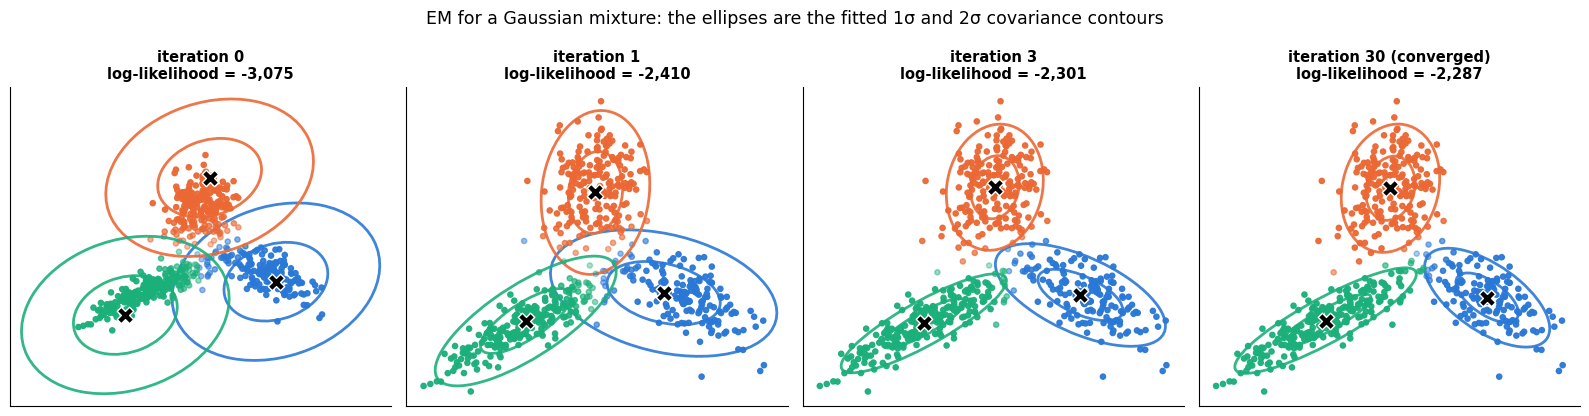

In [16]:
gmm_rng = np.random.default_rng(3)
# three elongated 2-D Gaussians; multivariate_normal(mean, covariance matrix, number of points) -> (600, 2) in total
X_gmm = np.vstack([
    gmm_rng.multivariate_normal([0, 0], [[2.0, 1.5], [1.5, 1.5]], 250),
    gmm_rng.multivariate_normal([5, 1], [[1.0, -0.7], [-0.7, 1.2]], 150),
    gmm_rng.multivariate_normal([2, 6], [[0.6, 0.0], [0.0, 2.5]], 200)])

mus_em, Sigmas_em, pis_em, hist_em = em_gmm(X_gmm, 3, np.random.default_rng(1))   # our EM with 3 components

shown = [0, 1, 3, len(hist_em) - 1]                  # three early iterations and the last one
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, t in zip(axes, shown):
    mus_t, Sig_t, pis_t, R_t, ll_t = hist_em[t]      # the snapshot of iteration t
    hard = R_t.argmax(axis=1)                        # hard label: the component with the largest responsibility
    for j in range(3):
        m = hard == j
        # opacity = confidence of the soft assignment
        # (np.clip keeps every alpha within [0.15, 0.95]; scatter accepts one alpha per point)
        ax.scatter(X_gmm[m, 0], X_gmm[m, 1], s=14, color=PALETTE[j],
                   alpha=np.clip(R_t[m, j], 0.15, 0.95))
        draw_ellipse(ax, mus_t[j], Sig_t[j], PALETTE[j])
        # *mus_t[j] unpacks the (2,) mean into the x and y arguments
        ax.scatter(*mus_t[j], marker="X", s=140, color="black", edgecolor="white", zorder=5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"iteration {t}{' (converged)' if t == shown[-1] else ''}\n"
                 f"log-likelihood = {ll_t:,.0f}", fontsize=10.5)
fig.suptitle("EM for a Gaussian mixture: the ellipses are the fitted 1σ and 2σ covariance contours",
             fontsize=12.5)
plt.tight_layout()
plt.show()

The ellipses start as three copies of the global covariance and progressively specialise:
each one rotates and shrinks onto its own component. The log-likelihood climbs at every
step, as the theory promises — let us plot it, and check the result against scikit-learn.

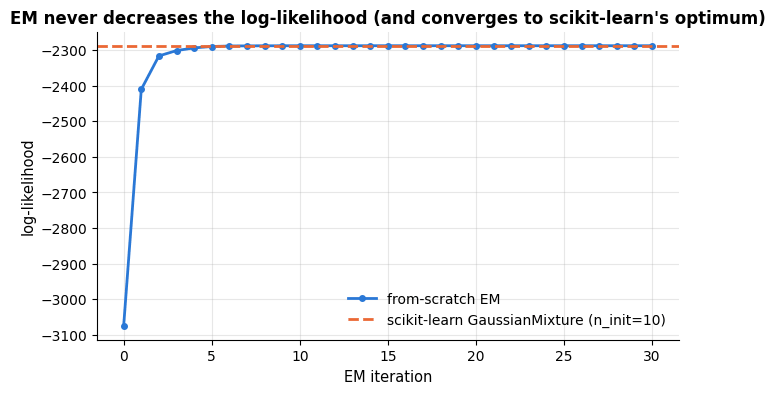

from-scratch final log-likelihood :  -2287.394  (31 iterations)
scikit-learn  final log-likelihood :  -2287.503
mixing weights — ours [0.259 0.331 0.411]  vs  sklearn [0.263 0.329 0.408]
monotone increase: True


In [17]:
from sklearn.mixture import GaussianMixture   # scikit-learn's Gaussian mixture, fitted by EM

lls = np.array([h[4] for h in hist_em])       # element 4 of each history tuple is the log-likelihood
# covariance_type="full": an unrestricted covariance per component (section 5.4); n_init=10 EM restarts, best kept
gm = GaussianMixture(n_components=3, covariance_type="full", n_init=10,
                     random_state=RANDOM_STATE).fit(X_gmm)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(np.arange(len(lls)), lls, marker="o", ms=4, color=PALETTE[0], label="from-scratch EM")
# .score(X) is the MEAN log-likelihood per point, so multiply by the number of points for the total
ax.axhline(gm.score(X_gmm) * len(X_gmm), color=PALETTE[1], ls="--", lw=2,
           label="scikit-learn GaussianMixture (n_init=10)")
ax.set_xlabel("EM iteration")
ax.set_ylabel("log-likelihood")
ax.set_title("EM never decreases the log-likelihood (and converges to scikit-learn's optimum)")
ax.legend(loc="lower right")
plt.show()

print(f"from-scratch final log-likelihood : {lls[-1]:10.3f}  ({len(lls)} iterations)")
print(f"scikit-learn  final log-likelihood : {gm.score(X_gmm) * len(X_gmm):10.3f}")
# weights_ are sklearn's mixing weights; the order of the components is arbitrary, so sort before comparing
print(f"mixing weights — ours {np.sort(pis_em).round(3)}  vs  sklearn {np.sort(gm.weights_).round(3)}")
# np.diff: the change from one iteration to the next; -1e-9 allows for round-off. bool() turns NumPy's bool
# into a plain True/False
print(f"monotone increase: {bool(np.all(np.diff(lls) >= -1e-9))}")

The two agree to within a fraction of a log-unit; the residual difference is only that
scikit-learn stops at its default tolerance (`tol=1e-3` on the *mean* log-likelihood) while
we ran to `1e-8` on the total.

### 5.4 Covariance types, soft assignments, and $k$-means as hard EM

A full covariance matrix costs $d(d+1)/2$ parameters per component, which becomes
unaffordable when $d$ is large. scikit-learn offers four restrictions:

| `covariance_type` | $\boldsymbol{\Sigma}_j$ | Free parameters per component | Cluster shape |
|---|---|---|---|
| `spherical` | $\sigma_j^2 \mathbf{I}$ | 1 | circles, own size |
| `diag` | $\operatorname{diag}(\sigma_{j1}^2, \dots, \sigma_{jd}^2)$ | $d$ | axis-aligned ellipses |
| `tied` | one shared $\boldsymbol{\Sigma}$ | $d(d+1)/2$ in total | identical ellipses |
| `full` | unrestricted | $d(d+1)/2$ | any ellipse |

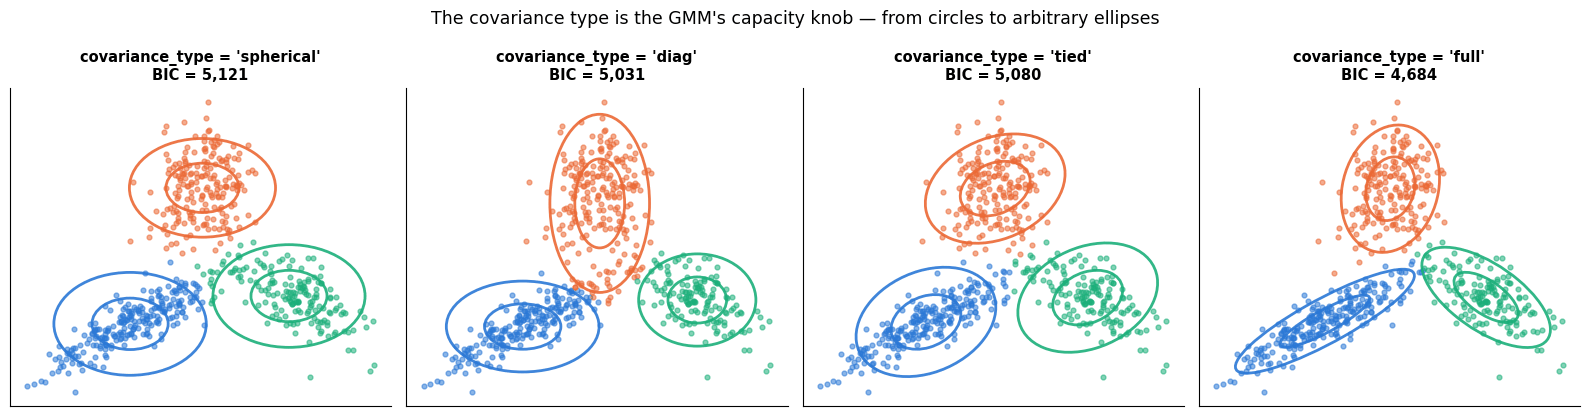

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, ct in zip(axes, ["spherical", "diag", "tied", "full"]):
    g = GaussianMixture(n_components=3, covariance_type=ct, n_init=5,
                        random_state=RANDOM_STATE).fit(X_gmm)
    lab = g.predict(X_gmm)                      # hard labels: the most probable component of each point
    # covariances_ has a different shape for every covariance_type; expand each to a 2x2 matrix
    if ct == "spherical":                       # shape (k,)   — one variance per component
        covs = [np.eye(2) * c for c in g.covariances_]
    elif ct == "diag":                          # shape (k, d) — per-feature variances
        covs = [np.diag(c) for c in g.covariances_]
    elif ct == "tied":                          # shape (d, d) — one matrix shared by all
        covs = [g.covariances_] * 3
    else:                                       # shape (k, d, d)
        covs = list(g.covariances_)
    for j in range(3):
        m = lab == j
        ax.scatter(X_gmm[m, 0], X_gmm[m, 1], s=12, color=PALETTE[j], alpha=0.55)
        draw_ellipse(ax, g.means_[j], covs[j], PALETTE[j])   # means_: the (k, d) component means
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    # .bic(X): the Bayesian information criterion of the fitted model on X, lower is better (section 5.5)
    ax.set_title(f"covariance_type = '{ct}'\nBIC = {g.bic(X_gmm):,.0f}", fontsize=10.5)
fig.suptitle("The covariance type is the GMM's capacity knob — from circles to arbitrary ellipses",
             fontsize=12.5)
plt.tight_layout()
plt.show()

A spherical mixture with equal weights and $\sigma^2 \to 0$ *is* $k$-means: as the variance
shrinks, the responsibilities $r_{ij}$ tend to 0 or 1, the E-step becomes nearest-centroid
assignment and the M-step becomes the cluster mean. $k$-means is therefore the **hard-EM**
limit of a constrained Gaussian mixture, which explains both its speed and its inductive
bias towards equal-sized spherical clusters.

The soft assignment is genuinely useful: it tells you *which points are ambiguous*.

3.7% of points have a maximum posterior below 0.8 — k-means would assign all of them with full confidence


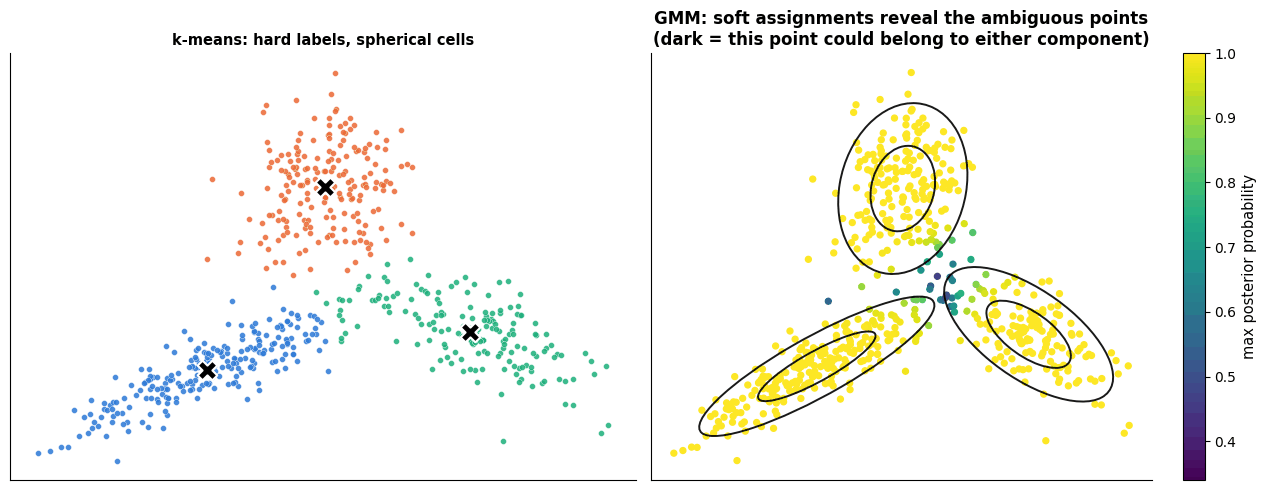

In [19]:
gm_full = GaussianMixture(n_components=3, covariance_type="full", n_init=10,
                          random_state=RANDOM_STATE).fit(X_gmm)
# predict_proba: the (n, 3) posterior probabilities (responsibilities); the row maximum is the confidence
conf = gm_full.predict_proba(X_gmm).max(axis=1)
km_gmm = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_gmm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cluster_scatter(axes[0], X_gmm, km_gmm.labels_, centers=km_gmm.cluster_centers_,
                title="k-means: hard labels, spherical cells")
# c=conf colours each point by its confidence through the colour map; the largest of 3 probabilities is at
# least 1/3, hence vmin=0.34
sc = axes[1].scatter(X_gmm[:, 0], X_gmm[:, 1], c=conf, cmap="viridis", s=18, vmin=0.34, vmax=1.0)
for j in range(3):
    draw_ellipse(axes[1], gm_full.means_[j], gm_full.covariances_[j], "black", lw=1.4)
plt.colorbar(sc, ax=axes[1], label="max posterior probability")   # the colour scale for sc, beside panel 2
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].grid(False)
axes[1].set_title("GMM: soft assignments reveal the ambiguous points\n(dark = this point could belong to either component)")
# np.mean(conf < 0.8): the fraction of points below 0.8; :.1% prints it as a percentage with one decimal
print(f"{np.mean(conf < 0.8):.1%} of points have a maximum posterior below 0.8 — "
      "k-means would assign all of them with full confidence")
plt.tight_layout()
plt.show()

### 5.5 How many components? BIC and AIC

Because a GMM is a probability model, model selection can use likelihood-based information
criteria instead of a geometric heuristic. For a model with $p$ free parameters fitted to
$n$ points,

$$
\text{AIC} = -2\ell + 2p, \qquad \text{BIC} = -2\ell + p \log n ,
$$

and **lower is better**. Both penalise complexity; BIC's penalty grows with $n$, so it is
more conservative and is the usual default for choosing the number of mixture components.

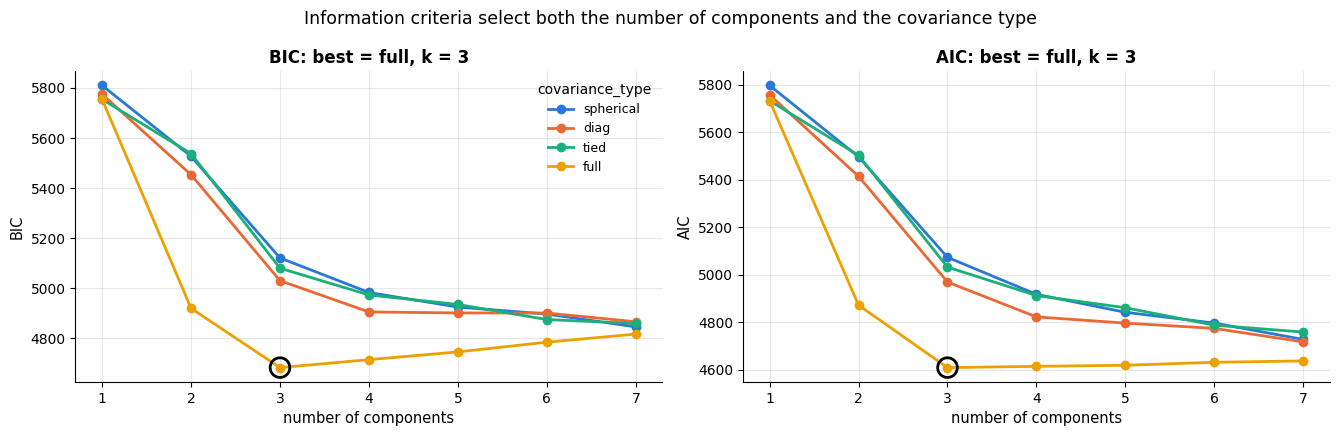

n_components          1       2       3       4       5       6       7
covariance_type                                                        
diag             5774.0  5453.0  5031.0  4906.0  4902.0  4902.0  4867.0
full             5754.0  4920.0  4684.0  4715.0  4746.0  4785.0  4817.0
spherical        5809.0  5527.0  5121.0  4983.0  4925.0  4897.0  4846.0
tied             5754.0  5537.0  5080.0  4974.0  4936.0  4875.0  4860.0


In [20]:
comp_range = range(1, 8)                         # 1 to 7 components
cov_types = ["spherical", "diag", "tied", "full"]
records = []
for ct in cov_types:
    for nc in comp_range:
        # max_iter=200 allows more EM iterations than the default 100
        g = GaussianMixture(n_components=nc, covariance_type=ct, n_init=2,
                            random_state=RANDOM_STATE, max_iter=200).fit(X_gmm)
        # .bic / .aic: the two information criteria of the fitted model (lower is better)
        records.append({"covariance_type": ct, "n_components": nc,
                        "BIC": g.bic(X_gmm), "AIC": g.aic(X_gmm)})
bic_df = pd.DataFrame(records)                   # a list of dicts -> one row per dict, one column per key (28 rows)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharex=True)   # sharex=True: both panels share the x-axis
for crit, ax in zip(["BIC", "AIC"], axes):
    for i, ct in enumerate(cov_types):
        sub = bic_df[bic_df["covariance_type"] == ct]                # boolean filter: the rows of this type
        ax.plot(sub["n_components"], sub[crit], marker="o", color=PALETTE[i], label=ct)
    best = bic_df.loc[bic_df[crit].idxmin()]     # idxmin(): the index label of the smallest value; .loc: that row
    # a hollow ring (facecolor="none") around the best model
    ax.scatter([best["n_components"]], [best[crit]], s=200, facecolor="none",
               edgecolor="black", lw=2, zorder=5)
    ax.set_xlabel("number of components")
    ax.set_ylabel(crit)
    ax.set_title(f"{crit}: best = {best['covariance_type']}, k = {int(best['n_components'])}")
axes[0].legend(title="covariance_type", fontsize=9)
fig.suptitle("Information criteria select both the number of components and the covariance type",
             fontsize=12.5)
plt.tight_layout()
plt.show()

# pivot reshapes the long table into a grid: one row per covariance type, one column per number of components
print(bic_df.pivot(index="covariance_type", columns="n_components", values="BIC").round(0))

Both criteria recover the truth: three components with full covariances. Note that they
select the *covariance type* too — a genuinely useful property, since that choice is
otherwise pure guesswork.

> **Warning.** BIC assumes the model family contains the truth. On real data it usually
> does not, and BIC then tends to keep adding components to approximate a non-Gaussian
> shape. Treat the selected $k$ as "the number of Gaussians needed to describe this data
> well", not as "the number of real groups".

## 6. Evaluating a clustering

### 6.1 Internal indices: silhouette, Davies–Bouldin, Calinski–Harabasz

When there are no labels, we can only measure geometry: are clusters compact and well
separated? The **silhouette** (Rousseeuw, 1987) does this per point. For point $i$ in
cluster $A$ with $|A| > 1$, let

$$
a_i = \frac{1}{|A| - 1}\sum_{j \in A,\, j \ne i} d(i, j), \qquad
b_i = \min_{C \ne A} \frac{1}{|C|}\sum_{j \in C} d(i, j),
$$

so $a_i$ is the mean distance to its own cluster and $b_i$ the mean distance to the nearest
*other* cluster. The silhouette is

$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1],
$$

with $s_i = 0$ for singleton clusters by convention. Values near 1 mean the point sits
comfortably inside its cluster; near 0 that it is on a boundary; negative that it is closer
to another cluster than to its own. Twenty lines implement it exactly:

In [21]:
# silhouette_samples: one silhouette per point | silhouette_score: their mean |
# davies_bouldin_score, calinski_harabasz_score: two more internal indices (explained after the next figure)
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score


def silhouette_by_hand(X, labels):
    """Per-sample silhouette coefficients, straight from the definition.

    X is (n, d) and labels (n,). Returns s of shape (n,). It builds the full (n, n) distance
    matrix, so it is only meant for small n.
    """
    X = np.asarray(X, dtype=float)
    # all pairwise Euclidean distances by broadcasting: (n, 1, d) - (1, n, d) -> (n, n, d), summed over d -> (n, n);
    # np.maximum(..., 0.0) is only a safety guard before the square root
    D = np.sqrt(np.maximum(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=-1), 0.0))
    labels = np.asarray(labels)
    uniq = np.unique(labels)                 # the distinct cluster labels
    s = np.zeros(len(X))                     # one coefficient per point
    for i in range(len(X)):
        own = labels == labels[i]            # boolean mask: the points in i's cluster, including i itself
        n_own = own.sum()
        if n_own == 1:                       # a singleton cluster gets s = 0 by convention
            continue
        # a: mean distance to the other members of its own cluster (D[i, i] = 0 adds nothing to the sum)
        a = D[i, own].sum() / (n_own - 1)    # exclude the point itself
        # b: the mean distance to every other cluster c (the "if" skips i's own cluster); the smallest wins
        b = min(D[i, labels == c].mean() for c in uniq if c != labels[i])
        s[i] = (b - a) / max(a, b)
    return s


X_sil, y_sil = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)
lab_sil = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_sil)
mine, reference = silhouette_by_hand(X_sil, lab_sil), silhouette_samples(X_sil, lab_sil)   # both shape (400,)
# :.2e prints in scientific notation with 2 decimals
print(f"largest disagreement with sklearn's silhouette_samples: {np.abs(mine - reference).max():.2e}")
print(f"mean silhouette: ours {mine.mean():.4f} | sklearn {silhouette_score(X_sil, lab_sil):.4f}")

largest disagreement with sklearn's silhouette_samples: 2.00e-15
mean silhouette: ours 0.7935 | sklearn 0.7935


The **silhouette plot** — one sorted horizontal bar per point, grouped by cluster — is the
classic diagnostic, and it shows far more than the average ever could.

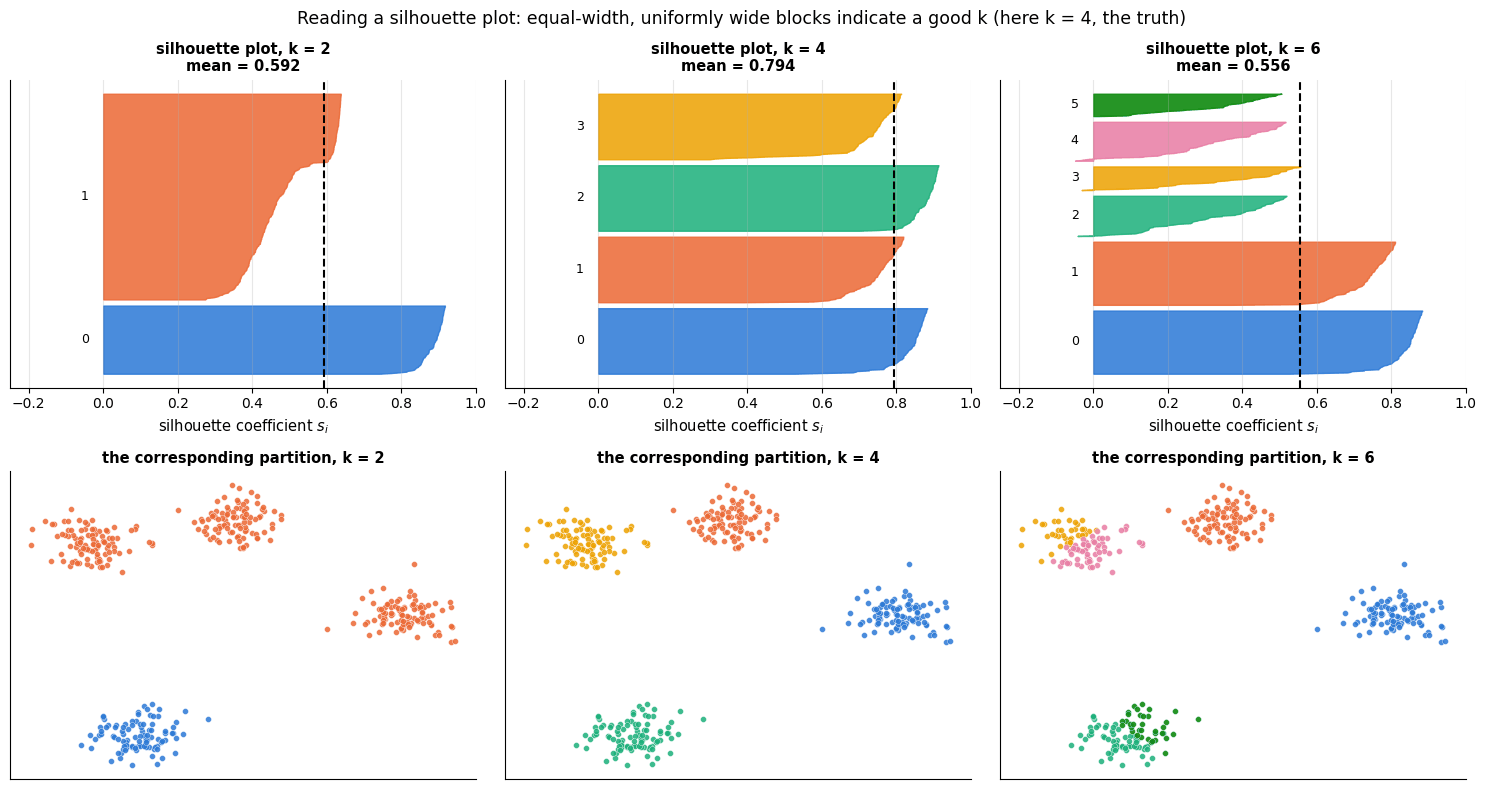

In [22]:
def silhouette_plot(ax, X, labels, title):
    """Draw a silhouette plot on ax and return the per-point silhouette values.

    Each cluster becomes a block of horizontal bars, one bar per point, sorted by length; the dashed
    vertical line is the mean silhouette. X is (n, d), labels (n,), title the start of the panel title.
    """
    s = silhouette_by_hand(X, labels)
    y_lower = 5                                         # height at which the next cluster's block starts
    for j, lab in enumerate(sorted(set(labels))):
        vals = np.sort(s[labels == lab])                # this cluster's silhouettes, ascending
        # fill_betweenx(y, x1, x2) shades horizontally from x1 = 0 to x2 = vals at each height y: one bar per point
        ax.fill_betweenx(np.arange(y_lower, y_lower + len(vals)), 0, vals,
                         color=PALETTE[j % len(PALETTE)], alpha=0.85)
        ax.text(-0.06, y_lower + len(vals) / 2, str(lab), va="center", fontsize=9)   # cluster label, left of the block
        y_lower += len(vals) + 8                        # leave a gap of 8 before the next block
    ax.axvline(s.mean(), color="black", ls="--", lw=1.5)   # the mean silhouette
    ax.set_xlim(-0.25, 1.0)
    ax.set_yticks([])
    ax.set_xlabel("silhouette coefficient $s_i$")
    ax.set_title(f"{title}\nmean = {s.mean():.3f}", fontsize=10.5)
    return s


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, k in enumerate([2, 4, 6]):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_sil)
    # top row: the silhouette plot, bottom row: the partition it describes
    silhouette_plot(axes[0, col], X_sil, labels_k, f"silhouette plot, k = {k}")
    cluster_scatter(axes[1, col], X_sil, labels_k, title=f"the corresponding partition, k = {k}")
fig.suptitle("Reading a silhouette plot: equal-width, uniformly wide blocks indicate a good k "
             "(here k = 4, the truth)", fontsize=12.5)
plt.tight_layout()
plt.show()

What to look for: at $k=4$ the four blocks have similar widths (balanced cluster sizes) and
similar shapes, and almost every bar reaches past the dashed mean line. At $k=2$ three true
clusters are forced into one block whose bars fall away in a long tail towards zero — those
are the points sitting with a cluster they do not belong to. At $k=6$ two clusters have been
split in half; the four thin blocks that result lie almost entirely *left* of the mean line,
which is the signature of over-clustering.

Two cheaper scalar indices are often reported alongside:

- **Davies–Bouldin** (Davies & Bouldin, 1979) averages, over clusters, the worst-case ratio
  of within-cluster scatter to between-centroid distance. **Lower is better**; the minimum
  is 0.
- **Calinski–Harabasz** (Caliński & Harabasz, 1974), the "variance ratio criterion", is
  between-cluster dispersion divided by within-cluster dispersion, scaled by
  $(n-k)/(k-1)$. **Higher is better.**

All three are *geometric*, and all three are biased towards the kind of clusters that
$k$-means makes: compact and convex. Watch them disagree on the nested dataset from
section 1.

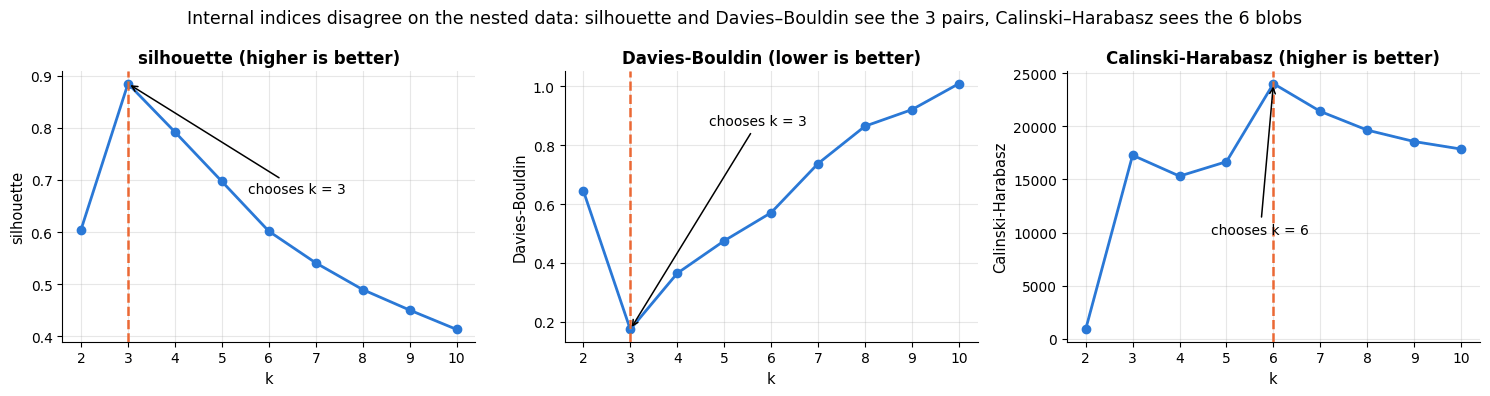

,silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,
2,0.605,0.645,892.407
3,0.885,0.174,17280.835
4,0.792,0.365,15315.223
5,0.697,0.475,16675.221
6,0.602,0.571,24017.694
7,0.541,0.738,21402.590
8,0.490,0.864,19641.838
9,0.451,0.921,18567.404
10,0.413,1.009,17858.676


In [23]:
ks = range(2, 11)                       # k = 2..10 (the indices need at least 2 clusters)
rows = []
for k in ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_nested)
    # three internal indices of the same partition; none of them looks at y_nested
    rows.append({"k": k,
                 "silhouette": silhouette_score(X_nested, lab),
                 "Davies-Bouldin": davies_bouldin_score(X_nested, lab),
                 "Calinski-Harabasz": calinski_harabasz_score(X_nested, lab)})
internal = pd.DataFrame(rows).set_index("k")   # one row per k, with k as the row index

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
# per panel: the column, its direction, the function that picks the best position, the text position
specs = [("silhouette", "higher is better", np.argmax, (0.45, 0.55)),
         ("Davies-Bouldin", "lower is better", np.argmin, (0.35, 0.80)),
         ("Calinski-Harabasz", "higher is better", np.argmax, (0.35, 0.40))]
for ax, (col, direction, pick, text_xy) in zip(axes, specs):
    ax.plot(internal.index, internal[col], marker="o", color=PALETTE[0])
    k_star = internal.index[pick(internal[col].to_numpy())]   # pick() gives a position; .index turns it into k
    ax.axvline(k_star, color=PALETTE[1], ls="--", lw=1.8)
    # .iloc[position] reads the value at that position: the tip of the arrow
    ax.annotate(f"chooses k = {k_star}", xy=(k_star, internal[col].iloc[pick(internal[col].to_numpy())]),
                xytext=text_xy, textcoords="axes fraction", fontsize=10,
                arrowprops=dict(arrowstyle="->", lw=1.1))
    ax.set_xlabel("k")
    ax.set_ylabel(col)
    ax.set_title(f"{col} ({direction})")
fig.suptitle("Internal indices disagree on the nested data: silhouette and Davies–Bouldin see the "
             "3 pairs, Calinski–Harabasz sees the 6 blobs", fontsize=12.5)
plt.tight_layout()
plt.show()
internal.round(3)                       # the last expression of a cell is displayed as its output

Neither index is wrong. Silhouette and Davies–Bouldin reward *separation*, and the three
pairs are enormously better separated than the six blobs; Calinski–Harabasz rewards
*variance explained*, which keeps improving until the six blobs are resolved. The data have
structure at two scales and the indices report different scales.

### 6.2 External indices: ARI, NMI, homogeneity and completeness

When labels *are* available — for benchmarking, or because you are validating a clustering
against a known grouping — use an external index. The essential requirement is invariance to
relabelling, because cluster identities are arbitrary.

- **Adjusted Rand index** (Hubert & Arabie, 1985). The Rand index counts pairs of points
  that the two partitions agree about (both together, or both apart) as a fraction of all
  pairs; the *adjusted* version subtracts the value expected by chance, so ARI $= 0$ for a
  random partition and $1$ for a perfect match (it can be slightly negative).
- **Normalised mutual information** and its adjusted variant (Vinh, Epps & Bailey, 2010)
  measure how much knowing the cluster tells you about the label, normalised to $[0, 1]$.
- **Homogeneity** (each cluster contains one class) and **completeness** (each class is in
  one cluster) split the story in two; their harmonic mean is the **V-measure**.

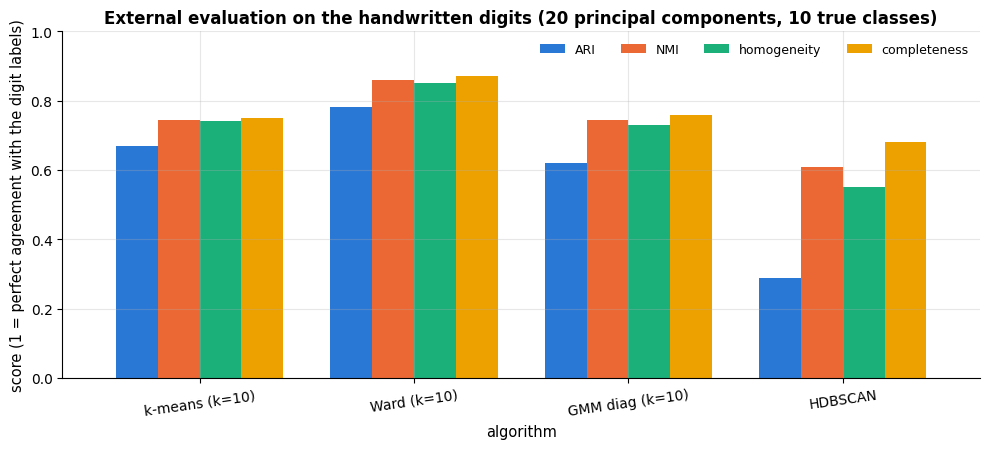

,clusters,noise %,ARI,NMI,homogeneity,completeness
algorithm,,,,,,
k-means (k=10),10,0.000,0.670,0.744,0.740,0.749
Ward (k=10),10,0.000,0.783,0.860,0.850,0.870
GMM diag (k=10),10,0.000,0.619,0.744,0.731,0.759
HDBSCAN,9,41.124,0.287,0.609,0.550,0.681


In [24]:
from sklearn.datasets import load_digits                  # 8 x 8 images of handwritten digits
from sklearn.decomposition import PCA                     # projects data onto its directions of largest variance
from sklearn.cluster import AgglomerativeClustering       # scikit-learn's hierarchical clustering (Ward by default)
# external indices: they compare the clusters with known labels (section 6.2)
from sklearn.metrics import (normalized_mutual_info_score, homogeneity_score, completeness_score)

digits = load_digits()                  # data: (1797, 64), the 8 x 8 pixels flattened; target: the digit 0-9
X_dig = digits.data / 16.0              # pixel intensities run from 0 to 16; rescale them to 0..1
# keep the first 20 principal components: Z_dig has shape (1797, 20)
Z_dig = PCA(n_components=20, random_state=RANDOM_STATE).fit_transform(X_dig)   # notebook 14, §2

# name -> unfitted model; KMeans(10, ...) and GaussianMixture(10, ...) take the number of clusters first
algorithms = {
    "k-means (k=10)": KMeans(10, n_init=10, random_state=RANDOM_STATE),
    "Ward (k=10)": AgglomerativeClustering(n_clusters=10),
    "GMM diag (k=10)": GaussianMixture(10, covariance_type="diag", n_init=3, random_state=RANDOM_STATE),
}
if HAS_HDBSCAN:
    algorithms["HDBSCAN"] = HDBSCAN(min_cluster_size=15, copy=True)

rows = []
for name, algo in algorithms.items():
    lab = algo.fit_predict(Z_dig)       # every model here has fit_predict, so one loop fits them all
    rows.append({"algorithm": name,
                 "clusters": len(set(lab) - {-1}),
                 "noise %": 100 * np.mean(lab == -1),
                 "ARI": adjusted_rand_score(digits.target, lab),
                 "NMI": normalized_mutual_info_score(digits.target, lab),
                 "homogeneity": homogeneity_score(digits.target, lab),
                 "completeness": completeness_score(digits.target, lab)})
external = pd.DataFrame(rows).set_index("algorithm")

fig, ax = plt.subplots(figsize=(10, 4.6))
# DataFrame.plot.bar: one group of bars per row (algorithm), one bar per column; rot tilts the tick labels
external[["ARI", "NMI", "homogeneity", "completeness"]].plot.bar(
    ax=ax, color=PALETTE[:4], width=0.78, rot=8)
ax.set_ylabel("score (1 = perfect agreement with the digit labels)")
ax.set_ylim(0, 1.0)
ax.set_title("External evaluation on the handwritten digits (20 principal components, 10 true classes)")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()
external.round(3)

Ward comes out clearly ahead of $k$-means on the digits (ARI 0.78 vs 0.67) — the digit
clouds are elongated and unequal in size, which suits it. HDBSCAN scores lowest on every
index, but for an interesting reason: it is free to leave points unassigned and does so for
41 % of them, and each of those counts as a mistake against the labels. Judge only the
points it *did* cluster and the picture changes:

In [25]:
if HAS_HDBSCAN:
    lab_h = HDBSCAN(min_cluster_size=15, copy=True).fit_predict(Z_dig)
    clustered = lab_h != -1             # boolean mask: the digits HDBSCAN did put into a cluster
    print(f"HDBSCAN on all 1 797 digits      : ARI {adjusted_rand_score(digits.target, lab_h):.3f}, "
          f"homogeneity {homogeneity_score(digits.target, lab_h):.3f}")
    # the same scores, restricted to the clustered digits by indexing both label arrays with the mask
    print(f"HDBSCAN on the {clustered.sum()} it clustered: "
          f"ARI {adjusted_rand_score(digits.target[clustered], lab_h[clustered]):.3f}, "
          f"homogeneity {homogeneity_score(digits.target[clustered], lab_h[clustered]):.3f}")
    print("k-means, for comparison, must assign all 1 797 and cannot abstain.")

HDBSCAN on all 1 797 digits      : ARI 0.287, homogeneity 0.550
HDBSCAN on the 1058 it clustered: ARI 0.831, homogeneity 0.871
k-means, for comparison, must assign all 1 797 and cannot abstain.


The clusters HDBSCAN commits to are much purer than its headline numbers suggest; it simply
declines to place the ambiguous digits anywhere. Whether that is a feature or a defect is a
question about your application, not about the algorithm — which is the deeper reason
external indices need to be read together rather than ranked.

> **Warning.** External indices are for *validation studies*, not for model selection in
> production. If you had the labels you would be doing supervised learning. When you report
> "ARI 0.9 against the known classes" you are answering the question "does the unsupervised
> structure coincide with this known grouping?" — which is a scientific question, not a
> performance metric.

## 7. Anomaly and outlier detection

An **anomaly** is an observation that the mechanism generating the bulk of the data is
unlikely to have produced (Hawkins' classic definition, quoted throughout Aggarwal, 2017).
Two settings are worth distinguishing, and scikit-learn names them explicitly:

- **Outlier detection** (unsupervised): the training set is already contaminated, and we
  ask which of *these* points are anomalous. `fit_predict` is the interface.
- **Novelty detection** (semi-supervised): the training set is clean, and we ask whether
  *new* points belong. `fit` on the clean data, then `predict`. `LocalOutlierFactor` needs
  `novelty=True` for this mode.

Every detector in scikit-learn exposes `decision_function` (negative = outlier) and
`score_samples`, plus a `contamination` parameter that sets the threshold — the *assumed*
proportion of anomalies.

### 7.1 Four detectors and their inductive biases

| Detector | Model of "normal" | Key parameters |
|---|---|---|
| `EllipticEnvelope` | one Gaussian, fitted robustly with the Minimum Covariance Determinant (Rousseeuw & Van Driessen, 1999) | `contamination`, `support_fraction` |
| `IsolationForest` (Liu, Ting & Zhou, 2008) | anomalies are *easy to isolate* by random axis-aligned splits, so they sit at shallow depth in random trees | `n_estimators`, `max_samples`, `contamination` |
| `LocalOutlierFactor` (Breunig et al., 2000) | a point is anomalous if its local density is much lower than that of its $k$ neighbours | `n_neighbors`, `contamination` |
| `OneClassSVM` (Schölkopf et al., 2001) | a maximum-margin boundary around the data in an RBF feature space | `nu`, `gamma`, `kernel` |

Isolation Forest deserves a sentence of intuition because it is the usual default. Build
trees by repeatedly picking a random feature and a random split value. A point in a sparse
region gets separated from the rest after very few splits; a point inside a dense cluster
requires many. The average path length over many trees, normalised by the expected path
length in a random binary search tree, is the anomaly score. It costs $O(n \log n)$, needs
no distance computations and handles high dimensions far better than density methods.

### 7.2 What the decision functions look like

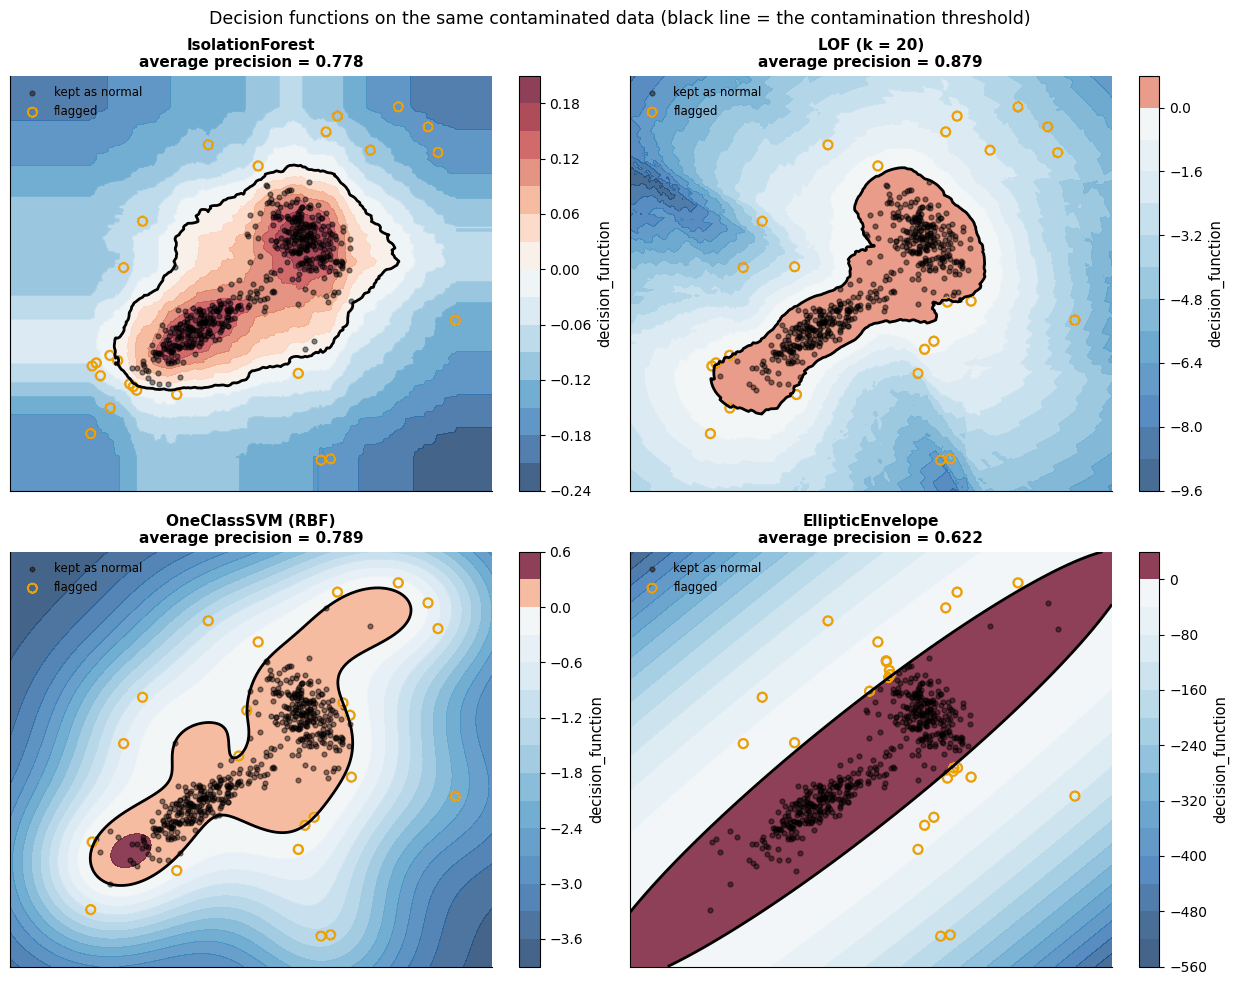

In [26]:
from sklearn.ensemble import IsolationForest       # random-split trees: anomalies are isolated after few splits
from sklearn.neighbors import LocalOutlierFactor   # compares each point's local density with its neighbours'
from sklearn.svm import OneClassSVM                # a smooth kernel boundary around the normal data
from sklearn.covariance import EllipticEnvelope    # one robustly fitted Gaussian ellipse
# average_precision_score: the area under the precision-recall curve | precision_recall_curve: the curve itself
from sklearn.metrics import average_precision_score, precision_recall_curve


def make_contaminated(rng, mode="two modes", n_in=500, n_out=25):
    """Inliers from a (uni- or bi-modal) Gaussian model plus uniform outliers. y=1 marks an outlier.

    rng    NumPy random Generator
    mode   "one mode" (one correlated Gaussian) or "two modes" (two Gaussians)
    n_in   number of inliers;  n_out  number of outliers, spread uniformly over a square around the data
    Returns X of shape (n_in + n_out, 2), with the outliers in the last rows, and y (0 = inlier, 1 = outlier).
    """
    if mode == "one mode":
        inliers = rng.multivariate_normal([0, 0], [[4.0, 3.2], [3.2, 3.0]], n_in)
        outliers = rng.uniform(-9, 9, size=(n_out, 2))
    else:
        # n_in // 2 is integer division: half of the inliers go to each mode
        inliers = np.vstack([rng.multivariate_normal([0, 0], [[1.6, 1.2], [1.2, 1.2]], n_in // 2),
                             rng.multivariate_normal([4, 4], [[0.7, -0.4], [-0.4, 0.9]], n_in - n_in // 2)])
        outliers = rng.uniform(-6, 10, size=(n_out, 2))
    X = np.vstack([inliers, outliers])
    return X, np.r_[np.zeros(n_in), np.ones(n_out)]   # labels: n_in zeros, then n_out ones


def build_detectors(contamination):
    """Return a dict {name: unfitted detector} of the four detectors, each set to flag the fraction `contamination`."""
    return {
        # n_estimators: the number of random trees; contamination: the expected outlier fraction, which sets
        # the threshold of predict() and decision_function()
        "IsolationForest": IsolationForest(n_estimators=200, contamination=contamination,
                                           random_state=RANDOM_STATE),
        # n_neighbors: the neighbourhood size; novelty=True gives LOF decision_function() and predict(), which are
        # meant for scoring new points (without it LOF only offers fit_predict on the training data)
        "LOF (k = 20)": LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True),
        # nu: an upper bound on the fraction of training points left outside the boundary;
        # gamma="scale": the RBF kernel width is set from the variance of the data
        "OneClassSVM (RBF)": OneClassSVM(nu=contamination, gamma="scale"),
        "EllipticEnvelope": EllipticEnvelope(contamination=contamination, random_state=RANDOM_STATE),
    }


X_anom, y_anom = make_contaminated(np.random.default_rng(RANDOM_STATE), mode="two modes")
detectors = build_detectors(y_anom.mean())       # y_anom.mean() is the true outlier fraction, 25 / 525

# a 220 x 220 grid covering the plot: xx and yy hold the x and the y coordinate of every grid point
xx, yy = np.meshgrid(np.linspace(-7, 11, 220), np.linspace(-7, 11, 220))
grid = np.c_[xx.ravel(), yy.ravel()]             # np.c_ puts the flattened coordinates side by side -> (48400, 2)

from matplotlib.colors import TwoSlopeNorm       # a colour normalisation with a chosen centre value

fig, axes = plt.subplots(2, 2, figsize=(12.5, 10))
for ax, (name, det) in zip(axes.ravel(), detectors.items()):
    det.fit(X_anom)
    # decision_function: positive = normal, negative = outlier; reshape back to the 220 x 220 grid
    zz = det.decision_function(grid).reshape(xx.shape)
    # centre the diverging colour map on 0, the threshold: white = the decision boundary
    norm = TwoSlopeNorm(vmin=zz.min(), vcenter=0.0, vmax=zz.max())
    # contourf fills bands of similar value (about 14 levels); contour with levels=[0] draws only the threshold line
    cf = ax.contourf(xx, yy, zz, levels=14, cmap="RdBu_r", alpha=0.75, norm=norm)
    ax.contour(xx, yy, zz, levels=[0], colors="black", linewidths=2)
    flagged = det.predict(X_anom) == -1          # predict returns -1 for an outlier and +1 for an inlier
    ax.scatter(X_anom[~flagged, 0], X_anom[~flagged, 1], s=12, color="black", alpha=0.45,   # ~ inverts a mask
               label="kept as normal")
    ax.scatter(X_anom[flagged, 0], X_anom[flagged, 1], s=42, facecolor="none",
               edgecolor=PALETTE[3], linewidth=1.6, label="flagged")
    # minus sign: higher score = more anomalous, which average_precision_score needs (y = 1 is the outlier class)
    ap = average_precision_score(y_anom, -det.decision_function(X_anom))
    ax.set_title(f"{name}\naverage precision = {ap:.3f}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.legend(loc="upper left", fontsize=8.5)
    plt.colorbar(cf, ax=ax, label="decision_function", fraction=0.046)   # fraction=0.046 keeps the bar narrow
fig.suptitle("Decision functions on the same contaminated data (black line = the contamination threshold)",
             fontsize=12.5)
plt.tight_layout()
plt.show()

The contours *are* the inductive bias, made visible. `EllipticEnvelope` draws a single
ellipse and therefore puts the region between the two modes on the "normal" side.
`IsolationForest` produces blocky, axis-aligned level sets — the trace of axis-aligned
splits. `OneClassSVM` wraps a smooth kernel boundary around the support but is famously
sensitive to `gamma` and `nu`. `LOF` is the most local: it follows the two modes closely
because it compares each point only to its own neighbourhood.

### 7.3 Evaluating with synthetic contamination

With no labels you cannot measure detector quality — so **make** labels: inject known
anomalies into clean data and measure how well they are recovered. Because anomalies are
rare, use **average precision** (the area under the precision–recall curve, notebook 7),
not accuracy or ROC-AUC, which are both flattered by the huge negative class.

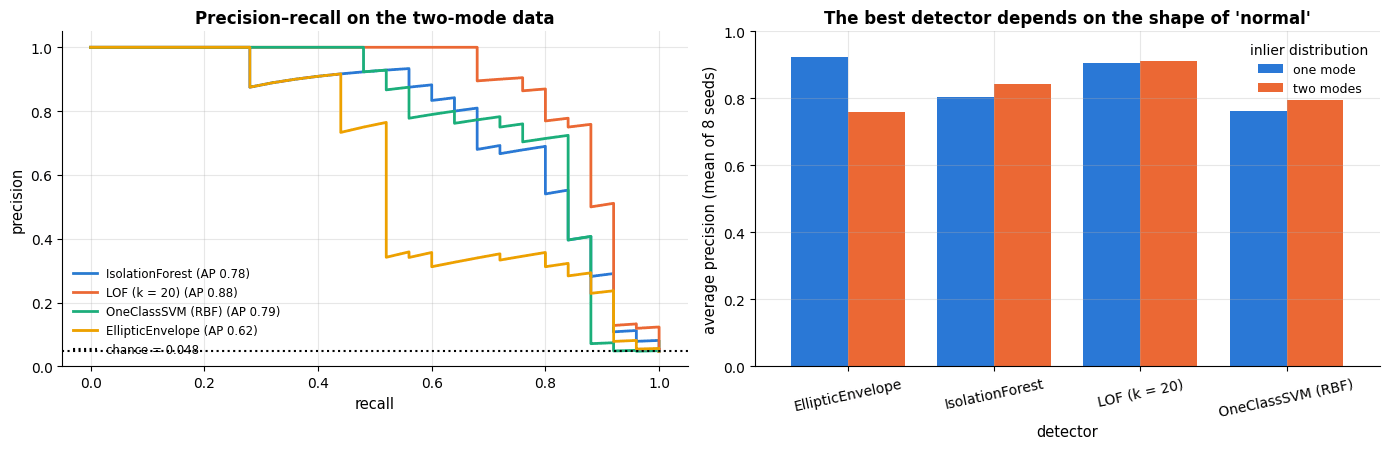

data,one mode,two modes
detector,,
EllipticEnvelope,0.924,0.760
IsolationForest,0.803,0.842
LOF (k = 20),0.905,0.910
OneClassSVM (RBF),0.763,0.795


In [27]:
modes = ["one mode", "two modes"]
ap_records = []
# 2 data shapes x 8 random datasets x 4 detectors: one average precision each
for mode in modes:
    for seed in range(8):
        r = np.random.default_rng(seed)
        Xs, ys = make_contaminated(r, mode=mode)
        for name, det in build_detectors(ys.mean()).items():   # fresh, unfitted detectors for every dataset
            det.fit(Xs)
            ap_records.append({"data": mode, "detector": name, "seed": seed,
                               "AP": average_precision_score(ys, -det.decision_function(Xs))})
ap_df = pd.DataFrame(ap_records)
# pivot_table averages over the 8 seeds: one row per detector, one column per data shape
summary = ap_df.pivot_table(index="detector", columns="data", values="AP", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
X_pr, y_pr = make_contaminated(np.random.default_rng(RANDOM_STATE), mode="two modes")   # the data of 7.2 again
for i, (name, det) in enumerate(build_detectors(y_pr.mean()).items()):
    det.fit(X_pr)
    # precision_recall_curve returns the precision and recall at every score threshold, plus the thresholds
    p, rec, _ = precision_recall_curve(y_pr, -det.decision_function(X_pr))
    axes[0].plot(rec, p, color=PALETTE[i], lw=2,
                 label=f"{name} (AP {average_precision_score(y_pr, -det.decision_function(X_pr)):.2f})")
# a random ranking has precision equal to the outlier fraction at every recall
axes[0].axhline(y_pr.mean(), color="black", ls=":", lw=1.5, label=f"chance = {y_pr.mean():.3f}")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision–recall on the two-mode data")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8.5, loc="lower left")

summary.plot.bar(ax=axes[1], color=[PALETTE[0], PALETTE[1]], rot=12, width=0.78)   # one bar per data shape
axes[1].set_ylabel("average precision (mean of 8 seeds)")
axes[1].set_ylim(0, 1)
axes[1].set_title("The best detector depends on the shape of 'normal'")
axes[1].legend(title="inlier distribution", fontsize=9)
plt.tight_layout()
plt.show()
summary.round(3)

The bar chart is the whole lesson. `EllipticEnvelope` is the **best** detector when the
inliers really are one elliptical cloud and the **worst** when there are two modes — because
its model is then wrong and it calls the empty valley between the modes "normal". `LOF` is
strong on both because it only ever makes a local claim. As always, the method that wins is
the one whose assumptions match the data.

## 8. Strengths, weaknesses and when to use each method

### 8.1 The comparison gallery

The single most useful figure in clustering: seven canonical two-dimensional datasets
against four algorithm families. Each panel reports the adjusted Rand index against the
generating groups (for the uniform dataset there are none, so we report the number of
clusters found).

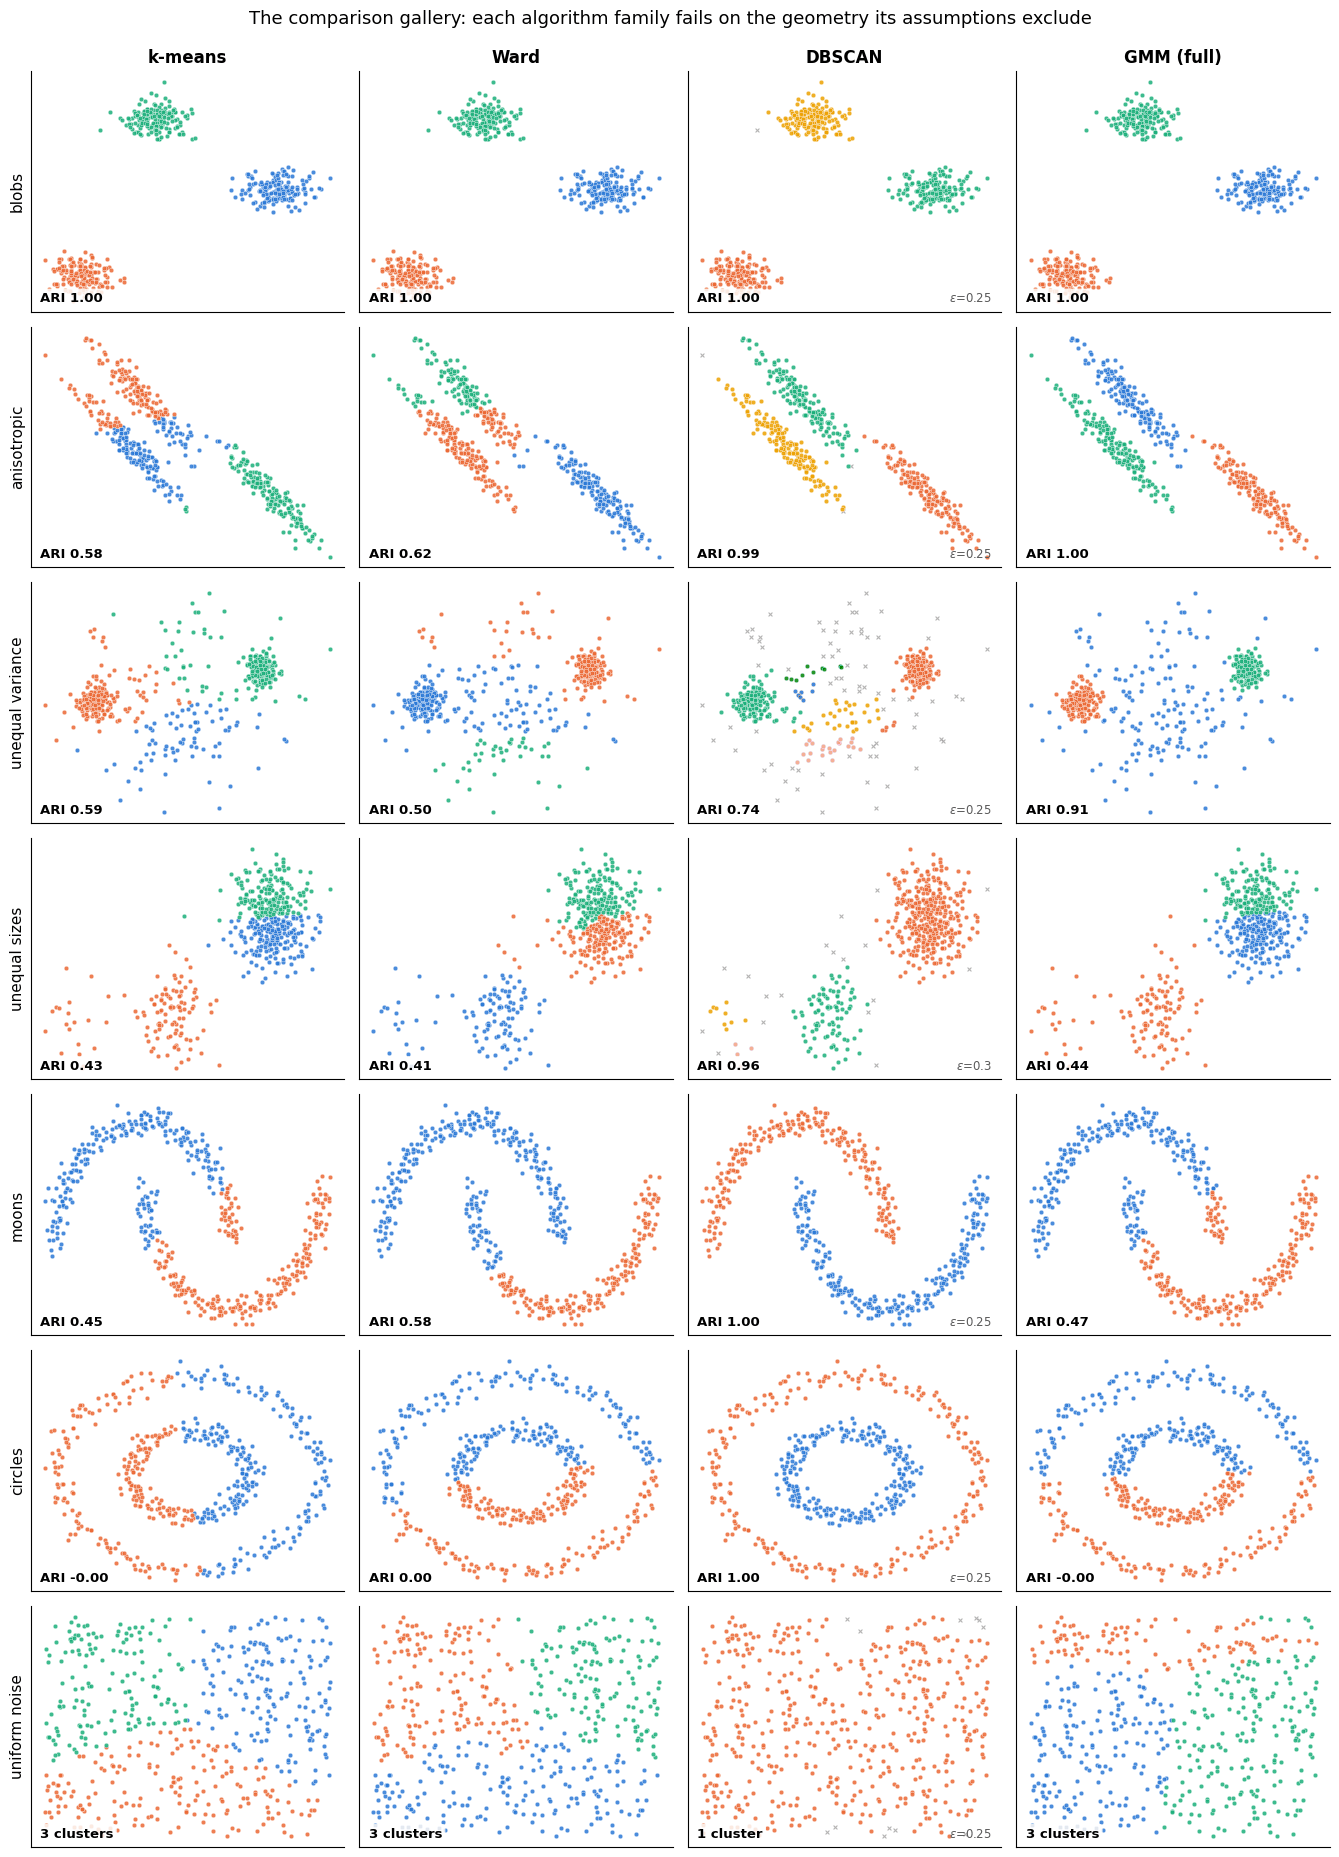

In [28]:
from sklearn.datasets import make_circles     # two concentric noisy circles

gal_rng = np.random.default_rng(RANDOM_STATE)
n_gal = 500
X_aniso, y_aniso = make_blobs(n_samples=n_gal, centers=3, cluster_std=1.0, random_state=170)
# @ is matrix multiplication: (500, 2) @ (2, 2) applies the same linear map to every point
X_aniso = X_aniso @ np.array([[0.60, -0.63], [-0.41, 0.85]])       # shear into elongated clusters

# dataset name -> (X, y, the k to ask for, DBSCAN's eps). The * in (*make_blobs(...), 3, 0.25) unpacks the
# (X, y) pair that make_blobs returns into the tuple; the uniform data has no true groups, so its y is None
gallery = {
    "blobs": (*make_blobs(n_samples=n_gal, centers=3, cluster_std=1.0, random_state=RANDOM_STATE), 3, 0.25),
    "anisotropic": (X_aniso, y_aniso, 3, 0.25),
    "unequal variance": (*make_blobs(n_samples=n_gal, centers=[[-5, 0], [0, 0], [5, 2]],
                                     cluster_std=[0.6, 3.0, 0.5], random_state=RANDOM_STATE), 3, 0.25),
    "unequal sizes": (*make_blobs(n_samples=[20, 100, 380], centers=[[-4, 0], [0, 0], [4, 3]],
                                  cluster_std=0.8, random_state=RANDOM_STATE), 3, 0.30),
    "moons": (*make_moons(n_samples=n_gal, noise=0.06, random_state=RANDOM_STATE), 2, 0.25),
    # factor=0.45: the inner circle's radius is 0.45 times the outer one's
    "circles": (*make_circles(n_samples=n_gal, noise=0.05, factor=0.45, random_state=RANDOM_STATE), 2, 0.25),
    "uniform noise": (gal_rng.uniform(-3, 3, size=(n_gal, 2)), None, 3, 0.25),
}

algo_names = ["k-means", "Ward", "DBSCAN", "GMM (full)"]
fig, axes = plt.subplots(len(gallery), 4, figsize=(13.5, 2.7 * len(gallery)))   # one row per dataset
# nested unpacking: the dict key, then the 4-tuple stored under it
for row, (dname, (Xg, yg, k_true, eps_g)) in enumerate(gallery.items()):
    Xg = StandardScaler().fit_transform(Xg)
    fitted = {                                   # algorithm name -> the labels it finds
        "k-means": KMeans(k_true, n_init=10, random_state=RANDOM_STATE).fit_predict(Xg),
        "Ward": AgglomerativeClustering(n_clusters=k_true).fit_predict(Xg),
        "DBSCAN": DBSCAN(eps=eps_g, min_samples=5).fit_predict(Xg),
        "GMM (full)": GaussianMixture(k_true, covariance_type="full", n_init=2,
                                      random_state=RANDOM_STATE).fit_predict(Xg),
    }
    for col, aname in enumerate(algo_names):
        ax = axes[row, col]
        lab = fitted[aname]
        n_found = len(set(lab) - {-1})
        # the ARI when true groups exist, otherwise the number of clusters found ("s" added only for plurals)
        note = (f"ARI {adjusted_rand_score(yg, lab):.2f}" if yg is not None
                else f"{n_found} cluster" + ("s" if n_found != 1 else ""))
        cluster_scatter(ax, Xg, lab, s=11, title=None)
        # transform=ax.transAxes: (0.03, 0.04) is in panel fractions, i.e. the lower-left corner;
        # bbox draws a white rounded box behind the text
        ax.text(0.03, 0.04, note, transform=ax.transAxes, fontsize=9.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="none"))
        if row == 0:
            ax.set_title(aname, fontsize=12)
        if col == 0:
            ax.set_ylabel(dname, fontsize=11)
    # write the eps used in the lower-right corner of the DBSCAN panel (column 2)
    axes[row, 2].text(0.97, 0.04, f"$\\varepsilon$={eps_g}", transform=axes[row, 2].transAxes,
                      fontsize=8.5, ha="right", color="0.35")
fig.suptitle("The comparison gallery: each algorithm family fails on the geometry its assumptions exclude",
             fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.985))      # rect keeps the top 1.5 % of the figure free for the suptitle
plt.show()

Read it row by row.

- **Blobs** — everything works. Toy benchmarks that look like this tell you nothing.
- **Anisotropic** — $k$-means and Ward cut the elongated clusters *across* their long axis,
  because both minimise a spherical within-cluster scatter. The full-covariance GMM
  recovers them perfectly: its ellipses can rotate.
- **Unequal variance** — one broad cluster flanked by two tight ones. $k$-means and Ward
  both steal the outskirts of the broad cluster and give them to its neighbours, because
  every point goes to the nearest *centre* regardless of how spread its own cluster is.
  DBSCAN, whose density threshold is equally global, fragments the broad cluster into
  several pieces. Only the GMM, whose per-component covariance can be broad or tight,
  gets it nearly right — this is the row that justifies the extra parameters of a mixture
  model.
- **Unequal sizes** — $k$-means splits the large cluster and merges the small ones: the SSE
  objective is dominated by the big cluster, so balancing the cluster masses lowers the
  objective more than respecting the true groups.
- **Moons** and **circles** — no centroid- or variance-based method can represent a
  non-convex cluster. DBSCAN, which only asks about connectivity, gets both exactly right.
- **Uniform noise** — there is nothing to find. $k$-means, Ward and the GMM dutifully
  return three clusters anyway; DBSCAN returns one (or none), which is the honest answer.

Note the asterisk on DBSCAN's success: `eps` was chosen per dataset from its $k$-distance
plot. That is a real cost, and section 9.3 shows just how sharply the result depends on it.

### 8.2 $k$-means always finds $k$ clusters

The last row deserves its own demonstration, because it is the failure mode that costs
practitioners the most credibility: **an algorithm asked for $k$ clusters returns $k$
clusters, and the standard diagnostics will not necessarily tell you that they are
meaningless.**

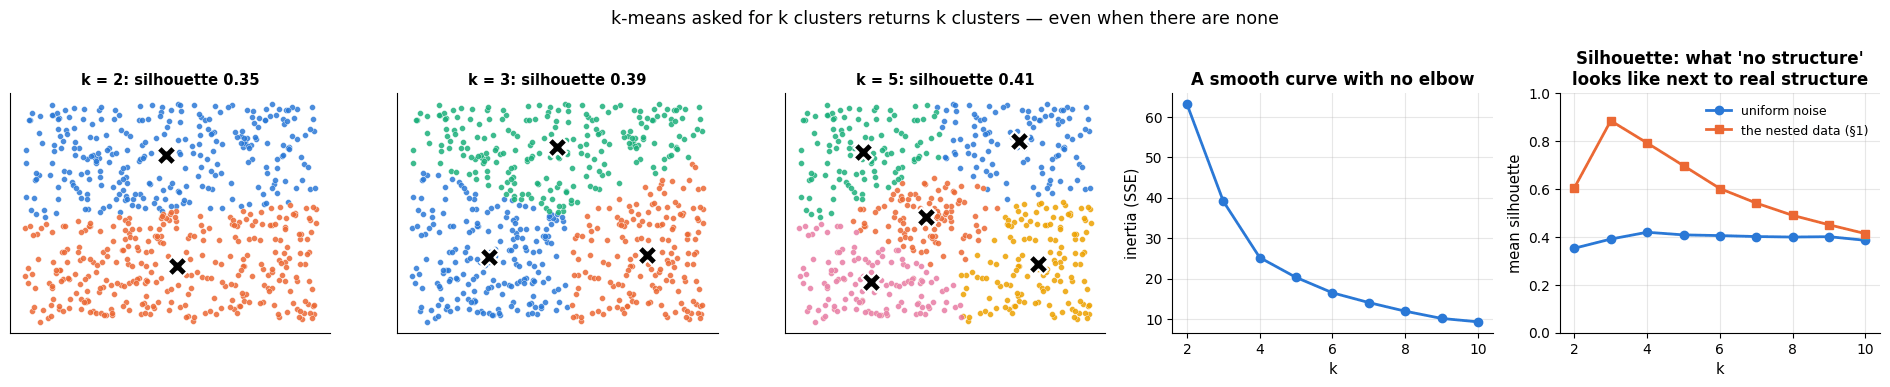

silhouette on uniform noise, k = 2..10: min 0.35, max 0.42
silhouette on the nested data of section 1: max 0.88


In [29]:
X_unif = rng.uniform(0, 1, size=(600, 2))        # 600 points spread uniformly over the unit square: no clusters

ks_u = list(range(2, 11))
inertia_u, sil_u = [], []
for k in ks_u:                                   # SSE and mean silhouette of k-means on pure noise, k = 2..10
    km_u = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_unif)
    inertia_u.append(km_u.inertia_)
    sil_u.append(silhouette_score(X_unif, km_u.labels_))
sil_nested = internal["silhouette"].to_numpy()      # computed in section 6.1, same k range

fig, axes = plt.subplots(1, 5, figsize=(19, 3.9))
for ax, k in zip(axes[:3], [2, 3, 5]):           # the first three panels: the partitions for k = 2, 3, 5
    km_u = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_unif)
    cluster_scatter(ax, X_unif, km_u.labels_, centers=km_u.cluster_centers_,
                    title=f"k = {k}: silhouette {silhouette_score(X_unif, km_u.labels_):.2f}")
axes[3].plot(ks_u, inertia_u, marker="o", color=PALETTE[0])
axes[3].set_xlabel("k"); axes[3].set_ylabel("inertia (SSE)")
axes[3].set_title("A smooth curve with no elbow")
axes[4].plot(ks_u, sil_u, marker="o", color=PALETTE[0], label="uniform noise")
axes[4].plot(ks_u, sil_nested, marker="s", color=PALETTE[1], label="the nested data (§1)")
axes[4].set_ylim(0, 1)
axes[4].set_xlabel("k"); axes[4].set_ylabel("mean silhouette")
axes[4].set_title("Silhouette: what 'no structure'\nlooks like next to real structure")
axes[4].legend(fontsize=9)
fig.suptitle("k-means asked for k clusters returns k clusters — even when there are none", fontsize=12.5)
plt.tight_layout()
plt.show()

print(f"silhouette on uniform noise, k = 2..10: min {min(sil_u):.2f}, max {max(sil_u):.2f}")
print(f"silhouette on the nested data of section 1: max {max(sil_nested):.2f}")

The partitions look plausible in isolation — tidy Voronoi cells with balanced masses — and
a silhouette around 0.35–0.40 is not obviously alarming until you have a reference point.
The diagnostics that *do* work here are the smooth, elbow-free inertia curve, the low
silhouette, and the fact that DBSCAN (previous figure) refuses to find any cluster at all.

> **Going deeper — the gap statistic.** Tibshirani, Walther & Hastie (2001) formalise this
> check. Compare $\log(\text{SSE}_k)$ of your data with its expectation under a uniform
> reference distribution over the data's bounding box (or PCA-aligned box), estimated by
> Monte-Carlo. The **gap** $G(k) = \mathbb{E}^*[\log \text{SSE}_k] - \log \text{SSE}_k$ is
> the amount of structure beyond what pure noise would give; the chosen $k$ is the smallest
> one whose gap is within one standard error of the next. Crucially, the method can also
> return $k = 1$ — "no clusters". Exercise 4 implements it.

### 8.3 The tables

**$k$-means (and MiniBatchKMeans)**

| | |
|---|---|
| **Assumptions / inductive bias** | clusters are convex, isotropic, of similar spread and similar size; Euclidean distance is meaningful |
| **Strengths** | very fast and scalable; trivially parallel; gives centroids you can interpret and use to assign new points; a good vector quantiser |
| **Weaknesses / failure modes** | needs $k$; converges to local minima (mitigated by `n_init` + $k$-means++); cannot represent elongated, nested or unequal-size clusters; means are pulled by outliers; degenerates in high dimensions as distances concentrate (notebook 8) |
| **Data it suits** | large $n$, modest $d$, continuous features, **always scaled**; not for categorical data (use $k$-modes or Gower distances) |
| **Complexity** | $O(n k d)$ per iteration, tens of iterations; memory $O(nd)$; `MiniBatchKMeans` is $O(b k d)$ per step |
| **Interpretability** | excellent: a centroid is a prototype, and the per-feature deviation of a centroid from the global mean describes the cluster |
| **Use it when / avoid it when** | Use as the first thing you try on scaled continuous data with roughly round groups. Avoid when clusters are non-convex or wildly unequal in size or spread. |

**Agglomerative / hierarchical**

| | |
|---|---|
| **Assumptions / inductive bias** | set by the linkage: single = connectivity, complete/average = compactness, Ward = spherical equal-variance clusters |
| **Strengths** | no $k$ required up front — the dendrogram shows *all* $k$ at once; works with any distance or precomputed similarity (cosine, Jaccard, edit distance); deterministic; the tree itself is an interpretable artefact |
| **Weaknesses / failure modes** | $O(n^2)$ memory and $O(n^2 \log n)$ time — impractical above $\sim 10^4{-}10^5$ points; greedy merges are never revisited; single linkage chains through noise; no way to assign new points without refitting |
| **Data it suits** | small to medium $n$; any metric; especially good when the hierarchy itself is the deliverable (taxonomies, phylogenies, document trees) |
| **Complexity** | $O(n^2)$ memory; $O(n^2 \log n)$ typical, $O(n^2)$ for single/Ward via nearest-neighbour chains |
| **Interpretability** | the dendrogram, plus merge heights that quantify how distinct each merge is |
| **Use it when / avoid it when** | Use when $n$ is moderate and you want structure at many scales. Avoid for big data, or when you must score new points online. |

**DBSCAN / HDBSCAN**

| | |
|---|---|
| **Assumptions / inductive bias** | clusters are connected regions of above-threshold density, separated by sparser regions; noise exists and should stay unlabelled |
| **Strengths** | finds arbitrary shapes; discovers the number of clusters; explicitly models noise, so single outliers cannot distort a cluster; HDBSCAN removes the `eps` parameter and handles varying density |
| **Weaknesses / failure modes** | DBSCAN's single global `eps` fails on clusters of different density; results are very sensitive to `eps`; struggles badly in high dimensions where all $k$-distances become similar; border points depend on processing order; no centroids and no native `predict` for new points |
| **Data it suits** | low to moderate $d$ (ideally $\le 10$, or after PCA), any cluster shape, data genuinely containing noise |
| **Complexity** | $O(n \log n)$ with a spatial index in low $d$, degrading to $O(n^2)$ in high $d$; memory $O(n)$ |
| **Interpretability** | core/border/noise labels; HDBSCAN adds a per-point `probabilities_` membership strength and a condensed tree |
| **Use it when / avoid it when** | Use for spatial data, shapes, and whenever "some points belong to nothing" is a legitimate answer. Avoid in high dimensions and when every point must get a label. |

**Gaussian mixture models**

| | |
|---|---|
| **Assumptions / inductive bias** | the data are a mixture of Gaussians; clusters are ellipsoidal, with shapes set by `covariance_type` |
| **Strengths** | soft, calibrated-ish memberships; handles elongated and correlated clusters; a real generative model (you can sample from it, and score the likelihood of new points); principled model selection by BIC/AIC, including the number of components |
| **Weaknesses / failure modes** | local optima (use `n_init`); likelihood is unbounded — a component can collapse onto a single point, hence `reg_covar`; $O(kd^2)$ parameters for `full` covariances is too many when $d$ is large; non-Gaussian clusters get approximated by several components |
| **Data it suits** | continuous features, moderate $d$ (or `diag`/`spherical`, or PCA first), $n \gg k d^2$ for full covariances |
| **Complexity** | $O(nkd^2)$ per EM iteration for `full`, $O(nkd)$ for `diag`; memory $O(nk + kd^2)$ |
| **Interpretability** | means, covariances and weights are directly readable; ellipses can be plotted in 2-D projections |
| **Use it when / avoid it when** | Use when clusters may be elongated, when you want soft memberships or a density model, or when you want BIC to choose $k$. Avoid for non-convex shapes and for very high $d$ with full covariances. |

**Anomaly detectors**

| | |
|---|---|
| **Assumptions / inductive bias** | `EllipticEnvelope`: one Gaussian population. `IsolationForest`: anomalies are few and separable by axis-aligned splits. `LOF`: anomalies have lower density than their neighbours. `OneClassSVM`: the support of the normal data is a compact region in an RBF feature space. |
| **Strengths** | Isolation Forest scales to large $n$ and high $d$ and has few parameters; LOF finds *local* anomalies that global methods miss; EllipticEnvelope is statistically efficient when its model holds; One-Class SVM gives a flexible smooth boundary |
| **Weaknesses / failure modes** | EllipticEnvelope fails on multi-modal data (shown in section 7.3); LOF is $O(n^2)$ without an index and very sensitive to `n_neighbors`; One-Class SVM is sensitive to `gamma`/`nu` and scales poorly beyond $\sim 10^4$ points; all of them require you to *assume* a contamination rate |
| **Data it suits** | Isolation Forest: anything tabular. LOF: moderate $n$, meaningful local density. EllipticEnvelope: $n > d$, roughly elliptical inliers. |
| **Complexity** | IForest $O(n \log n)$ train, $O(\log n)$ score; LOF $O(n \log n)$ to $O(n^2)$; OCSVM up to $O(n^2 {-} n^3)$; MCD $O(n d^2)$ per subset |
| **Interpretability** | scores are comparable within a model but not across models; Isolation Forest paths and LOF ratios can both be explained per point |
| **Use it when / avoid it when** | Start with Isolation Forest. Add LOF when anomalies are local rather than extreme. Use EllipticEnvelope only after checking the data look unimodal. |

## 9. Tuning guide

The hyper-parameters that matter, what they control, and — the only way to really learn
them — what changes when you turn them.

| Algorithm | Parameter | Controls | Typical range / scale | Default to start from |
|---|---|---|---|---|
| $k$-means | `n_clusters` | granularity | 2–20, linear; guided by elbow/silhouette/BIC | domain knowledge, else silhouette |
| | `n_init` | robustness to local minima | 10–50 | `10` (sklearn default) |
| | `init` | seeding | `k-means++` vs `random` | `k-means++` |
| Agglomerative | `linkage` | cluster shape | single / complete / average / ward | `ward` |
| | `n_clusters` or `distance_threshold` | where to cut | read off the dendrogram | largest merge-height gap |
| DBSCAN | `eps` | the density scale | log-ish; read off the $k$-distance plot | knee of the $k$-distance curve |
| | `min_samples` | how conservative | $d+1$ to $4d$, linear | $2d$ |
| HDBSCAN | `min_cluster_size` | smallest admissible cluster | 5–100, linear | 5–25 |
| GMM | `n_components` | granularity | 1–15, linear | chosen by BIC |
| | `covariance_type` | cluster shape / capacity | spherical → diag → tied → full | `full` if $n \gg d^2$, else `diag` |
| | `reg_covar` | guards against collapse | $10^{-6}$–$10^{-3}$, log | `1e-6` |
| IsolationForest | `contamination` | the alarm threshold | 0.001–0.1, log | your true alert budget |
| | `n_estimators`, `max_samples` | score stability | 100–500; 256 | `200`, `256` |
| LOF | `n_neighbors` | the locality scale | 10–50, linear | `20` |
| OneClassSVM | `nu`, `gamma` | boundary tightness / flexibility | 0.01–0.2; `scale` or log grid | `nu=contamination`, `gamma="scale"` |

**Tune in this order.**

1. **Scaling and features first.** No hyper-parameter fixes a badly scaled feature matrix
   or 40 noise columns. Standardise; consider PCA (notebook 14, section 2.6) if $d > 20$.
2. **The granularity parameter** — `n_clusters`, `eps`, `n_components`, `min_cluster_size`.
   This dominates everything else.
3. **The shape parameter** — `linkage`, `covariance_type`. It interacts with granularity:
   a more restrictive shape needs more clusters to fit the same data, so tune the pair
   jointly (section 9.4 does exactly that).
4. **The robustness parameters** — `n_init`, `min_samples`, `n_estimators`. Cheap
   insurance; raise them and stop thinking about them.

### 9.1 $k$ for $k$-means: the elbow and the silhouette

The two standard curves, side by side, on the nested data from section 1.

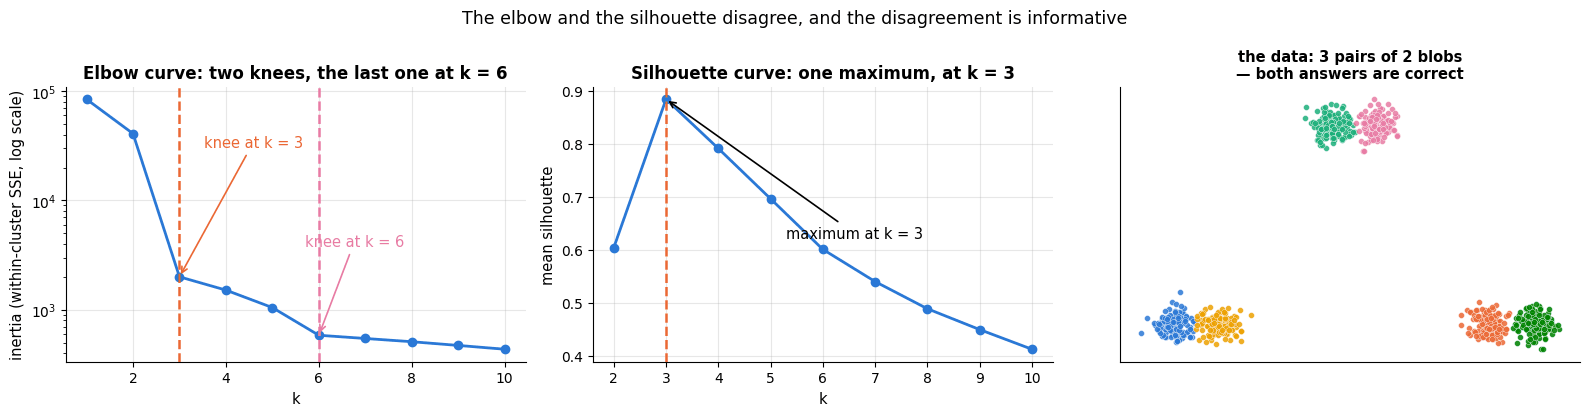

 k  inertia  SSE drop vs previous k  silhouette
 1  84544.8                     NaN         NaN
 2  40943.3                 43601.5       0.605
 3   1999.1                 38944.2       0.885
 4   1510.8                   488.2       0.792
 5   1045.3                   465.5       0.697
 6    583.1                   462.2       0.602
 7    544.9                    38.2       0.541
 8    508.9                    36.0       0.490
 9    470.6                    38.3       0.451
10    434.4                    36.2       0.413


In [30]:
ks = np.arange(1, 11)                    # k = 1..10
inertias, sils = [], []
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_nested)
    inertias.append(km_k.inertia_)
    # the silhouette needs at least 2 clusters, so k = 1 gets NaN as a placeholder
    sils.append(silhouette_score(X_nested, km_k.labels_) if k > 1 else np.nan)

k_sil = int(ks[np.nanargmax(sils)])      # np.nanargmax: position of the largest value, ignoring NaN; ks[...] -> k

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(ks, inertias, marker="o", color=PALETTE[0])
axes[0].set_yscale("log")            # without a log axis the k = 6 knee is invisible next to the k = 3 one
# mark both knees; inertias[k_knee - 1] because the list starts at k = 1
for k_knee, colour, where in [(3, PALETTE[1], (0.30, 0.78)), (6, PALETTE[4], (0.52, 0.42))]:
    axes[0].axvline(k_knee, color=colour, ls="--", lw=1.8)
    axes[0].annotate(f"knee at k = {k_knee}", xy=(k_knee, inertias[k_knee - 1]),
                     xytext=where, textcoords="axes fraction", color=colour,
                     arrowprops=dict(arrowstyle="->", lw=1.2, color=colour), fontsize=10.5)
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia (within-cluster SSE, log scale)")
axes[0].set_title("Elbow curve: two knees, the last one at k = 6")

axes[1].plot(ks[1:], sils[1:], marker="o", color=PALETTE[0])     # [1:] skips k = 1 (NaN)
axes[1].axvline(k_sil, color=PALETTE[1], ls="--", lw=1.8)
axes[1].annotate(f"maximum at k = {k_sil}", xy=(k_sil, np.nanmax(sils)),
                 xytext=(0.42, 0.45), textcoords="axes fraction",
                 arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=10.5)
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean silhouette")
axes[1].set_title(f"Silhouette curve: one maximum, at k = {k_sil}")

lab6 = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_STATE).fit_predict(X_nested)
cluster_scatter(axes[2], X_nested, lab6, title="the data: 3 pairs of 2 blobs\n— both answers are correct")
fig.suptitle("The elbow and the silhouette disagree, and the disagreement is informative",
             fontsize=12.5)
plt.tight_layout()
plt.show()

# -np.diff(inertias): how much the SSE fell from k - 1 to k; np.r_ puts NaN in front because k = 1 has no
# predecessor. to_string(index=False) prints the table without its row index
print(pd.DataFrame({"k": ks, "inertia": np.round(inertias, 1),
                    "SSE drop vs previous k": np.r_[np.nan, -np.diff(inertias)].round(1),
                    "silhouette": np.round(sils, 3)}).to_string(index=False))

The two curves carry different information, and the printed table shows why. The SSE drops
by 38 944 going from $k=2$ to $k=3$ (the three pairs separate), then by an almost constant
~470 for each of $k=4, 5, 6$ (the blobs within each pair separate, one pair at a time),
then by only ~37 thereafter. That is two knees: one at $k=3$ and one at $k=6$ — the hierarchy,
written directly into the curve. On a linear axis the second knee is invisible next to the
first, which is why the panel uses a log scale; this is the single most common reason people
"see" the wrong elbow.

The silhouette collapses the same data into one number per $k$ and can only report the
dominant scale, so it reports $k=3$: the three pairs are enormously better *separated* from
each other than the two blobs within a pair are. When the elbow's last knee and the
silhouette's maximum disagree, suspect hierarchical structure — that is a result, not a
problem. Report both, and let the application decide which scale matters.

Practical notes on these curves:

- The elbow is *subjective* and often absent. If the inertia curve is smooth, do not invent
  a corner; use the silhouette, BIC on a GMM, or the gap statistic (section 8.2).
- Plot the inertia on a **log axis**, or plot the successive differences: a knee that is
  obvious on one scale can be invisible on the other.
- Inertia decreases monotonically in $k$ by construction, so never pick $k$ by minimising it.
- The silhouette has a known bias towards small $k$ and towards convex clusters; on
  density-based clusterings it is close to meaningless.
- If the best value sits at the edge of your grid, **extend the grid** — the answer might be
  20 clusters, or 1.

### 9.2 Linkage and the dendrogram cut

For hierarchical clustering, the parameters are the linkage and the cut. Both can be read
off one picture: plot the merge heights in decreasing order and look for a large gap.

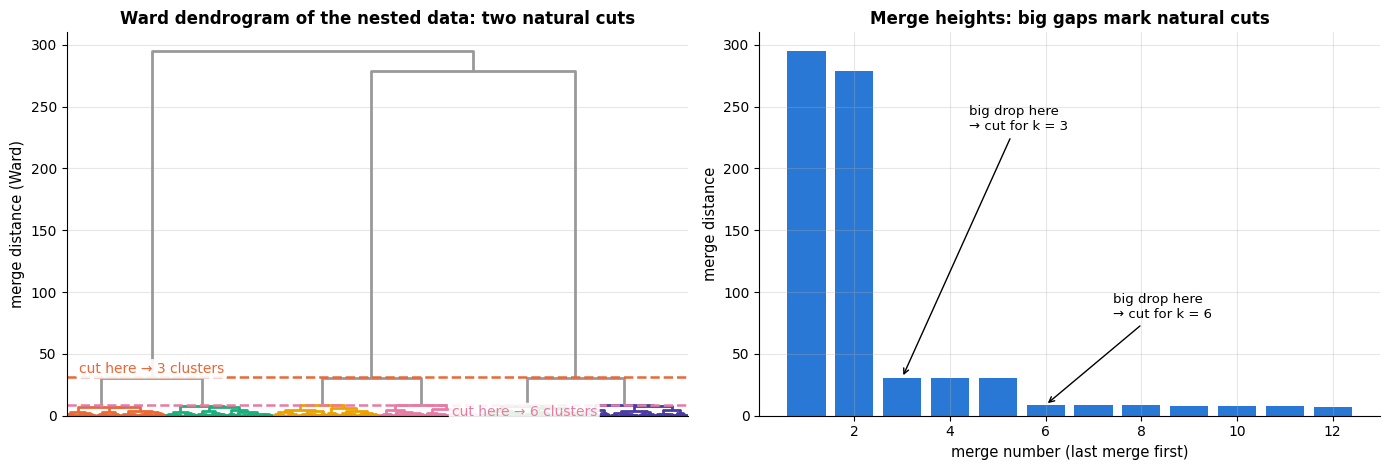

cut at k = 2: ARI vs the 6 generating blobs = 0.275
cut at k = 3: ARI vs the 6 generating blobs = 0.570
cut at k = 6: ARI vs the 6 generating blobs = 0.944
cut at k = 7: ARI vs the 6 generating blobs = 0.912


In [31]:
Z_nested = linkage(X_nested, method="ward")
# column 2 of the linkage matrix: the height of every merge, increasing; heights[-1] is the final merge.
# heights[-m] is the merge that goes from m + 1 clusters to m
heights = Z_nested[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
# links below heights[-5] (the 6 -> 5 merge) get one colour per subtree: the 6-cluster level
dendrogram(Z_nested, ax=axes[0], no_labels=True, color_threshold=heights[-5],
           above_threshold_color="0.6")
# a line just above heights[-3] crosses 3 branches (3 clusters); just above heights[-6] it crosses 6
for cut, colour in [(heights[-3] * 1.02, PALETTE[1]), (heights[-6] * 1.02, PALETTE[4])]:
    axes[0].axhline(cut, color=colour, ls="--", lw=1.8)
bbox = dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9, edgecolor="none")   # a white box behind the text
# get_yaxis_transform(): x is in panel fractions (0..1), y in data units (a merge height)
axes[0].text(0.02, heights[-3] * 1.05, "cut here → 3 clusters", transform=axes[0].get_yaxis_transform(),
             color=PALETTE[1], fontsize=10, va="bottom", bbox=bbox)
axes[0].text(0.62, heights[-6] * 0.95, "cut here → 6 clusters", transform=axes[0].get_yaxis_transform(),
             color=PALETTE[4], fontsize=10, va="top", bbox=bbox)
axes[0].set_ylabel("merge distance (Ward)")
axes[0].set_title("Ward dendrogram of the nested data: two natural cuts")

top = 12
# heights[::-1] reverses the order (last merge first) and [:top] keeps 12 of them; bar(x, height) draws one bar each
axes[1].bar(np.arange(1, top + 1), heights[::-1][:top], color=PALETTE[0])
axes[1].set_xlabel("merge number (last merge first)")
axes[1].set_ylabel("merge distance")
axes[1].set_title("Merge heights: big gaps mark natural cuts")
for idx, dy in [(3, 200), (6, 70)]:
    # bar number idx shows heights[::-1][idx - 1]; dy lifts the text above it
    axes[1].annotate(f"big drop here\n→ cut for k = {idx}", xy=(idx, heights[::-1][idx - 1]),
                     xytext=(idx + 1.4, heights[::-1][idx - 1] + dy), fontsize=9.5,
                     arrowprops=dict(arrowstyle="->", lw=1.0))
plt.tight_layout()
plt.show()

for k in [2, 3, 6, 7]:
    lab_h = fcluster(Z_nested, t=k, criterion="maxclust")   # cut the same tree into k clusters
    print(f"cut at k = {k}: ARI vs the 6 generating blobs = {adjusted_rand_score(y_nested, lab_h):.3f}")

The same two-scale structure appears as two large gaps in the merge heights. As a rule:
**Ward** unless you have a reason; **average** with a non-Euclidean metric (cosine on text,
correlation on gene expression); **single** only for connectivity problems on clean data;
**complete** when you want clusters of bounded diameter.

### 9.3 `eps` and `min_samples` for DBSCAN

DBSCAN's two parameters interact, and the honest way to see that is a two-dimensional map.
This is the most useful figure in the notebook: for every $(\varepsilon, m)$ pair it shows
both what you get (the number of clusters) and what you throw away (the noise fraction).

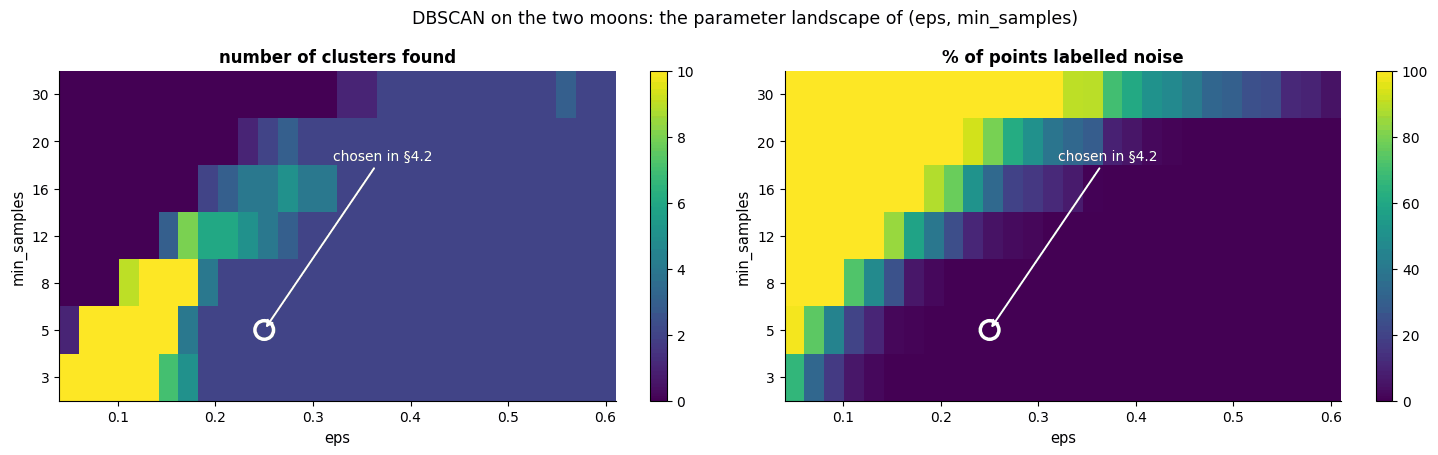

52% of the 196 grid cells give the correct 2 clusters with < 5% noise.
eps values that work for min_samples = 5: [0.19 0.21 0.23 0.25 0.27 0.29 0.31 0.34 0.36 0.38 0.4  0.42 0.44 0.46
 0.48 0.5  0.52 0.54 0.56 0.58 0.6 ]


In [32]:
eps_grid = np.linspace(0.05, 0.60, 28)                     # 28 radii from 0.05 to 0.60
ms_grid = np.array([3, 5, 8, 12, 16, 20, 30])              # 7 values of min_samples
n_clusters_map = np.zeros((len(ms_grid), len(eps_grid)))  # one row per min_samples, one column per eps: (7, 28)
noise_map = np.zeros_like(n_clusters_map)                  # zeros_like: zeros of the same shape
for i, ms in enumerate(ms_grid):
    for j, e in enumerate(eps_grid):
        lab = DBSCAN(eps=e, min_samples=int(ms)).fit_predict(X_moons)
        n_clusters_map[i, j] = len(set(lab) - {-1})
        noise_map[i, j] = np.mean(lab == -1)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
# per panel: the values, the title, the colour map and its limits
maps = [(n_clusters_map, "number of clusters found", "viridis", dict(vmin=0, vmax=10)),
        (100 * noise_map, "% of points labelled noise", "viridis", dict(vmin=0, vmax=100))]
for ax, (M, label, cmap, kw) in zip(axes, maps):
    # pcolormesh draws a grid of coloured cells; shading="nearest" centres each cell on its (eps, row) pair.
    # The rows sit at evenly spaced positions 0..6, and set_yticks labels them with the min_samples values;
    # **kw passes vmin and vmax
    im = ax.pcolormesh(eps_grid, np.arange(len(ms_grid)), M, cmap=cmap, shading="nearest", **kw)
    ax.set_yticks(np.arange(len(ms_grid)), [str(m) for m in ms_grid])
    ax.set_xlabel("eps")
    ax.set_ylabel("min_samples")
    ax.set_title(label)
    ax.grid(False)
    plt.colorbar(im, ax=ax)
    # mark the configuration used in section 4.2
    # (np.where(cond)[0] lists the positions where cond is True; [0] takes the first: the row of min_samples = 5)
    ax.scatter([eps_choice], [np.where(ms_grid == 5)[0][0]], marker="o", s=180,
               facecolor="none", edgecolor="white", linewidth=2.5)
    ax.annotate("chosen in §4.2", xy=(eps_choice, np.where(ms_grid == 5)[0][0]),
                xytext=(eps_choice + 0.07, 4.6), color="white", fontsize=10,
                arrowprops=dict(arrowstyle="->", color="white", lw=1.4))
fig.suptitle("DBSCAN on the two moons: the parameter landscape of (eps, min_samples)", fontsize=12.5)
plt.tight_layout()
plt.show()

# & combines the two boolean grids element by element; the mean of a boolean array is the fraction of True
two_cluster = (n_clusters_map == 2) & (noise_map < 0.05)
print(f"{two_cluster.mean():.0%} of the {n_clusters_map.size} grid cells give the correct "
      "2 clusters with < 5% noise.")
# row 1 of both maps is min_samples = 5; the boolean mask picks the eps values that work there
print("eps values that work for min_samples = 5:",
      np.round(eps_grid[(n_clusters_map[1] == 2) & (noise_map[1] < 0.05)], 2))

How to read it. The bottom-left corner (small `eps`, small `min_samples`) shatters the data
into a dozen or more micro-clusters. The top-left corner (small `eps`, large `min_samples`)
is the opposite failure: no point has enough neighbours to be a core point, so there are
*zero* clusters and 100 % noise. Between them runs a sharp diagonal frontier, and to its
right lies a wide plateau where the answer is a stable "2 clusters, almost no noise" — on
this dataset the plateau extends past `eps = 0.6`, though on data with less separated
clusters the right edge would eventually merge them into one.

Two things matter. First, the useful region is a **plateau, not a point**: if a small change
in `eps` changes the answer completely you are on the frontier, not in the plateau, and
should not trust the result. Second, `eps` and `min_samples` trade off *along the diagonal* —
raising `min_samples` demands a denser neighbourhood, which needs a larger radius to
satisfy — which is exactly why sweeping either one alone is misleading, and why this
two-dimensional map is worth the 196 fits it costs.

### 9.4 `n_components` and `covariance_type` for the GMM

The GMM's two parameters interact in the same way, and BIC scores them jointly.

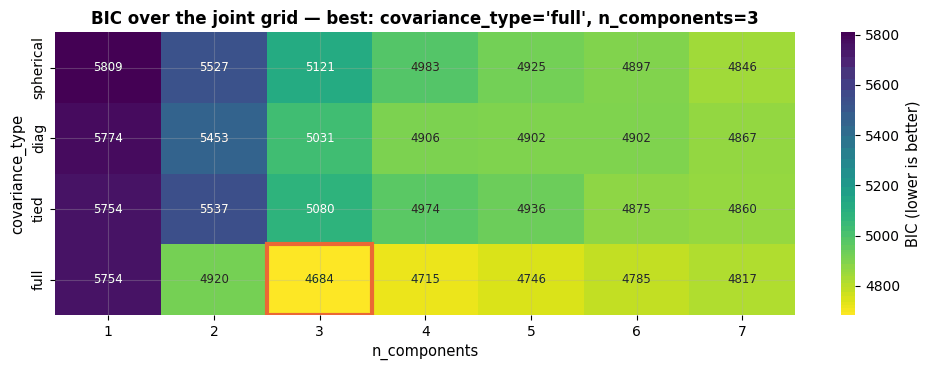

In [33]:
# the BIC table of section 5.5 as a grid: covariance types (rows) x numbers of components (columns)
bic_grid = bic_df.pivot(index="covariance_type", columns="n_components", values="BIC")
bic_grid = bic_grid.loc[["spherical", "diag", "tied", "full"]]   # rows from least to most flexible (pivot sorts A-Z)

fig, ax = plt.subplots(figsize=(10, 3.8))
# sns.heatmap colours each cell by its value; annot=True writes the value in the cell using the format fmt
# (".0f" = no decimals); "viridis_r" is viridis reversed; cbar_kws / annot_kws go to the colour bar / the cell text
sns.heatmap(bic_grid, annot=True, fmt=".0f", cmap="viridis_r", ax=ax,
            cbar_kws={"label": "BIC (lower is better)"}, annot_kws={"fontsize": 8.5})
best_row = bic_df.loc[bic_df["BIC"].idxmin()]          # the row of the long table with the lowest BIC
best_k, best_ct = int(best_row["n_components"]), str(best_row["covariance_type"])
# in heatmap coordinates the cell in row r and column c spans x from c to c + 1 and y from r to r + 1, so a 1 x 1
# rectangle at (column position, row position) outlines it; list(...).index(v) gives the position of v
ax.add_patch(plt.Rectangle((list(bic_grid.columns).index(best_k),
                            list(bic_grid.index).index(best_ct)),
                           1, 1, fill=False, edgecolor=PALETTE[1], lw=3))
ax.set_title(f"BIC over the joint grid — best: covariance_type='{best_ct}', n_components={best_k}")
ax.set_xlabel("n_components")
ax.set_ylabel("covariance_type")
plt.tight_layout()
plt.show()

Read along the rows: the more restrictive the covariance, the more components BIC wants,
because several circles are needed to tile one ellipse. `spherical` keeps improving out to
$k=7$ and never reaches the BIC of `full` at $k=3$. This is the interaction that makes a
joint grid necessary — sweeping `n_components` at a fixed `covariance_type` would have given
the wrong answer for three of the four types.

### 9.5 Tuning the anomaly detectors

Two parameters dominate: the **locality scale** (`n_neighbors` for LOF, `max_samples` for
Isolation Forest, `gamma` for One-Class SVM) and the **threshold** (`contamination`, `nu`).
They play very different roles and should be chosen differently.

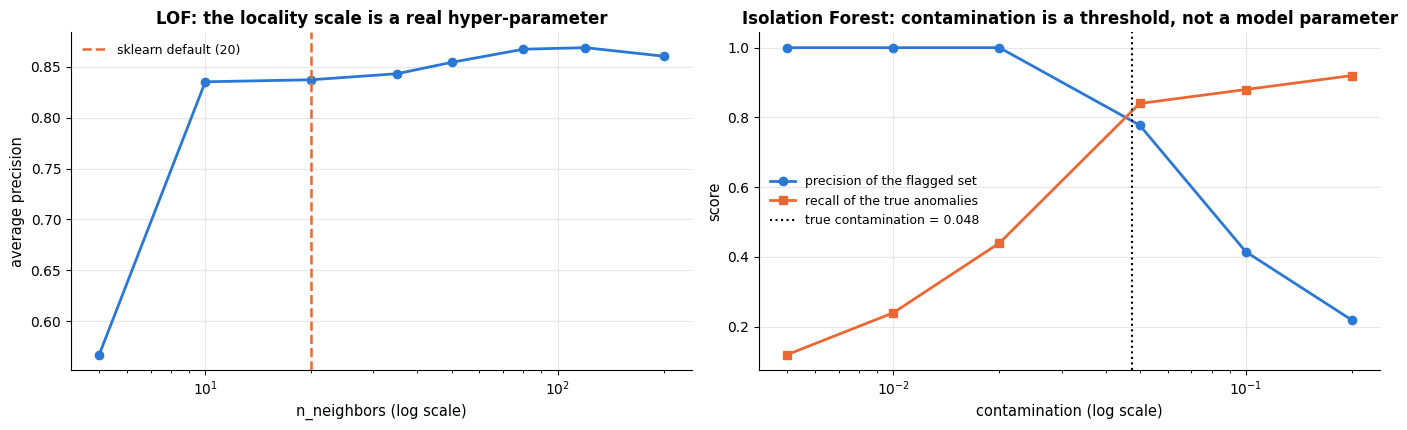

In [34]:
X_tune, y_tune = make_contaminated(np.random.default_rng(11), mode="two modes")   # a fresh two-mode dataset
neigh_grid = [5, 10, 20, 35, 50, 80, 120, 200]           # the LOF neighbourhood sizes to try
ap_lof = []
for nn in neigh_grid:
    det = LocalOutlierFactor(n_neighbors=nn, contamination=y_tune.mean(), novelty=True).fit(X_tune)
    ap_lof.append(average_precision_score(y_tune, -det.decision_function(X_tune)))

cont_grid = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])   # contamination rates from 0.5 % to 20 %
prec, rec = [], []
# score_samples: lower = more abnormal, so the minus sign makes higher = more anomalous. No contamination is
# set here, because the scores (the ranking) do not depend on it
iso_scores = -IsolationForest(n_estimators=200, random_state=RANDOM_STATE
                              ).fit(X_tune).score_samples(X_tune)
for c in cont_grid:
    thr = np.quantile(iso_scores, 1 - c)       # the score that only a fraction c of the points exceed
    flagged = iso_scores >= thr                # flag that top fraction c
    prec.append(y_tune[flagged].mean())        # precision: the share of flagged points that are true anomalies
    rec.append(y_tune[flagged].sum() / y_tune.sum())   # recall: the share of all true anomalies that were flagged

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].plot(neigh_grid, ap_lof, marker="o", color=PALETTE[0])
axes[0].axvline(20, color=PALETTE[1], ls="--", lw=1.8, label="sklearn default (20)")
axes[0].set_xscale("log")
axes[0].set_xlabel("n_neighbors (log scale)")
axes[0].set_ylabel("average precision")
axes[0].set_title("LOF: the locality scale is a real hyper-parameter")
axes[0].legend(fontsize=9)

axes[1].plot(cont_grid, prec, marker="o", color=PALETTE[0], label="precision of the flagged set")
axes[1].plot(cont_grid, rec, marker="s", color=PALETTE[1], label="recall of the true anomalies")
axes[1].axvline(y_tune.mean(), color="black", ls=":", lw=1.5,
                label=f"true contamination = {y_tune.mean():.3f}")
axes[1].set_xscale("log")
axes[1].set_xlabel("contamination (log scale)")
axes[1].set_ylabel("score")
axes[1].set_title("Isolation Forest: contamination is a threshold, not a model parameter")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

Two distinct lessons.

- **`n_neighbors` changes the model.** At $k=5$ LOF is measuring sampling noise rather than
  density and average precision collapses to 0.57; from about 10 upwards the curve rises and
  then flattens, so the default of 20 is a reasonable place to be. Push it far enough (past
  the size of the smaller mode) and LOF stops being local — its neighbourhood spans several
  modes and it degenerates towards a global detector, which is the failure this dataset is
  too small and too symmetric to display. Sweep it on injected anomalies if you can;
  otherwise stay near the default and check that the flagged set is stable across a few
  values.
- **`contamination` changes only the threshold.** The *ranking* of points by
  `score_samples` is unaffected; contamination just decides where to cut it. So do not
  agonise over it — set it from your operational capacity ("we can investigate 20 alerts a
  day, out of 10 000 events, so contamination = 0.002") and tune the ranking instead. The
  precision/recall trade-off in the right panel is the curve to show a stakeholder.

## 10. Case studies on real data

Sections 10.1 and 10.2 use **real** measurements: the wine cultivar data (Forina et al., via
the UCI repository and bundled with scikit-learn) and a photograph shipped with
scikit-learn. Section 10.3 uses the course's **simulated** hourly electricity series, chosen
deliberately because we know its generating mechanism and can therefore check whether the
detector recovers it — an honest evaluation that no real unlabelled series would allow.

### 10.1 Do the wine cultivars emerge from unlabelled chemistry?

178 wines from the same region of Italy, grown by three different cultivars, described by 13
chemical measurements (alcohol, flavanoids, colour intensity, proline, …). The cultivar
label exists, but we will hide it, cluster on chemistry alone, and only then ask whether the
clusters correspond to the cultivars. This is the classic scientific use of clustering:
*is the grouping we believe in visible in the measurements?*

In [35]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)              # as_frame=True: features as a DataFrame, target as a Series
X_wine_raw, y_wine = wine.data, wine.target  # (178, 13) chemical measurements | the cultivar: 0, 1 or 2
# np.bincount counts how often each class number occurs
print(f"{X_wine_raw.shape[0]} wines, {X_wine_raw.shape[1]} chemical features, "
      f"{len(np.unique(y_wine))} cultivars ({np.bincount(y_wine)})")
print("\nfeature scales differ by three orders of magnitude:")
# .describe() gives summary statistics per column; .loc[["mean", "std"]] keeps two of its rows
print(X_wine_raw[["proline", "magnesium", "hue", "malic_acid"]].describe().loc[["mean", "std"]].round(2))

178 wines, 13 chemical features, 3 cultivars ([59 71 48])

feature scales differ by three orders of magnitude:
      proline  magnesium   hue  malic_acid
mean   746.89      99.74  0.96        2.34
std    314.91      14.28  0.23        1.12


`proline` has a standard deviation of about 315 and `hue` about 0.23. Without scaling,
"distance between two wines" means "difference in proline". Let us cluster both ways.

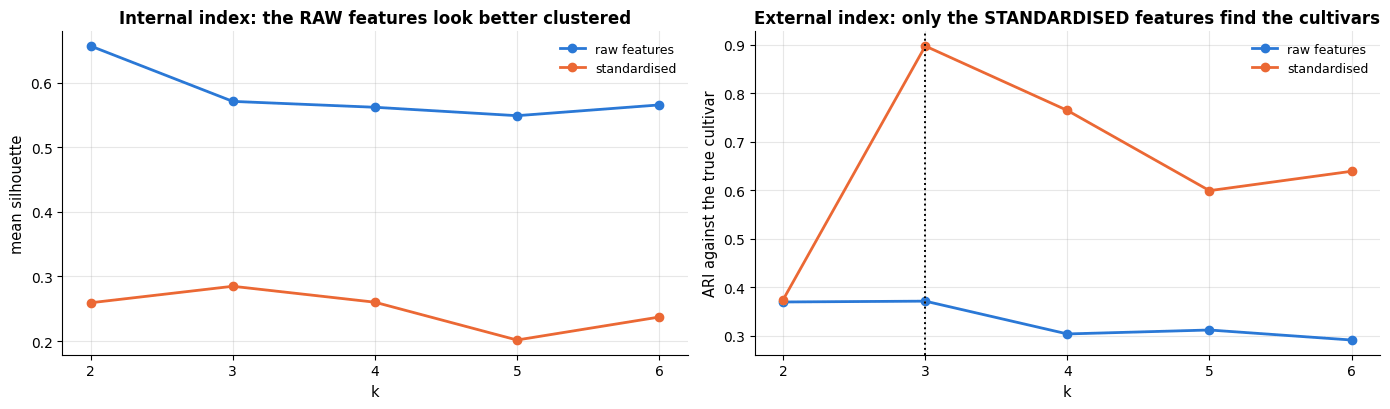

                silhouette              ARI vs cultivar             
preprocessing raw features standardised    raw features standardised
k                                                                   
2                    0.657        0.259           0.369        0.374
3                    0.571        0.285           0.371        0.897
4                    0.562        0.260           0.303        0.765
5                    0.549        0.202           0.312        0.599
6                    0.566        0.237           0.291        0.639


In [36]:
X_wine_scaled = StandardScaler().fit_transform(X_wine_raw)   # (178, 13), every column with mean 0 and std 1
results = []
for name, Xv in [("raw features", X_wine_raw.to_numpy()), ("standardised", X_wine_scaled)]:   # .to_numpy(): plain array
    for k in range(2, 7):
        lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Xv)
        # the silhouette is measured in the space that was clustered (raw or standardised)
        results.append({"preprocessing": name, "k": k,
                        "silhouette": silhouette_score(Xv, lab),
                        "ARI vs cultivar": adjusted_rand_score(y_wine, lab)})
wine_res = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
# groupby yields (group name, sub-table) pairs, with the names in sorted order
for i, (name, sub) in enumerate(wine_res.groupby("preprocessing")):
    axes[0].plot(sub["k"], sub["silhouette"], marker="o", color=PALETTE[i], label=name)
    axes[1].plot(sub["k"], sub["ARI vs cultivar"], marker="o", color=PALETTE[i], label=name)
axes[0].set_xlabel("k"); axes[0].set_ylabel("mean silhouette")
axes[0].set_title("Internal index: the RAW features look better clustered")
axes[1].set_xlabel("k"); axes[1].set_ylabel("ARI against the true cultivar")
axes[1].set_title("External index: only the STANDARDISED features find the cultivars")
axes[1].axvline(3, color="black", ls=":", lw=1.4)            # the true number of cultivars
for ax in axes:
    ax.set_xticks(range(2, 7))
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
# values=[two columns] gives two-level column headers: the metric, then the preprocessing
print(wine_res.pivot(index="k", columns="preprocessing",
                     values=["silhouette", "ARI vs cultivar"]).round(3))

This is the most important figure of the case study, and it is a warning. On the raw
features the silhouette at $k=3$ is about 0.57 — a textbook "strong structure" score — while
the ARI against the true cultivars is only 0.37. On the standardised features the silhouette
drops to 0.29, which looks much worse, yet the ARI jumps to 0.90. **The internal index
prefers the wrong clustering.** It has to: on raw features the clusters are enormous,
well-separated proline blocks, which is geometrically beautiful and chemically meaningless.

> **Key idea.** Internal validity indices measure geometry, not truth. They cannot tell you
> that your features are the wrong features. Use them to compare $k$ *within* one
> representation, never to compare representations.

In [37]:
km_wine = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_wine_scaled)
# pd.crosstab counts the wines for every (cluster, cultivar) combination. wine.target_names[y_wine] turns each
# label 0/1/2 into its name ("class_0", ...); name= sets the row and column titles
cross = pd.crosstab(pd.Series(km_wine.labels_, name="cluster"),
                    pd.Series(wine.target_names[y_wine], name="cultivar"))
matched = cross.to_numpy().max(axis=1).sum()     # per cluster (row): the count of its most common cultivar, summed
print(f"ARI = {adjusted_rand_score(y_wine, km_wine.labels_):.3f}, "
      f"NMI = {normalized_mutual_info_score(y_wine, km_wine.labels_):.3f}")
print(f"{len(y_wine) - matched} of {len(y_wine)} wines fall outside their cluster's majority cultivar\n")
cross                                            # display the table

ARI = 0.897, NMI = 0.876
6 of 178 wines fall outside their cluster's majority cultivar



cultivar,class_0,class_1,class_2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


Six wines out of 178 end up in the "wrong" cluster — and nobody told the algorithm that
cultivars exist. Let us see it, in the PCA plane (notebook 14, section 2.5, derives this
projection for exactly this dataset):

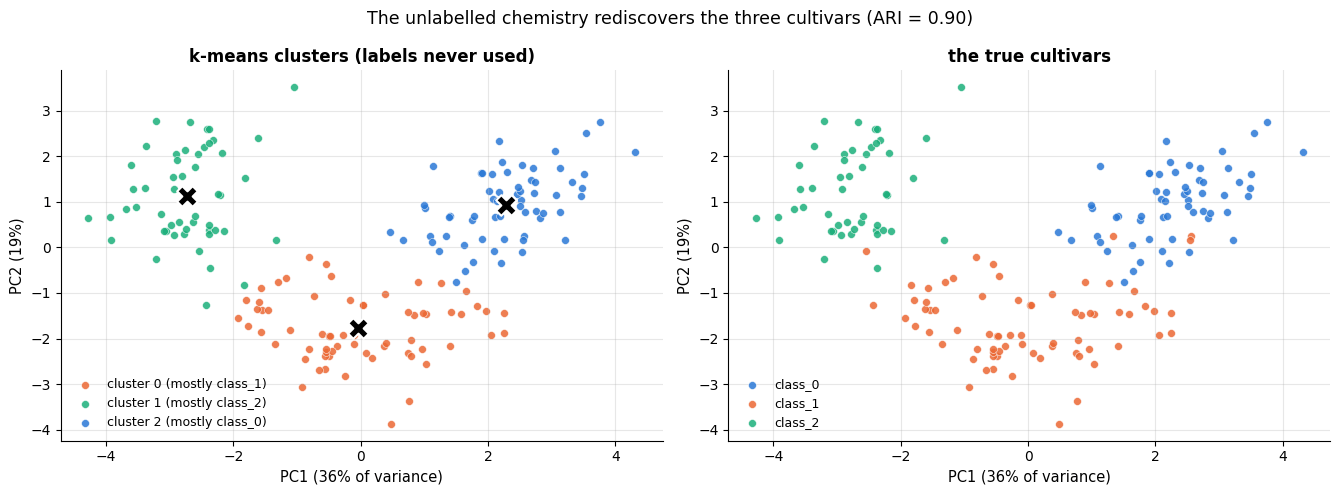

In [38]:
pca_wine = PCA(n_components=2, random_state=RANDOM_STATE)
W = pca_wine.fit_transform(X_wine_scaled)        # the wines on the first 2 principal components: (178, 2)

# Cluster numbers are arbitrary: recolour each cluster by its majority cultivar so that the
# two panels can be compared at a glance. This is presentation only — it changes no result.
# dict comprehension: cluster j -> the column position of its largest count in the crosstab (its majority cultivar)
colour_of = {j: int(cross.to_numpy()[j].argmax()) for j in range(3)}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for j in range(3):
    m = km_wine.labels_ == j
    axes[0].scatter(W[m, 0], W[m, 1], s=32, color=PALETTE[colour_of[j]], alpha=0.85,
                    edgecolor="white", linewidth=0.4,
                    label=f"cluster {j} (mostly {wine.target_names[colour_of[j]]})")
# project the three 13-D centroids into the same PCA plane -> (3, 2); .T gives (2, 3), and * unpacks it into x and y
axes[0].scatter(*pca_wine.transform(km_wine.cluster_centers_).T, marker="X", s=220,
                color="black", edgecolor="white", linewidth=1.5, zorder=5)
axes[0].set_title("k-means clusters (labels never used)")
for j, cname in enumerate(wine.target_names):
    m = y_wine == j
    axes[1].scatter(W[m, 0], W[m, 1], s=32, color=PALETTE[j], alpha=0.85,
                    edgecolor="white", linewidth=0.4, label=cname)
axes[1].set_title("the true cultivars")
for ax in axes:
    # explained_variance_ratio_[i]: the fraction of the total variance captured by component i
    ax.set_xlabel(f"PC1 ({pca_wine.explained_variance_ratio_[0]:.0%} of variance)")
    ax.set_ylabel(f"PC2 ({pca_wine.explained_variance_ratio_[1]:.0%})")
    ax.legend(fontsize=9)
fig.suptitle("The unlabelled chemistry rediscovers the three cultivars (ARI = "
             f"{adjusted_rand_score(y_wine, km_wine.labels_):.2f})", fontsize=12.5)
plt.tight_layout()
plt.show()

Finally, what *are* the clusters, chemically? Read the centroids in standardised units: a
value of $+1$ means "one standard deviation above the average wine".

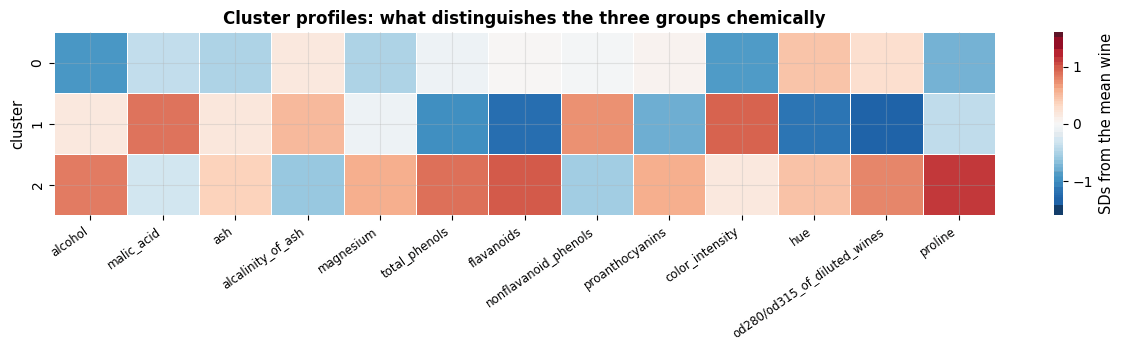

cluster 0 (n= 65): high ['hue', 'od280/od315_of_diluted_wines', 'alcalinity_of_ash'], low ['alcohol', 'color_intensity']
cluster 1 (n= 51): high ['color_intensity', 'malic_acid', 'nonflavanoid_phenols'], low ['od280/od315_of_diluted_wines', 'flavanoids']
cluster 2 (n= 62): high ['proline', 'flavanoids', 'total_phenols'], low ['alcalinity_of_ash', 'nonflavanoid_phenols']


In [39]:
# the 3 centroids in standardised units: one row per cluster, one column per feature -> (3, 13)
profile = pd.DataFrame(km_wine.cluster_centers_, columns=X_wine_raw.columns)
fig, ax = plt.subplots(figsize=(12.5, 3.6))
# center=0 puts the neutral middle colour of the diverging map at 0 (the average wine); linewidths and
# linecolor draw thin white gaps between the cells
sns.heatmap(profile, cmap="RdBu_r", center=0, vmin=-1.6, vmax=1.6, ax=ax,
            cbar_kws={"label": "SDs from the mean wine"},
            linewidths=0.4, linecolor="white")
ax.set_title("Cluster profiles: what distinguishes the three groups chemically")
ax.set_ylabel("cluster")
plt.xticks(rotation=35, ha="right", fontsize=8.5)    # tilt the 13 feature names so they do not overlap
plt.tight_layout()
plt.show()

for j in range(3):
    s = profile.loc[j].sort_values()                 # this cluster's 13 values, ascending
    # s.index[-3:][::-1]: the names of the three largest values, largest first | s.index[:2]: the two smallest;
    # :3d pads the count to 3 characters
    print(f"cluster {j} (n={np.sum(km_wine.labels_ == j):3d}): high {list(s.index[-3:][::-1])}, "
          f"low {list(s.index[:2])}")

**What to tell a non-technical stakeholder.** *"Using only the chemistry — no labels of any
kind — the wines fall into three clear groups, and those groups match the three known
cultivars for 172 of the 178 bottles. One group is defined by high proline, flavanoids and
total phenols; another by high colour intensity and malic acid; the third by high hue and
OD280 with low alcohol. So the cultivar distinction is genuinely written into the chemistry,
and a new bottle could be assigned to a cultivar from a lab report alone. Two caveats: we
had to put all 13 measurements on a common scale before this worked at all, and the method
would have produced three groups whether or not they existed — the agreement with the known
cultivars is what makes the result believable."*

Two refinements worth knowing: a `diag` Gaussian mixture does marginally better than
$k$-means here (ARI ≈ 0.92, because the cultivar clouds are slightly elongated), and running
$k$-means on the first few principal components instead of all 13 features gives essentially
the same ARI with a quarter of the dimensions — the standard PCA-before-clustering recipe
from notebook 14.

In [40]:
gm_wine = GaussianMixture(n_components=3, covariance_type="diag", n_init=10,
                          random_state=RANDOM_STATE).fit_predict(X_wine_scaled)   # fit_predict returns the labels
print(f"GMM (diag, k=3)            ARI = {adjusted_rand_score(y_wine, gm_wine):.3f}")
for n_pc in [2, 3, 5]:
    # k-means on only the first n_pc principal components
    Zw = PCA(n_components=n_pc, random_state=RANDOM_STATE).fit_transform(X_wine_scaled)
    lab_pc = KMeans(3, n_init=10, random_state=RANDOM_STATE).fit_predict(Zw)
    print(f"k-means on {n_pc} principal components  ARI = {adjusted_rand_score(y_wine, lab_pc):.3f}")
ward_wine = AgglomerativeClustering(n_clusters=3).fit_predict(X_wine_scaled)   # Ward is the default linkage
print(f"Ward (k=3)                 ARI = {adjusted_rand_score(y_wine, ward_wine):.3f}")

GMM (diag, k=3)            ARI = 0.915
k-means on 2 principal components  ARI = 0.895
k-means on 3 principal components  ARI = 0.880
k-means on 5 principal components  ARI = 0.897
Ward (k=3)                 ARI = 0.790


### 10.2 Colour quantisation: $k$-means as compression

The second application uses the other face of $k$-means. Treat every pixel of a photograph
as a point in RGB space, cluster the colours, and replace each pixel by its centroid. With
$k$ centroids the image needs $\log_2 k$ bits per pixel plus a tiny palette, instead of 24.
This is the vector-quantisation problem Lloyd was solving.

image 427x640, 273,280 pixels, 62,941 distinct colours


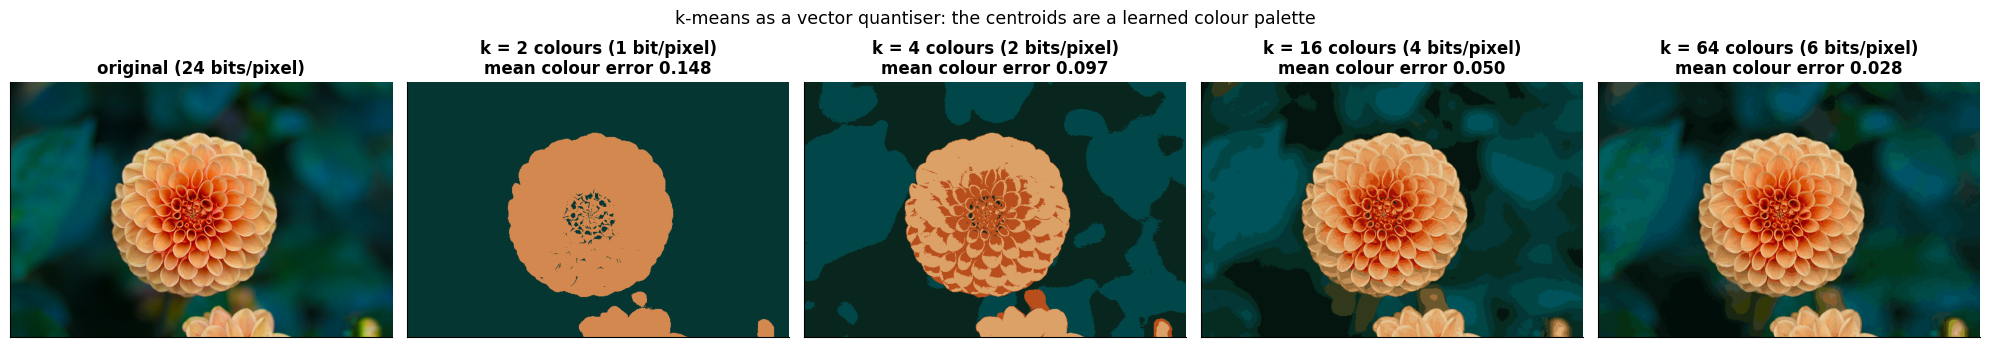

k =   2: 1 bit /pixel (  24x compression of the colour channel), mean per-pixel colour error 0.1478
k =   4: 2 bits/pixel (  12x compression of the colour channel), mean per-pixel colour error 0.0965
k =  16: 4 bits/pixel (   6x compression of the colour channel), mean per-pixel colour error 0.0500
k =  64: 6 bits/pixel (   4x compression of the colour channel), mean per-pixel colour error 0.0280


In [41]:
from sklearn.datasets import load_sample_images   # the two example photographs bundled with scikit-learn

image = load_sample_images().images[1] / 255.0          # the 'flower' photograph, 427 x 640; 0..255 -> 0..1
pixels = image.reshape(-1, 3)                           # one row per pixel, one column per colour: (273280, 3)
# 10 000 random pixels, none picked twice (replace=False)
sample = pixels[rng.choice(len(pixels), 10_000, replace=False)]   # fit on a subsample: same result, 27x faster
# np.unique(..., axis=0) keeps the distinct rows, i.e. the distinct colours; {:,} adds thousands separators
print(f"image {image.shape[0]}x{image.shape[1]}, {len(pixels):,} pixels, "
      f"{len(np.unique(pixels.round(4), axis=0)):,} distinct colours")

ks_img = [2, 4, 16, 64]
fig, axes = plt.subplots(1, len(ks_img) + 1, figsize=(4.0 * (len(ks_img) + 1), 3.6))
axes[0].imshow(image)                                   # imshow draws an (h, w, 3) array as a colour image
axes[0].set_title("original (24 bits/pixel)")
errors = []
for ax, k in zip(axes[1:], ks_img):
    km_img = KMeans(n_clusters=k, n_init=4, random_state=RANDOM_STATE).fit(sample)
    # predict gives the nearest centroid of every pixel; indexing the (k, 3) centroid array with those labels
    # replaces each pixel by its centroid's colour -> (273280, 3), reshaped back to (427, 640, 3)
    quantised = km_img.cluster_centers_[km_img.predict(pixels)].reshape(image.shape)
    # the colour distance between original and quantised pixel, averaged over all pixels
    err = np.sqrt(((quantised - image) ** 2).sum(axis=-1)).mean()
    errors.append(err)
    bits = int(np.log2(k))                              # log2(k) bits say which of the k colours a pixel uses
    ax.imshow(np.clip(quantised, 0, 1))                 # imshow expects float colours within [0, 1]
    ax.set_title(f"k = {k} colours ({bits} bit{'s' if bits != 1 else ''}/pixel)\n"
                 f"mean colour error {err:.3f}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("k-means as a vector quantiser: the centroids are a learned colour palette", fontsize=12.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

for k, err in zip(ks_img, errors):
    bits = int(np.log2(k))
    # "bit" gets an "s" only for plurals; {24 / bits:4.0f} is the compression factor, width 4, no decimals
    print(f"k = {k:3d}: {bits} bit{'s' if bits != 1 else ' '}/pixel ({24 / bits:4.0f}x compression of "
          f"the colour channel), mean per-pixel colour error {err:.4f}")

Sixteen learned colours already give a recognisable image; 64 is close to
indistinguishable at this size, at a quarter of the bits. Note two practical details that
recur whenever $k$-means is used on large data: we fit on a 10 000-pixel random subsample
and then `predict` on all 273 280 pixels (the centroids of a random subsample are excellent
estimates of the full-data centroids), and we did *not* standardise — R, G and B are already
on a common scale, and standardising them would distort colour distances.

### 10.3 Unusual hours in an electricity demand series

Two years of hourly demand with temperature. The task: **find the hours that do not fit the
pattern**, with no labels. This is the shape of most real monitoring problems.

The dataset is simulated (`course_utils.load_energy_demand()`), and that is deliberate: its
generator contains a documented public-holiday effect that reduces demand by about 15 %. We
will *withhold* the holiday flag from the detectors and then check whether they rediscover
it — a ground truth we would never have on a genuine production series.

In [42]:
energy = load_energy_demand()     # one row per hour: timestamp, demand_mw, temperature_c, is_holiday (0/1)
# .assign returns a copy with new columns; .dt.hour is 0..23 and .dt.dayofweek is 0 (Monday) to 6 (Sunday)
energy = energy.assign(hour=energy["timestamp"].dt.hour,
                       dayofweek=energy["timestamp"].dt.dayofweek)
# The key feature: demand relative to the typical demand for this hour of this weekday.
# groupby(...).transform("median") gives every row the median demand of its (hour, weekday) group,
# so the result has one value per row and lines up with energy
profile = energy.groupby(["hour", "dayofweek"])["demand_mw"].transform("median")
energy = energy.assign(profile_mw=profile, residual_mw=energy["demand_mw"] - profile)

# five columns -> (17520, 5). The hour becomes a point on a circle (sin, cos), so that 23:00 and 00:00 end up
# close together instead of 23 apart
features = np.column_stack([energy["demand_mw"], energy["temperature_c"], energy["residual_mw"],
                            np.sin(2 * np.pi * energy["hour"] / 24),
                            np.cos(2 * np.pi * energy["hour"] / 24)])
features = StandardScaler().fit_transform(features)
print(f"{features.shape[0]:,} hours x {features.shape[1]} features "
      "(demand, temperature, residual-vs-profile, and the hour as a cyclic pair)")
# is_holiday is 0/1, so its mean is the fraction of holiday hours; :.2% prints it as a percentage
print(f"holidays are {energy['is_holiday'].mean():.2%} of all hours — withheld from the detectors")

17,520 hours x 5 features (demand, temperature, residual-vs-profile, and the hour as a cyclic pair)
holidays are 1.37% of all hours — withheld from the detectors


In [43]:
CONTAMINATION = 0.01                      # we are willing to look at 1% of the hours

iso = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                      random_state=RANDOM_STATE).fit(features)
iso_flag = iso.predict(features) == -1    # True for the hours the forest calls outliers

# novelty=False (the default): plain outlier detection on the training data, so the interface is fit_predict
lof_out = LocalOutlierFactor(n_neighbors=30, contamination=CONTAMINATION)
lof_flag = lof_out.fit_predict(features) == -1

base_rate = energy["is_holiday"].mean()   # the share of holiday hours overall
rows = []
for name, flag in [("IsolationForest", iso_flag), ("LOF (k=30)", lof_flag)]:
    rate = energy.loc[flag, "is_holiday"].mean()   # the share of holiday hours among the flagged hours
    rows.append({"detector": name, "hours flagged": int(flag.sum()),
                 "% on a public holiday": 100 * rate,
                 "enrichment vs base rate": rate / base_rate,   # > 1: holidays are over-represented
                 "mean |residual| (MW)": energy.loc[flag, "residual_mw"].abs().mean()})
print(pd.DataFrame(rows).round(2).to_string(index=False))
# iso_flag & lof_flag: the hours flagged by both detectors
print(f"\nthe two detectors agree on {int((iso_flag & lof_flag).sum())} of "
      f"{int(iso_flag.sum())} flagged hours")

       detector  hours flagged  % on a public holiday  enrichment vs base rate  mean |residual| (MW)
IsolationForest            176                   3.41                     2.49                215.84
     LOF (k=30)            176                  48.86                    35.67                 84.68

the two detectors agree on 17 of 176 flagged hours


The result is striking and is the point of the whole section. Both detectors flag 1 % of the
hours, but they flag **different** hours. The Isolation Forest, which scores points by how
easy they are to isolate *globally*, flags the extremes: the coldest January nights and the
hottest August afternoons, when demand reaches its annual maximum. LOF, which compares each
point only to its own neighbourhood, flags hours whose demand is out of line *with
comparable hours* — and 49 % of those turn out to be public holidays, a 36-fold enrichment
over the 1.4 % base rate, discovered without ever seeing the holiday flag. The two sets
overlap on only 17 of 176 hours.

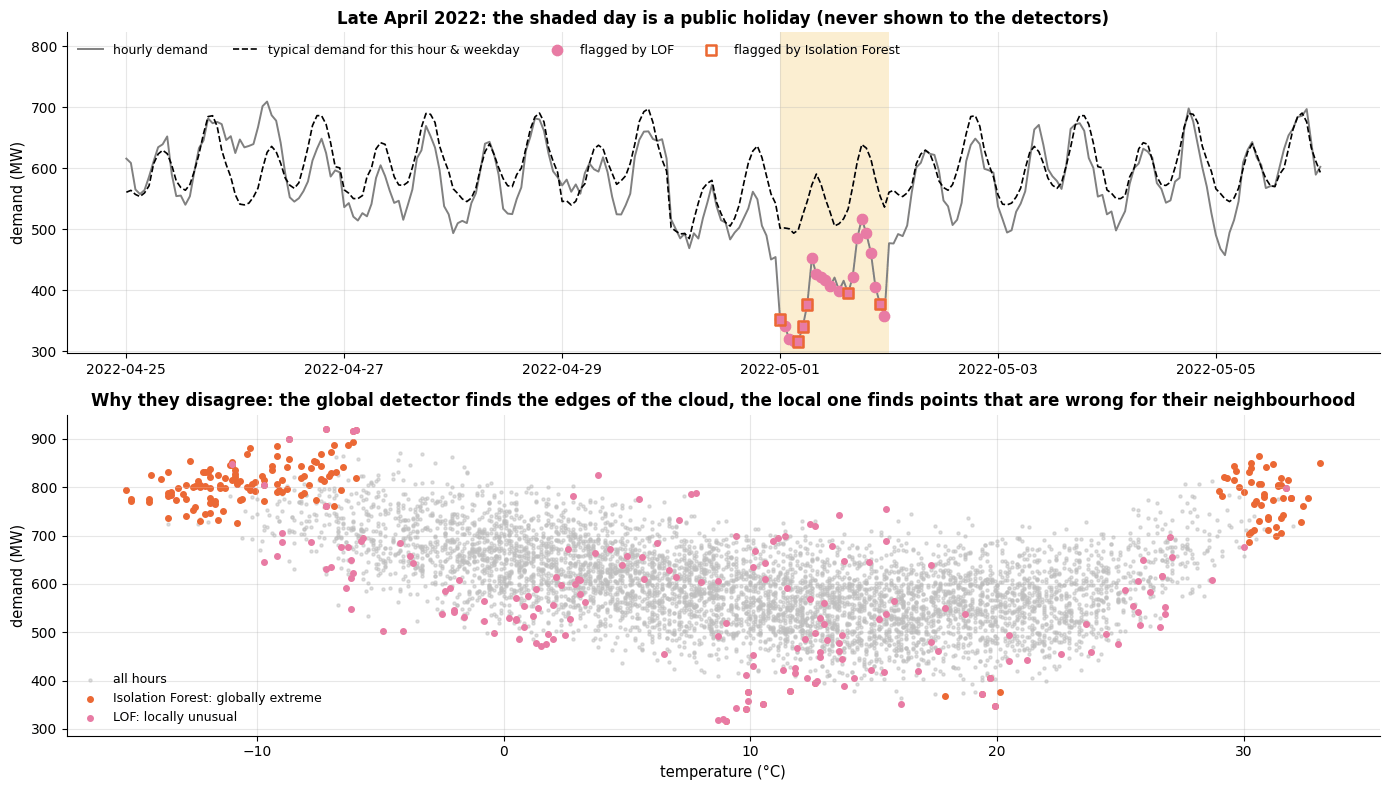

the six most locally anomalous hours according to LOF:
          timestamp  demand_mw  profile_mw  residual_mw  temperature_c  is_holiday
2022-05-01 04:00:00      316.1       499.0       -182.9            9.0           1
2022-05-01 21:00:00      405.9       583.2       -177.3           12.3           1
2022-05-01 23:00:00      358.4       536.5       -178.1            9.9           1
2022-05-01 22:00:00      377.9       555.2       -177.3           11.6           1
2022-05-01 02:00:00      320.6       501.0       -180.4            8.9           1
2022-05-01 03:00:00      317.5       493.7       -176.2            8.7           1


In [44]:
energy_flagged = energy.assign(iso=iso_flag, lof=lof_flag)   # add the two flags as boolean columns

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
# the rows from 25 April up to 5 May 2022: two date comparisons combined with &, each in parentheses
window = energy_flagged[(energy_flagged["timestamp"] >= pd.Timestamp("2022-04-25")) &
                        (energy_flagged["timestamp"] < pd.Timestamp("2022-05-06"))]
axes[0].plot(window["timestamp"], window["demand_mw"], color="0.5", lw=1.4, label="hourly demand")
axes[0].plot(window["timestamp"], window["profile_mw"], color="black", lw=1.2, ls="--",
             label="typical demand for this hour & weekday")
# window.loc[mask, column]: that column for the flagged rows only
axes[0].scatter(window.loc[window["lof"], "timestamp"], window.loc[window["lof"], "demand_mw"],
                s=55, color=PALETTE[4], zorder=5, label="flagged by LOF")
axes[0].scatter(window.loc[window["iso"], "timestamp"], window.loc[window["iso"], "demand_mw"],
                s=55, marker="s", facecolor="none", edgecolor=PALETTE[1], linewidth=1.8,
                zorder=5, label="flagged by Isolation Forest")
# .dt.floor("D") rounds each holiday timestamp down to midnight and .unique() keeps each day once;
# axvspan shades the vertical band from that midnight to the next
for day in window.loc[window["is_holiday"] == 1, "timestamp"].dt.floor("D").unique():
    axes[0].axvspan(day, day + pd.Timedelta(days=1), color=PALETTE[3], alpha=0.18, lw=0)
axes[0].set_ylabel("demand (MW)")
axes[0].set_ylim(top=window["demand_mw"].max() * 1.16)   # headroom above the curve for the legend
axes[0].set_title("Late April 2022: the shaded day is a public holiday (never shown to the detectors)")
axes[0].legend(ncol=4, fontsize=9, loc="upper left")

sub = energy_flagged.iloc[::3]           # thin the scatter for legibility: every third row
axes[1].scatter(sub["temperature_c"], sub["demand_mw"], s=5, color="0.75", alpha=0.5, label="all hours")
axes[1].scatter(energy_flagged.loc[iso_flag, "temperature_c"],
                energy_flagged.loc[iso_flag, "demand_mw"], s=16, color=PALETTE[1],
                label="Isolation Forest: globally extreme")
axes[1].scatter(energy_flagged.loc[lof_flag, "temperature_c"],
                energy_flagged.loc[lof_flag, "demand_mw"], s=16, color=PALETTE[4],
                label="LOF: locally unusual")
axes[1].set_xlabel("temperature (°C)")
axes[1].set_ylabel("demand (MW)")
axes[1].set_title("Why they disagree: the global detector finds the edges of the cloud, "
                  "the local one finds points that are wrong for their neighbourhood")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# negative_outlier_factor_ is minus the LOF score of every training point (about -1 = normal), so negate it;
# .nlargest(6, column) keeps the 6 rows with the largest LOF score, then [[...]] selects the columns to show
top = (energy_flagged.assign(lof_score=-lof_out.negative_outlier_factor_)
       .nlargest(6, "lof_score")[["timestamp", "demand_mw", "profile_mw", "residual_mw",
                                  "temperature_c", "is_holiday"]])
print("the six most locally anomalous hours according to LOF:")
print(top.to_string(index=False))

**What to tell a stakeholder.** *"One per cent of hours are flagged as unusual. Two kinds
show up: hours of genuinely record demand, driven by extreme temperature — these are
capacity events, and the model is simply reporting the weather; and hours whose demand is
far below what that hour of that weekday normally sees — these cluster almost perfectly on
public holidays. If the goal is capacity planning, use the first list. If the goal is
'something is wrong with this meter', use the second, after first removing known calendar
effects — otherwise you will spend every holiday investigating a non-incident."* That last
sentence is the real lesson of anomaly detection in production: **most of the work is
modelling the expected pattern, so that the detector is left with genuine surprises.**

## Summary

- Clustering is **ill-posed**. The features, the distance, the scaling and $k$ define what a
  cluster is; the algorithm only executes that definition. Kleinberg's impossibility theorem
  says no algorithm can escape this.
- **$k$-means** minimises within-cluster SSE by alternating assignment and mean updates
  (Lloyd's algorithm). It is fast and interpretable but assumes convex, isotropic,
  similar-sized clusters. Use `k-means++` and `n_init ≥ 10` to survive local minima.
- **Hierarchical clustering** gives every $k$ at once. Ward is the default; single linkage
  follows arbitrary shapes but chains through noise; the dendrogram's merge heights tell you
  where to cut.
- **DBSCAN** defines clusters as dense connected regions and labels the rest noise: arbitrary
  shapes, no $k$, but one global density scale. Choose `eps` from the $k$-distance plot, and
  prefer **HDBSCAN** when densities vary.
- **Gaussian mixtures** fit an explicit probability model by **EM**, giving elliptical
  clusters, soft assignments, and principled selection of both $k$ and the covariance type
  by **BIC**. $k$-means is its hard, spherical limit.
- **Internal** indices (silhouette, Davies–Bouldin, Calinski–Harabasz) measure geometry and
  are biased towards convex clusters — they can prefer a clustering that is chemically
  nonsense (wine, section 10.1). **External** indices (ARI, NMI, homogeneity/completeness)
  need labels and belong in validation studies.
- **Anomaly detection** is the density question asked from the other side. Isolation Forest
  is the scalable default, LOF finds *local* anomalies, EllipticEnvelope is best only when
  the inliers really are one ellipse. Evaluate with **average precision** on injected
  anomalies, and set `contamination` from your alert budget.
- The unglamorous majority of the work is **representation**: scaling, feature engineering,
  removing the expected pattern. Every algorithm above is one line once the features are right.

| Question | Reach for |
|---|---|
| Fast, round clusters, big $n$ | `KMeans` (scaled features, `n_init=10`) |
| Clusters of arbitrary shape, noise present | `DBSCAN`, `HDBSCAN` |
| Clusters of varying density | `HDBSCAN` |
| Elongated/correlated clusters, soft memberships | `GaussianMixture(covariance_type="full")` |
| Structure at several scales, or a taxonomy | `linkage` + `dendrogram`, `AgglomerativeClustering` |
| How many clusters? | elbow + silhouette together, BIC for a GMM, gap statistic for "are there any?" |
| Is this clustering any good? | silhouette *plot* (not just the mean), stability across seeds/subsamples, downstream utility |
| Does it match a known grouping? | `adjusted_rand_score`, `normalized_mutual_info_score` |
| Rare weird rows, tabular data | `IsolationForest` |
| Rare weird rows *relative to their neighbourhood* | `LocalOutlierFactor` |
| One elliptical population, need statistical efficiency | `EllipticEnvelope` |
| Too many features for distances to mean anything | PCA first (notebook 14), then cluster |

**Next steps:** notebook 14 (dimensionality reduction) is the natural companion — PCA before
clustering, and the warning never to cluster on t-SNE coordinates; notebook 15 applies
$k$-means and NMF to text; notebook 16 uses the residual-from-profile idea of section 10.3
as the basis of forecasting; notebook 20 (capstone) combines segmentation with a supervised
model.

## Exercises

### Exercise 1 — $k$-means++ by hand (easy)

Our `kmeans_pp_init` samples each new centre with probability proportional to $D(x)^2$.
Modify it to sample proportionally to $D(x)^p$ for $p \in \{0, 1, 2, 4\}$ ($p = 0$ is uniform
random seeding) and, for each $p$, run `lloyd` 100 times on `X_local` from section 2.3.
Plot the distribution of the final SSE for each $p$. Which exponent is best, and why does
$p = \infty$ (always pick the furthest point) fail?

<details><summary>Solution sketch</summary>

Replace `p=d2 / d2.sum()` with `w = d2 ** (p / 2); p=w / w.sum()` (remember `d2` is already
squared). Larger $p$ spreads the seeds more, which helps up to a point; $p = 2$ is a good
compromise and is the only value with a proof. With $p \to \infty$ the rule becomes
deterministic "farthest-point" seeding, which always picks outliers as centres — a single
extreme point becomes its own cluster in every run, so the variance of the result collapses
but the mean SSE gets worse.
</details>

### Exercise 2 — Silhouette with a different metric (easy)

`silhouette_by_hand` hard-codes the Euclidean distance. Refactor it to take a precomputed
distance matrix, then compare the silhouette of a $k$-means clustering of the standardised
wine data under Euclidean, Manhattan (`cityblock`) and cosine distances
(`scipy.spatial.distance.pdist` + `squareform`). Does the ranking of $k \in \{2, \dots, 6\}$
change?

<details><summary>Solution sketch</summary>

```py
from scipy.spatial.distance import pdist, squareform
D = squareform(pdist(X_wine_scaled, metric="cosine"))
```
The optimum stays at $k = 3$ for all three metrics on this dataset, but the *values* change
a lot (cosine ignores magnitude, so it is much more forgiving). That the ranking is stable
is weak evidence that the three-cluster structure is real — a cheap and underused
robustness check.
</details>

### Exercise 3 — DBSCAN on the digits (medium)

Run DBSCAN on `Z_dig` (the 20 principal components of the digits). Draw the $k$-distance
plot for `min_samples=10`, pick an `eps`, and report the number of clusters, the noise
fraction and the ARI. Then repeat with only 2 principal components. Explain the difference
in terms of the curse of dimensionality (notebook 8).

<details><summary>Solution sketch</summary>

In 20 dimensions the $k$-distance curve has no knee — all points have similar
nearest-neighbour distances — and every `eps` either labels almost everything noise or
merges everything into one cluster. In 2 dimensions there is a clear knee and DBSCAN finds
a handful of clusters, though ARI stays modest because several digits overlap in 2-D. The
moral: density-based clustering needs low-dimensional (or aggressively reduced) input.
</details>

### Exercise 4 — The gap statistic (medium)

Implement the gap statistic of Tibshirani, Walther & Hastie (2001): for $k = 1, \dots, 10$,
compute $\log(\text{SSE}_k)$ on your data and on $B = 20$ uniform reference samples drawn in
the bounding box of the data, and plot
$G(k) = \frac{1}{B}\sum_b \log \text{SSE}^{(b)}_k - \log \text{SSE}_k$ with error bars. Apply
it to `X_nested` (which has clusters) and to `X_unif` (which does not). Does it return
$k = 1$ for the uniform data?

<details><summary>Solution sketch</summary>

```py
def gap(X, k, B=20, rng=rng):
    sse = KMeans(k, n_init=10, random_state=0).fit(X).inertia_
    ref = [KMeans(k, n_init=10, random_state=0).fit(
               rng.uniform(X.min(0), X.max(0), X.shape)).inertia_ for _ in range(B)]
    return np.mean(np.log(ref)) - np.log(sse), np.std(np.log(ref)) * np.sqrt(1 + 1 / B)
```
Choose the smallest $k$ with $G(k) \ge G(k+1) - s_{k+1}$. On `X_nested` the gap rises sharply
and the rule selects 3 or 6 depending on the reference box; on `X_unif` the gap is flat and
within one standard error of zero everywhere, so the rule returns $k = 1$ — the honest
answer, which neither the elbow nor the silhouette can give.
</details>

### Exercise 5 — Clustering stability as a model-selection criterion (medium)

A clustering you can trust should not change much when the data change slightly. For
$k = 2, \dots, 8$ on `X_nested`: draw 20 pairs of bootstrap subsamples (80 % of the rows
each), cluster both, and measure the ARI between the two labellings **on the rows they
share**. Plot mean stability against $k$. Compare the peak with the elbow and the silhouette.

<details><summary>Solution sketch</summary>

Stability peaks at the $k$ values that correspond to real structure (here 3 and 6) and drops
in between, because an intermediate $k$ has to break a genuine group arbitrarily and does so
differently in each subsample. This idea — due in this form to Ben-Hur, Elisseeff & Guyon —
is often more informative than either curve and generalises to any clustering algorithm,
including DBSCAN, where no objective value is available to compare.
</details>

### Exercise 6 — An anomaly-detection pipeline for the churn data (hard)

Load `load_churn()` (notebook 4 explains the columns). Build a `ColumnTransformer` that
one-hot encodes the categorical columns and scales the numeric ones, put an
`IsolationForest` after it, and flag the 1 % most anomalous customers. Then: (a) inspect the
flagged rows — what makes them unusual? (b) compare with `LocalOutlierFactor` — do they
agree? (c) check whether the flagged customers churn at a different rate than the rest, and
explain why that comparison is *not* a validation of the detector.

<details><summary>Solution sketch</summary>

The flagged rows are typically extreme on one or two numeric columns (very high charges,
zero tenure) or carry a rare combination of categories — one-hot encoding makes a rare
category an almost-unique direction, which isolation trees split off immediately. IForest
and LOF overlap only partially, for the reason seen in section 10.3. On (c): a different
churn rate among the flagged rows is *interesting* but not a validation, because anomaly
detection never optimised for churn; a detector that flagged the 1 % of customers with the
highest charges would show the same association. Validating a detector requires either
injected anomalies with known labels or human adjudication of the alerts.
</details>

## References and further reading

### Textbooks

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. **(free)** — Chapter 14 ("Unsupervised Learning") covers $k$-means, hierarchical clustering, self-organising maps and the gap statistic.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. **(free PDF)** — Chapter 9 is the canonical derivation of mixtures of Gaussians and EM, including the general lower-bound view used in section 5.2.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. **(free)** — Chapter 21 treats clustering probabilistically and connects it to latent-variable models.
- Aggarwal, C. C. (2017). *Outlier Analysis* (2nd ed.). Springer. — The standard reference for section 7; thorough on evaluation, which most papers treat carelessly.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. **(free)** — Section 12.4 is the gentlest correct introduction to $k$-means and hierarchical clustering.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 9 is a practical tour of the same scikit-learn estimators used here.

### Papers

- Lloyd, S. P. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129–137. — The algorithm of section 2, written in 1957 as a Bell Labs memo on signal quantisation.
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297. — Where the name "$k$-means" comes from.
- Arthur, D., & Vassilvitskii, S. (2007). k-means++: the advantages of careful seeding. *Proceedings of SODA 2007*, 1027–1035. — The $D^2$ seeding of section 2.3, with the $O(\log k)$ approximation guarantee.
- Sculley, D. (2010). Web-scale k-means clustering. *Proceedings of WWW 2010*, 1177–1178. — `MiniBatchKMeans`.
- Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236–244. — Ward linkage.
- Lance, G. N., & Williams, W. T. (1967). A general theory of classificatory sorting strategies: 1. Hierarchical systems. *The Computer Journal*, 9(4), 373–380. — The recursive update formula behind every fast agglomerative implementation.
- Murtagh, F., & Legendre, P. (2014). Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *Journal of Classification*, 31(3), 274–295. — Read before trusting any software's "Ward".
- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise. *Proceedings of KDD 1996*, 226–231. — DBSCAN.
- Schubert, E., Sander, J., Ester, M., Kriegel, H.-P., & Xu, X. (2017). DBSCAN revisited, revisited: why and how you should (still) use DBSCAN. *ACM Transactions on Database Systems*, 42(3), 19. — Twenty years of parameter advice from the original authors; the best practical guide to `eps` and `minPts`.
- Ankerst, M., Breunig, M. M., Kriegel, H.-P., & Sander, J. (1999). OPTICS: ordering points to identify the clustering structure. *Proceedings of SIGMOD 1999*, 49–60.
- Campello, R. J. G. B., Moulavi, D., & Sander, J. (2013). Density-based clustering based on hierarchical density estimates. *Proceedings of PAKDD 2013*, 160–172. — HDBSCAN.
- McInnes, L., Healy, J., & Astels, S. (2017). hdbscan: hierarchical density based clustering. *Journal of Open Source Software*, 2(11), 205. — The implementation that scikit-learn's `HDBSCAN` is based on.
- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society: Series B*, 39(1), 1–38. — EM, in full generality.
- Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65. — The silhouette and the silhouette *plot* of section 6.1.
- Davies, D. L., & Bouldin, D. W. (1979). A cluster separation measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224–227.
- Caliński, T., & Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics*, 3(1), 1–27.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218. — The adjusted Rand index.
- Vinh, N. X., Epps, J., & Bailey, J. (2010). Information theoretic measures for clusterings comparison: variants, properties, normalization and correction for chance. *Journal of Machine Learning Research*, 11, 2837–2854. — Why NMI needs adjusting for chance too.
- Tibshirani, R., Walther, G., & Hastie, T. (2001). Estimating the number of clusters in a data set via the gap statistic. *Journal of the Royal Statistical Society: Series B*, 63(2), 411–423. — The only common method that can answer "$k = 1$".
- Kleinberg, J. (2002). An impossibility theorem for clustering. *Advances in NIPS 15*. — Three reasonable axioms, no clustering function satisfying all three.
- Jain, A. K. (2010). Data clustering: 50 years beyond K-means. *Pattern Recognition Letters*, 31(8), 651–666. — A readable survey of the whole field and its open problems.
- von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing*, 17(4), 395–416. — The main family this notebook omits; worth reading next.
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *Proceedings of ICDM 2008*, 413–422.
- Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: identifying density-based local outliers. *Proceedings of SIGMOD 2000*, 93–104.
- Schölkopf, B., Platt, J. C., Shawe-Taylor, J., Smola, A. J., & Williamson, R. C. (2001). Estimating the support of a high-dimensional distribution. *Neural Computation*, 13(7), 1443–1471. — The one-class SVM.
- Rousseeuw, P. J., & Van Driessen, K. (1999). A fast algorithm for the minimum covariance determinant estimator. *Technometrics*, 41(3), 212–223. — The robust covariance behind `EllipticEnvelope`.
- Zimek, A., Schubert, E., & Kriegel, H.-P. (2012). A survey on unsupervised outlier detection in high-dimensional numerical data. *Statistical Analysis and Data Mining*, 5(5), 363–387. — What goes wrong with all of section 7 when $d$ grows.

### Documentation and online resources

- scikit-learn user guide, *Clustering* — https://scikit-learn.org/stable/modules/clustering.html — includes the comparison gallery that section 8.1 is modelled on, and the full table of evaluation metrics.
- scikit-learn user guide, *Gaussian mixture models* — https://scikit-learn.org/stable/modules/mixture.html
- scikit-learn user guide, *Novelty and outlier detection* — https://scikit-learn.org/stable/modules/outlier_detection.html — the authoritative statement of the outlier/novelty distinction used in section 7.
- SciPy documentation, *Hierarchical clustering* (`scipy.cluster.hierarchy`) — https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html
- The HDBSCAN documentation — https://hdbscan.readthedocs.io/ — its "How HDBSCAN works" page is the clearest visual explanation of the algorithm anywhere.